<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 10px; 
        font-size: 36px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🏎️ Predicting F1 Pit Stops 🚥
    </h1>
</div>

# 📂 Overview

**Background**

The **F1 Strategy Dataset – Pit Stop Prediction** contains lap-by-lap race data from Formula 1, focusing on tyre usage, lap performance, and race position dynamics for each driver.

Each row represents a driver’s state at a specific lap during a race. The dataset captures key elements influencing race strategy, such as tyre degradation, lap time variation, stint progression, and positional changes.

This dataset simulates real-world race strategy conditions, where teams must decide the optimal timing for pit stops based on performance trends and tyre wear.

This dataset is ideal for:

* **Exploratory Data Analysis (EDA) on motorsport telemetry data**
* **Understanding tyre degradation and performance trends**
* **Feature engineering for time-series and sequential data**
* **Binary classification modeling (Pit stop: Yes / No)**
* **Developing race strategy decision-support systems**

**Goal of the Project**

Build a machine learning model to **predict whether a driver will make a pit stop in the next lap** (`PitNextLap`: 0/1) based on current race conditions.

The objective is to support:

* Optimal pit stop timing
* Tyre management strategies
* Race performance optimization
* Strategic decision-making in motorsport analytics

**Key Features**

| Feature Name             | Description                                      |
| ------------------------ | ------------------------------------------------ |
| `Driver`                 | Driver code (e.g., ALB, VER, HAM)                |
| `Race`                   | Race name (e.g., Abu Dhabi Grand Prix)           |
| `Year`                   | Year of the race                                 |
| `LapNumber`              | Current lap number                               |
| `RaceProgress`           | Race progress ratio (0 → 1)                      |
| `Compound`               | Tyre compound (SOFT / MEDIUM / HARD)             |
| `Stint`                  | Tyre stint number (resets after pit stop)        |
| `TyreLife`               | Number of laps the current tyre has been used    |
| `Normalized_TyreLife`    | Scaled tyre life (0 → 1) for ML usage            |
| `LapTime (s)`            | Lap time in seconds                              |
| `LapTime_Delta`          | Lap time difference compared to previous lap     |
| `Cumulative_Degradation` | Accumulated tyre performance drop over time      |
| `Position`               | Current race position                            |
| `Position_Change`        | Change in position compared to previous lap      |
| `PitStop`                | Whether a pit stop occurred at current lap (0/1) |
| `PitNextLap` ⭐           | Target variable – pit stop in next lap (0/1)     |


**Files Provided**

From *Kaggle Dataset – F1 Strategy Dataset (Pit Stop Prediction)*:

* `f1_strategy_dataset.csv`: Main dataset containing lap-by-lap race data, features, and target variable (`PitNextLap`)
* The dataset is publicly available on Kaggle and designed for motorsport analytics and machine learning tasks

(Source:
[F1 Strategy Dataset – Pit Stop Prediction](https://www.kaggle.com/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction))

From *Kaggle Playground Series – Season 6, Episode 5*:

* `train.csv`: Training dataset with target.
* `test.csv`: Test dataset without target.
* `sample_submission.csv`: Submission template.

(Source: [Kaggle Competition – S6E5](https://www.kaggle.com/competitions/playground-series-s6e5))

**Business & Analytical Relevance**

This project demonstrates how data science can be applied in motorsport to:

* Optimize pit stop strategies
* Improve tyre lifecycle management
* Enhance race performance analysis
* Support real-time strategic decision-making.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Import Libraries
    </h1>
</div>


In [31]:
# !pip install statsmodels > pip_log_statsmodels.txt 2>&1
# !pip install scikit_posthocs > pip_log_scikit_posthocs.txt 2>&1
# !pip install pingouin==0.5.5 > pip_log_pingouin.txt 2>&1
# !pip install -q optuna-integration[xgboost] > pip_log_optuna_integration_xgboost.txt 2>&1

In [32]:
# =====================================================
# Standard Library
# =====================================================
import logging
import os
import sys
import warnings
from logging.handlers import RotatingFileHandler
from typing import Iterable, List, Optional

# =====================================================
# Third-party Libraries
# =====================================================
import numpy as np
import optuna
import pandas as pd
import pingouin as pg
import scikit_posthocs as sp
import seaborn as sns
import xgboost as xgb
from catboost import CatBoostClassifier
from colorlog import ColoredFormatter
from IPython.display import HTML, display
from scipy.stats import pearsonr, pointbiserialr
from scipy.stats import (
    chi2_contingency,
    kurtosis,
    kruskal,
    levene,
    mannwhitneyu,
    probplot,
    skew,
    ttest_ind,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# =====================================================
# Visualization
# =====================================================
import matplotlib.pyplot as plt

# =====================================================
# Configuration
# =====================================================
warnings.filterwarnings("ignore")

optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_colwidth", None)

In [33]:
class CFG:
    """Global config for experiment, data paths, and utilities."""

    # ===== Experiment settings =====
    RANDOM_STATE = 42
    N_SPLIT_KFOLD = 10

    # ===== Target / ID =====
    TARGET_FEATURE = "PitNextLap"
    ID_COLUMN = "id"

    # ===== Data paths =====
    ORIGINAL_DATA = "f1_strategy_dataset_v4.csv"
    TRAIN_DATA = "train.csv"
    TEST_DATA = "test.csv"

    # ===== Plot colors =====
    COLORS = {
    "primary": "#667eea",
    "secondary": "#764ba2",
    "accent": "#f093fb",
    "highlight": "#4facfe",
    "dark": "#2d3561",
    "light": "#e0c3fc"
    }

    # =====================================================
    # Logger
    # =====================================================
    @staticmethod
    def setup_notebook_logger(level: int = logging.DEBUG, log_file: str | None = None) -> logging.Logger:
        """Create clean logger (no duplicate handlers, colored console)."""
        logger = logging.getLogger("nb")
        logger.setLevel(level)
        logger.propagate = False  # avoid duplicate logs

        if logger.hasHandlers():
            logger.handlers.clear()  # reset handlers

        # colored console formatter
        color_formatter = ColoredFormatter(
            "%(log_color)s%(asctime)s | %(levelname)-8s | %(message)s",
            datefmt="%Y-%m-%d %H:%M:%S",
            log_colors={
                "DEBUG": "white",
                "INFO": "green",
                "WARNING": "yellow",
                "ERROR": "red",
                "CRITICAL": "bold_red",
            },
        )

        console_handler = logging.StreamHandler(sys.stdout)
        console_handler.setFormatter(color_formatter)
        logger.addHandler(console_handler)

        # optional file logging
        if log_file:
            file_formatter = logging.Formatter(
                "%(asctime)s | %(levelname)-8s | %(message)s",
                datefmt="%Y-%m-%d %H:%M:%S",
            )

            file_handler = RotatingFileHandler(
                log_file,
                maxBytes=500 * 1024 * 1024,
                backupCount=5,
            )
            file_handler.setFormatter(file_formatter)
            logger.addHandler(file_handler)

        logger.info(f"Logging configured: level={logging.getLevelName(level)}")
        return logger

    # =====================================================
    # Data Utils
    # =====================================================
    @staticmethod
    def read_csv_safe(
        path: str,
        logger: logging.Logger,
        encodings: Iterable[str] = ("utf-8", "latin1", "cp1252", "ISO-8859-1"),
    ) -> Optional[pd.DataFrame]:
        """Read CSV with fallback encodings."""
        if not os.path.exists(path):
            logger.error(f"File not found: {path}")
            return None

        for enc in encodings:
            try:
                df = pd.read_csv(path, encoding=enc)
                logger.info(f"Loaded: {enc} | Shape: {df.shape}")
                return df
            except UnicodeDecodeError:
                logger.warning(f"Failed encoding: {enc}")
            except pd.errors.EmptyDataError:
                logger.error("Empty CSV.")
                return None
            except pd.errors.ParserError:
                logger.error("Parse error.")
                return None
            except Exception as e:
                logger.error(f"Unexpected error: {e}")
                return None

        logger.error("All encodings failed.")
        return None

    @staticmethod
    def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
        """Standardize column names."""
        df.columns = (
            df.columns.str.strip()
            .str.replace(r"[^\w\s]", "", regex=True)
            .str.replace(r"\s+", "_", regex=True)
        )
        return df

    @staticmethod
    def reduce_mem_usage(cols: List[str], df: pd.DataFrame) -> pd.DataFrame:
        """Downcast numeric types to reduce memory."""
        for col in cols:
            col_type = df[col].dtype

            if pd.api.types.is_numeric_dtype(col_type):
                c_min, c_max = df[col].min(), df[col].max()

                if pd.api.types.is_integer_dtype(col_type):
                    if np.iinfo(np.int8).min < c_min < np.iinfo(np.int8).max:
                        df[col] = df[col].astype(np.int8)
                    elif np.iinfo(np.int16).min < c_min < np.iinfo(np.int16).max:
                        df[col] = df[col].astype(np.int16)
                else:
                    if np.finfo(np.float32).min < c_min < np.finfo(np.float32).max:
                        df[col] = df[col].astype(np.float32)
            else:
                df[col] = df[col].astype("category")  # convert object → category

        return df

    @staticmethod
    def convert_cat(features: List[str], df: pd.DataFrame) -> pd.DataFrame:
        """Convert selected columns to category dtype."""
        for feature in features:
            if feature in df.columns:
                df[feature] = df[feature].astype("category")
        return df

    @staticmethod
    def memory_report(df: pd.DataFrame) -> float:
        """Return memory usage (MB)."""
        return round(df.memory_usage(deep=True).sum() / 1024**2, 2)

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Load Data</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Load Data
    </h1>
</div>

In [34]:
# Initialize notebook logger
logger = CFG.setup_notebook_logger()

# Load datasets safely
df_train = CFG.read_csv_safe(CFG.TRAIN_DATA, logger)
df_train = CFG.clean_columns(df_train)

df_test = CFG.read_csv_safe(CFG.TEST_DATA, logger)
df_test = CFG.clean_columns(df_test)

df_original = CFG.read_csv_safe(CFG.ORIGINAL_DATA, logger)
# We will load the competition data and the original F1 dataset. Since the competition explicitly states Normalized_TyreLife makes 
# the prediction trivial and was removed from the test set, we must ensure we drop it from the original dataset before merging.
df_original = df_original.drop(columns="Normalized_TyreLife")
df_original = CFG.clean_columns(df_original)
logger.info(f"Original dataset after removed Normalized_TyreLife | Shape: {df_original.shape}")

2026-05-02 09:15:48 | INFO     | Logging configured: level=DEBUG
2026-05-02 09:15:48 | INFO     | Loaded: utf-8 | Shape: (439140, 16)
2026-05-02 09:15:49 | INFO     | Loaded: utf-8 | Shape: (188165, 15)
2026-05-02 09:15:49 | INFO     | Loaded: utf-8 | Shape: (101371, 16)
2026-05-02 09:15:49 | INFO     | Original dataset after removed Normalized_TyreLife | Shape: (101371, 15)


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preview and Info</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preview and Info
    </h1>
</div>


In [35]:
datasets = {"Train": df_train, "Test": df_test, "Original": df_original}

for name, df in datasets.items():
    logger.info(f"{name} Data Preview")
    display(df.head())

2026-05-02 09:15:49 | INFO     | Train Data Preview


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime_s,LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


2026-05-02 09:15:49 | INFO     | Test Data Preview


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime_s,LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.280,-4.984,0.403846,0.0
1,439141,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,0.413793,0.0
2,439142,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,92.871,0.041,-8.842,0.461538,0.0
3,439143,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,94.967,-19.741,8.250,0.077922,1.0
4,439144,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,99.112,0.930,-20.848,0.722222,7.0


2026-05-02 09:15:49 | INFO     | Original Data Preview


,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime_s,Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.0


In [36]:
# Display information about the DataFrames
for name, df in datasets.items():
    logger.info(f"{name} Data Info")
    df.info()

2026-05-02 09:15:49 | INFO     | Train Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime_s               439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            4

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">
<h2 style="color:#f9e79f; margin-top:0;">🏎️ Insights from Initial Data Exploration</h2>

<h3>Dataset Size and Structure</h3>
<ul>
  <li><b>Training dataset</b>: 439,140 samples, 16 columns (including <code>PitNextLap</code>).</li>
  <li><b>Test dataset</b>: 188,165 samples, 15 columns (excluding <code>PitNextLap</code>).</li>
  <li><b>Original dataset</b>: 101,371 samples, 15 columns.</li>
  <li>Train and test datasets share identical feature structure except for the target variable.</li>
</ul>

<h3>Feature Overview</h3>
<ul>
  <li>Dataset includes <b>driver info, tyre conditions, lap performance, and race position dynamics</b>.</li>
  <li><b>Numerical features (13):</b> 
      <code>id</code>, <code>Year</code>, <code>PitStop</code>, <code>LapNumber</code>, 
      <code>Stint</code>, <code>TyreLife</code>, <code>Position</code>, 
      <code>LapTime_s</code>, <code>LapTime_Delta</code>, 
      <code>Cumulative_Degradation</code>, <code>RaceProgress</code>, 
      <code>Position_Change</code>, <code>PitNextLap</code>.
  </li>
  <li><b>Categorical features (3):</b> 
      <code>Driver</code>, <code>Compound</code>, <code>Race</code>.
  </li>
  <li><code>PitNextLap</code> is a <b>binary target variable</b> (0 = No pit, 1 = Pit).</li>
</ul>

<h3>Data Completeness and Types</h3>
<ul>
  <li>No missing values detected in the training and test datasets.</li>
  <li>Minor missing values observed in <code>Compound</code> within the original dataset.</li>
  <li>Data types are consistent and clean across datasets.</li>
  <li>Categorical variables are stored as <code>string</code> and require encoding for modeling.</li>
  <li>No immediate signs of data leakage, but caution is needed with <code>PitStop</code> (current lap info).</li>
</ul>

<h3>Memory and Efficiency</h3>
<ul>
  <li>Training dataset: ~65.4 MB.</li>
  <li>Test dataset: ~26.6 MB.</li>
  <li>Original dataset: ~14.3 MB.</li>
  <li>Memory usage is moderate but can increase during feature engineering and model training.</li>
  <li>Converting categorical columns (<code>Driver</code>, <code>Compound</code>, <code>Race</code>) to <code>category</code> dtype can significantly reduce memory usage and improve performance.</li>
</ul>

<h3>Initial Observations</h3>
<ul>
  <li>Strong indicators for pit stop decisions include <code>TyreLife</code>, <code>LapTime_Delta</code>, and <code>Cumulative_Degradation</code>.</li>
  <li><code>RaceProgress</code> helps capture strategic timing (early vs late race decisions).</li>
  <li><code>Position</code> and <code>Position_Change</code> reflect race dynamics and potential undercut/overcut strategies.</li>
</ul>

</div>

In [37]:
# Numerical features
num_features = [
    "LapNumber",
    "Stint",
    "TyreLife",
    "Position",
    "LapTime_s",
    "LapTime_Delta",
    "Cumulative_Degradation",
    "RaceProgress",
    "Position_Change"
]

# Categorical features
cat_features = [
    "Driver",
    "Compound",
    "Race",
    "Year",
    "PitStop"
]

# Drop columns id
df_train.drop(columns=CFG.ID_COLUMN, inplace=True)
list_test_id = df_test[CFG.ID_COLUMN].copy().to_list()
df_test.drop(columns=CFG.ID_COLUMN, inplace=True)

# Align columns: only keep features that exist in the competition training set
common_cols = [col for col in df_train.columns if col in df_original.columns]
df_original = df_original[common_cols]

# Display information about the DataFrames
for name, df in datasets.items():
    df = CFG.convert_cat(features=cat_features, df=df)
    df = CFG.reduce_mem_usage(cols=num_features, df=df)
    logger.info(f"{name} Data Info")
    df.info()

2026-05-02 09:15:49 | INFO     | Train Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype   
---  ------                  --------------   -----   
 0   Driver                  439140 non-null  category
 1   Compound                439140 non-null  category
 2   Race                    439140 non-null  category
 3   Year                    439140 non-null  category
 4   PitStop                 439140 non-null  category
 5   LapNumber               439140 non-null  int8    
 6   Stint                   439140 non-null  int8    
 7   TyreLife                439140 non-null  float32 
 8   Position                439140 non-null  int8    
 9   LapTime_s               439140 non-null  float32 
 10  LapTime_Delta           439140 non-null  float32 
 11  Cumulative_Degradation  439140 non-null  float32 
 12  RaceProgress            439140 non-null  float32 
 13  Position_C

## Numerical Feature Summary — Data Analyst Perspective

In [38]:
cm = sns.light_palette("green", as_cmap=True)
for name, df in datasets.items():
    logger.info(f"{name} Data Describe:")
    display(df[num_features].describe().T.style.background_gradient(cmap=cm))

2026-05-02 09:15:49 | INFO     | Train Data Describe:


,count,mean,std,min,25%,50%,75%,max
LapNumber,439140.000000,23.105909,16.958261,1.000000,9.000000,19.000000,36.000000,78.000000
Stint,439140.000000,1.789113,0.950194,1.000000,1.000000,2.000000,2.000000,8.000000
TyreLife,439140.000000,14.158231,9.801338,1.000000,6.000000,12.000000,20.000000,77.000000
Position,439140.000000,9.630339,5.278770,1.000000,5.000000,10.000000,14.000000,20.000000
LapTime_s,439140.000000,90.948753,19.772770,67.694000,82.621002,90.521004,98.471001,2507.606934
LapTime_Delta,439140.000000,-3.770040,43.945759,-2403.895020,-8.884000,-0.295000,0.115000,2423.931885
Cumulative_Degradation,439140.000000,-25.721764,54.766571,-274.563995,-46.566252,-20.993999,-6.199000,2412.025879
RaceProgress,439140.000000,0.337661,0.253278,0.012821,0.129870,0.269231,0.513158,1.000000
Position_Change,439140.000000,0.101542,4.006765,-18.000000,-1.000000,0.000000,2.000000,18.000000


2026-05-02 09:15:49 | INFO     | Test Data Describe:


,count,mean,std,min,25%,50%,75%,max
LapNumber,188165.000000,23.050185,17.002292,1.000000,9.000000,19.000000,36.000000,77.000000
Stint,188165.000000,1.784237,0.948800,1.000000,1.000000,2.000000,2.000000,8.000000
TyreLife,188165.000000,14.160625,9.852777,1.000000,6.000000,12.000000,20.000000,77.000000
Position,188165.000000,9.604539,5.273444,1.000000,5.000000,10.000000,14.000000,20.000000
LapTime_s,188165.000000,90.986870,20.855247,67.016998,82.634003,90.485001,98.485001,2497.905029
LapTime_Delta,188165.000000,-3.577803,40.348465,-2403.216064,-8.874000,-0.285000,0.122000,2433.471924
Cumulative_Degradation,188165.000000,-25.849489,54.920269,-274.563995,-46.813999,-21.027000,-6.188000,2406.800049
RaceProgress,188165.000000,0.336695,0.253396,0.012821,0.128205,0.269231,0.512821,1.000000
Position_Change,188165.000000,0.106800,4.020592,-18.000000,-1.000000,0.000000,2.000000,18.000000


2026-05-02 09:15:49 | INFO     | Original Data Describe:


,count,mean,std,min,25%,50%,75%,max
LapNumber,101371.000000,30.444841,18.146942,1.000000,15.000000,30.000000,45.000000,78.000000
Stint,101371.000000,2.046394,0.948797,1.000000,1.000000,2.000000,3.000000,8.000000
TyreLife,101371.000000,14.549338,10.313385,1.000000,7.000000,13.000000,20.000000,78.000000
Position,101371.000000,9.759132,5.406456,1.000000,5.000000,10.000000,14.000000,20.000000
LapTime_s,101371.000000,92.587189,33.231415,67.012001,82.021004,91.167000,99.356003,2526.252930
LapTime_Delta,101371.000000,-0.203891,45.344910,-2403.895020,-7.253000,-0.027000,5.705000,2433.471924
Cumulative_Degradation,101371.000000,-29.550049,70.235764,-274.563995,-51.054501,-21.677999,-3.725500,2412.430908
RaceProgress,101371.000000,0.432618,0.258129,0.012821,0.210526,0.421053,0.631579,1.000000
Position_Change,101371.000000,-0.004636,3.912725,-18.000000,-2.000000,0.000000,2.000000,18.000000


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
🏎️ Descriptive Statistics
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li><code>LapNumber</code>: Avg ~23 laps; median ~19; range (1 → 78) → dataset covers full race progression with slight skew toward early/mid race.</li>

<li><code>Stint</code>: Avg ~1.78; median = 2; range (1 → 8) → most drivers complete ~2 stints, consistent with typical race strategies.</li>

<li><code>TyreLife</code>: Avg ~14 laps; median ~12; wide range (1 → 77) → strong variation in tyre usage length, critical for pit decisions.</li>

<li><code>Position</code>: Avg ~9.6; median ~10; range (1 → 20) → evenly distributed across grid positions, no strong imbalance.</li>

<li><code>LapTime_s</code>: Avg ~90.9s; tight IQR (~82 → 98) → relatively stable lap performance with some extreme outliers (>2400s likely pit/incident laps).</li>

<li><code>LapTime_Delta</code>: Mean slightly negative (~ -3.7); but extremely high variance (std ~40) and wide range (~ -2400 → +2400) → indicates presence of anomalies or pit-related time spikes.</li>

<li><code>Cumulative_Degradation</code>: Mean ~ -25; very high variance (std ~54–70) → reflects progressive tyre performance drop but also contains extreme values → strong signal + noise.</li>

<li><code>RaceProgress</code>: Avg ~0.33; range (~0.01 → 1.0) → good normalization of race timeline, useful for modeling early vs late race strategy.</li>

<li><code>Position_Change</code>: Mean near 0; range (-18 → +18) → most laps have small changes, but rare large jumps suggest overtakes, incidents, or pit cycles.</li>

<li><code>Outliers</code>: Several features (<code>LapTime_Delta</code>, <code>Cumulative_Degradation</code>) show extreme values → likely linked to pit stops or abnormal race events → require handling (clipping or transformation).</li>

<li><code>Train vs Test</code>: Nearly identical statistical distributions → ensures good generalization and no dataset shift issues.</li>

<li><code>Original dataset</code>: Slightly higher average lap numbers and degradation → suggests longer race segments or different sampling distribution.</li>

</ul>

</div>

## Categorical Feature Summary — Data Analyst Perspective

In [39]:
for name, df in datasets.items():
    logger.info(f"{name} Data Describe:")
    display(df[cat_features].astype("category").describe().T.style.background_gradient(cmap="Greens", subset=["unique", "freq"]))

2026-05-02 09:15:49 | INFO     | Train Data Describe:


,count,unique,top,freq
Driver,439140,887,MAS,1682
Compound,439140,5,MEDIUM,211141
Race,439140,26,Dutch Grand Prix,24462
Year,439140,4,2023,136147
PitStop,439140,2,0,379365


2026-05-02 09:15:49 | INFO     | Test Data Describe:


,count,unique,top,freq
Driver,188165,801,MAS,743
Compound,188165,5,MEDIUM,90897
Race,188165,26,Dutch Grand Prix,10340
Year,188165,4,2023,58160
PitStop,188165,2,0,162525


2026-05-02 09:15:49 | INFO     | Original Data Describe:


,count,unique,top,freq
Driver,101371,31,NOR,5436
Compound,101305,5,HARD,44967
Race,101371,28,Dutch Grand Prix,5486
Year,101371,4,2024,27557
PitStop,101371,2,0,75868


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
🏎️ Categorical Feature Insights
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li><b>Driver</b>: High cardinality (887 in train, 801 in test vs only 31 in original dataset) → synthetic datasets significantly expand driver representation → requires encoding strategies like <code>target encoding</code> or <code>frequency encoding</code>.</li>

<li><b>Compound</b>: 5 categories; <code>MEDIUM</code> dominates in train/test, while <code>HARD</code> is more frequent in original dataset → indicates slight distribution shift in tyre strategy.</li>

<li><b>Race</b>: 26–28 race categories; <code>Dutch Grand Prix</code> appears most frequently → suggests uneven sampling across races.</li>

<li><b>Year</b>: 4 unique values; <code>2023</code> dominates in train/test, while <code>2024</code> appears more in original dataset → reflects temporal imbalance and possible dataset merging.</li>

<li><b>PitStop</b>: Binary feature; value <code>0</code> (no pit) dominates heavily (~85–90%) → strong class imbalance → may bias model toward predicting no pit.</li>

<li><b>Distribution consistency</b>: Train and test datasets share very similar categorical distributions → ensures stable model generalization.</li>

<li><b>Original dataset difference</b>: Lower cardinality in <code>Driver</code> and slightly different dominant categories → suggests it represents real data, while train/test are expanded or synthetic.</li>

</ul>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Quality Checks</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Quality Checks
    </h1>
</div>

## Missing Value

In [40]:
def displayNULL(df: pd.DataFrame) -> None:
    """
    Display and log missing value statistics for a given dataset.

    This function checks for missing values (including blank strings),
    summarizes missing counts and percentages per feature, and reports
    the results using logging and formatted tables when available.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset to be inspected for missing values.

    Returns
    -------
    None
        Prints missing value summary and logs overall statistics.
    """

    # Get total number of rows
    total_rows = len(df)

    # Replace blank strings with NaN for completeness
    df_null_check = df.replace(r"^\s*$", np.nan, regex=True)

    # Compute missing value statistics per column
    missing_df = df_null_check.isnull().sum().reset_index()
    missing_df.columns = ["Feature", "Missing_Count"]

    # Keep only columns with missing values
    missing_df = missing_df[missing_df["Missing_Count"] > 0]

    # Calculate missing percentage
    missing_df["Missing_%"] = (missing_df["Missing_Count"] / total_rows * 100).round(2)

    # Sort by missing count (descending)
    missing_df = missing_df.sort_values(by="Missing_Count", ascending=False).reset_index(drop=True)

    # Calculate total missing value
    total_missing = missing_df["Missing_Count"].sum()

    # Log and display results
    if total_missing == 0:
        logger.info(f"No missing values detected in {total_rows:,} rows.")
    else:
        # Try to print nicely formatted table
        try:
            from tabulate import tabulate
            table_str = tabulate(missing_df, headers="keys", tablefmt="pretty", showindex=False, 
                           colalign=("left", "left", "left"))
            logger.warning("\n" + table_str)
        except ImportError:
            logger.error(missing_df.to_string(index=False))

        logger.warning(f"Total missing values: {total_missing:,} out of {total_rows:,} rows.")

logger.info("Start checking NULL values")
logger.info("-" * 80)
for name, df in datasets.items():
    logger.info(f"Checking missing values for {name}...")
    displayNULL(df)
    logger.info("-" * 80)

logger.info("Completed checking for NULL values across datasets.")

2026-05-02 09:15:50 | INFO     | Start checking NULL values
2026-05-02 09:15:50 | INFO     | --------------------------------------------------------------------------------
2026-05-02 09:15:50 | INFO     | Checking missing values for Train...
2026-05-02 09:15:50 | INFO     | No missing values detected in 439,140 rows.
2026-05-02 09:15:50 | INFO     | --------------------------------------------------------------------------------
2026-05-02 09:15:50 | INFO     | Checking missing values for Test...
2026-05-02 09:15:51 | INFO     | No missing values detected in 188,165 rows.
2026-05-02 09:15:51 | INFO     | --------------------------------------------------------------------------------
2026-05-02 09:15:51 | INFO     | Checking missing values for Original...
2026-05-02 09:15:51 | WARNING  | 
+----------+---------------+-----------+
| Feature  | Missing_Count | Missing_% |
+----------+---------------+-----------+
| Compound | 66            | 0.07      |
+----------+---------------+------

## Checking duplicate Value

In [41]:
def check_duplicates_report(df: pd.DataFrame) -> None:
    """
    Check and log duplicate rows in a dataset.

    This function identifies fully duplicated rows in the input DataFrame
    and reports the results using the configured logger.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset to be checked for duplicate rows.

    Returns
    -------
    None
        Logs duplicate statistics to the console or log file.
    """

    duplicates_count = df.duplicated().sum()
    total_rows = len(df)

    if duplicates_count == 0:
        logger.info(f"No duplicate rows found out of {total_rows:,} total rows.")
    else:
        logger.warning(f"{duplicates_count:,} duplicate rows detected ({duplicates_count/total_rows:.2%}).")
        logger.warning(f"Rows affected: {duplicates_count:,} out of {total_rows:,}.")

logger.info("Start checking duplicate values")
duplicate_summary = {}

for name, data in datasets.items():
    logger.info(f"{name} duplicate Analysis...")
    check_duplicates_report(data)
    duplicate_summary[name] = {
        "duplicates": data.duplicated().sum(),
        "total_rows": len(data)
    }
    logger.info("-" * 80)

logger.info("Duplicate value inspection successfully completed across datasets.")

2026-05-02 09:15:51 | INFO     | Start checking duplicate values
2026-05-02 09:15:51 | INFO     | Train duplicate Analysis...
2026-05-02 09:15:51 | INFO     | No duplicate rows found out of 439,140 total rows.
2026-05-02 09:15:51 | INFO     | --------------------------------------------------------------------------------
2026-05-02 09:15:51 | INFO     | Test duplicate Analysis...
2026-05-02 09:15:51 | INFO     | No duplicate rows found out of 188,165 total rows.
2026-05-02 09:15:52 | INFO     | --------------------------------------------------------------------------------
2026-05-02 09:15:52 | INFO     | Original duplicate Analysis...
2026-05-02 09:15:52 | INFO     | No duplicate rows found out of 101,371 total rows.
2026-05-02 09:15:52 | INFO     | --------------------------------------------------------------------------------
2026-05-02 09:15:52 | INFO     | Duplicate value inspection successfully completed across datasets.


## Checking Outlier Value

In [42]:
def checking_outlier(df, dataset_name, list_feature = num_features, 
                     logger=logger) -> pd.DataFrame:
    """
    Detect and report outliers using the IQR (Interquartile Range) method.

    This function identifies outliers for specified numerical features
    based on the 1.5 × IQR rule, logs detailed statistics, and returns
    a summary table for reporting and monitoring purposes.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset to be inspected for outliers.

    dataset_name : str
        Name of the dataset (used for logging context).

    num_features : list
        List of numerical feature names to be checked.

    logger : logging.Logger, optional
        Logger instance for recording inspection results.

    Returns
    -------
    pandas.DataFrame
        Summary table containing:
        - feature (str): Feature name
        - outlier_count (int): Number of detected outliers
    """

    # Log inspection start
    logger.info(f"Checking outliers for {dataset_name}...")

    outlier_info = []

    # Iterate through numerical features
    for feature in list_feature:
        # Compute quartiles
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1

        # Define outlier boundaries
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identify outliers
        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)][feature]
        outlier_count = len(outliers)

        # Log results for each feature
        if outlier_count == 0:
            logger.debug(f"[{dataset_name}] {feature}: No outliers detected")
        else:
            logger.warning(
                f"[{dataset_name}] {feature}: {outlier_count:,} outliers detected "
                f"(lower={lower_bound:.3f}, upper={upper_bound:.3f})"
            )
            outlier_info.append({
                "Feature": feature,
                "Outlier_Count": outlier_count
            })

    # Log summary
    if not outlier_info:
        logger.info(f"[{dataset_name}] No outliers detected across all features.")
    else:
        logger.info(f"[{dataset_name}] Outliers detected in {len(outlier_info)} features.")

    return pd.DataFrame(outlier_info)

logger.info("Start checking outlier across datasets")
duplicate_summary = {}
for name, data in datasets.items():
    logger.info("-" * 80)
    outlier_data = checking_outlier(df=data, dataset_name=name)
    if outlier_data is not None and not outlier_data.empty:
        logger.warning(
            f"\n[{name}] Outlier Summary (top 20 rows):\n"
            f"{outlier_data.head(20).to_string()}"
        )
    logger.info("-" * 80)

logger.info("Outlier checking successfully completed across datasets.")

2026-05-02 09:15:52 | INFO     | Start checking outlier across datasets
2026-05-02 09:15:52 | INFO     | --------------------------------------------------------------------------------
2026-05-02 09:15:52 | INFO     | Checking outliers for Train...
2026-05-02 09:15:52 | WARNING  | [Train] LapNumber: 16 outliers detected (lower=-31.500, upper=76.500)
2026-05-02 09:15:52 | WARNING  | [Train] Stint: 24,078 outliers detected (lower=-0.500, upper=3.500)
2026-05-02 09:15:52 | WARNING  | [Train] TyreLife: 5,711 outliers detected (lower=-15.000, upper=41.000)
2026-05-02 09:15:52 | DEBUG    | [Train] Position: No outliers detected
2026-05-02 09:15:52 | WARNING  | [Train] LapTime_s: 5,905 outliers detected (lower=58.846, upper=122.246)
2026-05-02 09:15:52 | WARNING  | [Train] LapTime_Delta: 58,900 outliers detected (lower=-22.382, upper=13.613)
2026-05-02 09:15:52 | WARNING  | [Train] Cumulative_Degradation: 49,869 outliers detected (lower=-107.117, upper=54.352)
2026-05-02 09:15:52 | DEBUG    

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Data Quality Insights (Based on Actual Logs)
</div>

<h3 style="margin-top:10px;">Missing Values Analysis</h3>
<ul style="line-height: 1.8; padding-left: 20px;">
<li><b>Train (439,140 rows)</b> and <b>Test (188,165 rows)</b>: No missing values detected → fully complete datasets.</li>
<li><b>Original (101,371 rows)</b>: Only <code>66 missing values</code> found in <code>Compound</code> (~0.07%).</li>
<li>This missing rate is extremely low → negligible impact on modeling.</li>
<li>Simple handling strategies such as <b>mode imputation</b> or <b>row removal</b> are sufficient.</li>
</ul>

<h3>Duplicate Records Analysis</h3>
<ul style="line-height: 1.8; padding-left: 20px;">
<li>No duplicate rows detected across all datasets:</li>
<ul>
<li>Train: 439,140 rows → 0 duplicates</li>
<li>Test: 188,165 rows → 0 duplicates</li>
<li>Original: 101,371 rows → 0 duplicates</li>
</ul>
<li>This confirms strong data integrity — each row represents a unique lap instance.</li>
</ul>

<h3>Outlier Analysis</h3>
<ul style="line-height: 1.8; padding-left: 20px;">
<li>Outlier detection was applied to all numerical features across Train, Test, and Original datasets.</li>
<li><b>Outliers are present in multiple features</b>, especially <code>LapTime_Delta</code>, <code>Cumulative_Degradation</code>, and <code>Position_Change</code>, with high counts in Train and Test datasets.</li>
<li>Outlier patterns are <b>consistent across datasets</b>, indicating no distribution shift.</li>
<li>Stable features such as <code>Position</code> and <code>RaceProgress</code> show no outliers.</li>
<li>These outliers are likely <b>event-driven (e.g., pit stops, race incidents)</b> rather than random noise.</li>
</ul>

</ul>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">
<b>Conclusion:</b> The dataset is <b>clean and reliable</b> with no duplicates and almost no missing data. However, it contains a <b>high volume of structured outliers</b>, especially in performance-related features. These are not noise but critical signals reflecting real race dynamics, and should be carefully handled rather than removed.
</div>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Exploratory Data Analysis</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Exploratory Data Analysis
    </h1>
</div>


In [43]:
def color(n_colors: int=2, tone: str ="diverging"):
    """
    Generate a list of colors based on predefined Seaborn palettes or custom palettes.

    Parameters
    ----------
    n_colors : int, default=2
        Number of colors to generate. If the palette is continuous (e.g., diverging, viridis),
        colors are sampled evenly across the colormap. If the palette is categorical,
        the first `n_colors` colors are returned.

    tone : str, default="diverging"
        The color style or palette to use. Supported values include:
        - "diverging": Seaborn diverging palette (continuous)
        - "pastel": Pastel palette
        - "muted": Muted palette
        - "husl": HUSL palette
        - "Dark2": Dark2 palette
        - "viridis": Viridis palette
        - "crest": Crest palette
        - "Paired": Paired categorical palette
        - "rocket", "rocket_r": Rocket palette and its reversed version
        - "mako": Mako palette
        - "RdYlGn": Red–Yellow–Green palette
        - "modern": Custom modern-style color set
        - "custom": Custom pastel/bright mixed color set

    Returns
    -------
    list of tuple
        A list of RGB color tuples in the range [0, 1].

    Notes
    -----
    - For continuous palettes (e.g., diverging, viridis, rocket), colors are sampled
      evenly across the palette using `numpy.linspace`.
    - For categorical palettes, the function simply slices the first `n_colors` items.

    Examples
    --------
    >>> color(3, tone="pastel")
    [(...RGB...), (...), (...)]

    >>> color(5, tone="diverging")
    [(0...., 0...., 0....), ...]

    >>> color(4, tone="modern")
    [(0.902, 0.223, 0.275), ...]
    """
    if tone == "diverging":
        cmap = sns.diverging_palette(0, 230, as_cmap=True)
    elif tone == "pastel":
        cmap = sns.color_palette("pastel")
    elif tone == "muted":
        cmap = sns.color_palette("muted")
    elif tone == "husl":
        cmap = sns.color_palette("husl")
    elif tone == "Dark2":
        cmap = sns.color_palette("Dark2")
    elif tone == "viridis":
        cmap = sns.color_palette("viridis")
    elif tone == "crest":
        cmap = sns.color_palette("crest")
    elif tone == "Paired":
        cmap = sns.color_palette("Paired")
    elif tone == "rocket":
        cmap = sns.color_palette("rocket")
    elif tone == "rocket_r":
        cmap = sns.color_palette("rocket_r")
    elif tone == "mako":
        cmap = sns.color_palette("mako")
    elif tone == "RdYlGn":
        cmap = sns.color_palette("RdYlGn")
    elif tone == "modern":
        cmap = sns.color_palette(["#E63946","#F1FAEE","#A8DADC","#457B9D","#1D3557"])
    elif tone == "custom":
        cmap = sns.color_palette(["#A077FF","#D6BBFF","#FFCAF8","#FE86C1","#40CBEA", "#9CE8EE"])

    positions = np.linspace(0, 1, n_colors)
    return [cmap(p) for p in positions] if callable(cmap) else cmap[:n_colors]

def cal_ChiSquare(cat_feature: str, target_feature: str, df: pd.DataFrame,
                  show_expected: bool=False, show_residuals: bool=False, logger: logging.Logger=logger) -> None:
    """
    Perform a Chi-Square test of independence to evaluate whether two categorical variables
    are statistically associated (i.e., dependent) or independent from each other.

    This function tests the null hypothesis that the two categorical variables are independent.
    It prints the test statistic, degrees of freedom, p-value, and an interpretation based on the p-value.
    Optionally, it displays the expected frequency table under independence, and standardized residuals
    (including a heatmap) which help to identify specific group-level deviations.

    Parameters
    ----------
    cat_feature : str
        Name of the first categorical variable (typically the feature).

    target_feature : str
        Name of the second categorical variable (typically the target label).

    df : pd.DataFrame
        The input DataFrame containing the data.

    show_expected : bool, default=False
        If True, prints the expected frequencies under the assumption of independence.

    show_residuals : bool, default=False
        If True, prints the standardized residuals and shows them as a heatmap
        to identify where the strongest associations/deviations occur.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the Chi-Square test result, including statistical significance interpretation.
        Optionally prints expected values and standardized residuals.

    Notes
    -----
    - Hypotheses:
        H₀ (Null):     The two variables are independent (no association).
        H₁ (Alt.):      There is a dependency or association between the variables.

    - Interpretation:
        If p-value < 0.05 → Reject H₀ → Conclude that the variables are significantly associated.
        If p-value ≥ 0.05 → Fail to reject H₀ → No statistically significant association found.

    - Standardized residuals:
        - Values > +2 or < -2 indicate strong deviation from expected frequency (local dependency).
        - Useful for identifying specific group-level contributions to the overall Chi-Square result.

    References
    ----------
    - https://en.wikipedia.org/wiki/Chi-squared_test
    - https://www.scribbr.com/statistics/chi-square-test-of-independence/
    """
    logger.info(f"Chi-Square Test of Independence: '{cat_feature}' vs. '{target_feature}'...")

    # Contingency table
    crosstab = pd.crosstab(df[cat_feature], df[target_feature])
    chi2, p, dof, expected = chi2_contingency(crosstab)

    logger.info(f"Chi-squared statistic: {chi2:.3f}")
    logger.info(f"Degrees of freedom: {dof}")
    logger.info(f"p-value: {p:.6f}")

    if p < 0.05:
        logger.info("Result: p-value < 0.05 → Reject H₀")
        logger.info(f"Variables '{cat_feature}' and '{target_feature}' are statistically associated.")
    else:
        logger.warning("Result: p-value ≥ 0.05 → Fail to reject H0")
        logger.warning(f"No statistically significant association detected between '{cat_feature}' and '{target_feature}'.")

    # Optional: show expected frequencies
    if show_expected:
        logger.debug("Expected frequencies under independence assumption:")
        print(pd.DataFrame(expected, index=crosstab.index, columns=crosstab.columns))

    # Optional: show standardized residuals
    if show_residuals:
        residuals = (crosstab - expected) / np.sqrt(expected)
        logger.debug("Displaying standardized residuals heatmap.")
        # Heatmap of residuals
        plt.figure(figsize=(10, 7))
        sns.heatmap(residuals, annot=True, cmap=sns.diverging_palette(0, 230, 90, 60, as_cmap=True), center=0, fmt=".2f", linewidths=0.5)
        plt.title(f"Standardized Residuals Heatmap: {cat_feature} vs {target_feature}", weight="bold", fontsize=12, pad=15)
        plt.ylabel(cat_feature)
        plt.xlabel("")
        plt.tight_layout()
        plt.show()

def perform_kruskal_test(df: pd.DataFrame, categorical_feature: str,
                         numeric_feature: str, logger: logging.Logger=logger) -> None:
    """
    Perform the Kruskal-Wallis H-test to determine whether there are statistically
    significant differences in the distribution of a numeric variable across
    three or more independent groups.

    If the result is significant (p < 0.05), Dunn's post-hoc test with Bonferroni correction
    is performed to identify which group pairs differ.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing the categorical and numerical variables.

    categorical_feature : str
        The name of the categorical feature that defines the groups.

    numeric_feature : str
        The name of the numeric feature to be compared across groups.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the Kruskal-Wallis H-statistic, p-value, interpretation, and
        optionally the results of Dunn's post-hoc test.

    Notes
    -----
    - H₀ (null hypothesis): The distribution of the numeric variable is the same across all groups.
    - H₁ (alternative hypothesis): At least one group has a different distribution.
    - If p < 0.05 → reject H₀ → use Dunn’s test to explore specific group differences.
    - Kruskal-Wallis is a non-parametric alternative to one-way ANOVA.
    - It does not assume normality, but assumes:
        1. Independent samples
        2. Ordinal or continuous response variable
        3. Similar shapes of distributions

    Requirements
    ------------
    - `scipy.stats.kruskal`
    - `scikit-posthocs` package for Dunn’s test (`import scikit_posthocs as sp`)

    References
    ----------
    - https://www.geeksforgeeks.org/kruskal-wallis-test/
    - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html
    - https://scikit-posthocs.readthedocs.io/en/latest/index.html
    """

    # Extract values
    groups = df[categorical_feature].dropna().unique()
    if len(groups) < 3:
        logger.error(f"Error: Kruskal-Wallis H-test requires 3 or more groups.")
        return
    else:
        logger.info(f"Kruskal-Wallis Test: {numeric_feature} ~ {categorical_feature}...")
        logger.debug(f"Number of groups detected: {len(groups)}")
        data_groups = [df[df[categorical_feature] == g][numeric_feature].dropna() for g in groups]

        # Perform kruskal
        stat, p = kruskal(*data_groups)

        logger.info(f"Kruskal-Wallis H-statistic: {stat:.3f}")
        logger.info(f"p-value: {p}")

        if p < 0.05:
            logger.info("Significant difference detected among groups (p < 0.05).")
            logger.debug("Running Dunn's Post-Hoc Test (Bonferroni corrected)...")
            dunn_result = sp.posthoc_dunn(df, val_col=numeric_feature, group_col=categorical_feature, p_adjust="bonferroni")
            print(dunn_result)
        else:
            logger.warning("No statistically significant difference detected between groups (p ≥ 0.05).")

def check_normality_with_plots(df: pd.DataFrame, feature: str, target_feature: str, threshold_skew_1: float=0.5, threshold_skew_2: float=1.0,
                               threshold_kurt: float=1.5, ncols: int=2, logger: logging.Logger=logger) -> bool:
    """
    Assess the normality of a numerical feature across groups of a categorical variable
    using skewness, kurtosis, and Q–Q plot visualization.

    This function evaluates whether the distribution of a specified numerical feature
    follows an approximately normal distribution within each category of a target
    grouping variable. The assessment is based on:

    - Skewness (symmetry of the distribution)
    - Kurtosis (tailedness of the distribution)
    - Visual inspection using Q–Q plots

    If at least one group violates the normality assumption, the function flags
    non-normality and recommends the use of non-parametric statistical tests
    (e.g., Kruskal–Wallis, Mann–Whitney U).

    The function also produces:
    - Group-wise summary statistics (skewness, kurtosis, remarks)
    - Q–Q plots for visual assessment
    - A styled results table for reporting

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset containing both numerical and categorical variables.

    feature : str
        Name of the numerical feature to be tested for normality.

    target_feature : str
        Name of the categorical variable used to define comparison groups.

    threshold_skew_1 : float, default=0.5
        Threshold for approximate symmetry (|skewness| ≤ threshold_skew_1).

    threshold_skew_2 : float, default=1.0
        Threshold for moderate skewness
        (threshold_skew_1 < |skewness| ≤ threshold_skew_2).

    threshold_kurt : float, default=1.5
        Absolute kurtosis threshold for approximate normality.

    ncols : int, default=2
        Number of Q–Q plots displayed per row.

    logger : logging.Logger, optional
        Logger instance used for tracking analysis steps, statistical results,
        and recommendations.

    Returns
    -------
    bool
        True if at least one group violates the normality assumption.
        False if all groups are approximately normally distributed.

    Notes
    -----
    - This function is intended for exploratory data analysis and
      assumption checking prior to statistical hypothesis testing.
    - For small sample sizes, normality assessment should be interpreted
      with caution.
    - When non-normality is detected, non-parametric tests are preferred.

    Examples
    --------
    >>> check_normality_with_plots(
    ...     df=data,
    ...     feature="st_depression",
    ...     target_feature="heart_disease"
    ... )
    """

    results = []
    non_normal_detected = False

    logger.info(f"Checking normality of feature '{feature}' by groups of '{target_feature}'...")

    # ===== Group evaluation =====
    logger.info("Evaluating distribution characteristics (skewness & kurtosis)...")

    groups = df[target_feature].dropna().unique()
    logger.debug(f"Number of groups detected: {len(groups)}")
    logger.debug(f"Thresholds → |skew|≤{threshold_skew_1}, |kurtosis|≤{threshold_kurt}")

    for grp, subset in df.groupby(target_feature):
        data = subset[feature].dropna()
        sk = skew(data)
        kt = kurtosis(data)
        abs_sk = abs(sk)
        abs_kt = abs(kt)

        # Skewness interpretation
        if abs_sk <= threshold_skew_1:
            skew_remark = "Approximately symmetric"
        elif abs_sk <= threshold_skew_2:
            skew_remark = "Moderately skewed"
        else:
            skew_remark = "Highly skewed"

        # Kurtosis interpretation
        if abs_kt < threshold_kurt:
            kurt_remark = "Normal tails"
        else:
            kurt_remark = "Heavy/light tails"

        remark = f"{skew_remark}, {kurt_remark}"
        results.append({
            "Feature": feature,
            "Group": grp,
            "Skewness": f"{sk:.4f}",
            "Kurtosis": f"{kt:.4f}",
            "Remark": remark
        })

        logger.debug(f"[{target_feature}={grp}] skew={sk:.4f}, kurtosis={kt:.4f} → {remark}")

        # Flag if any group is not approximately normal
        if not (abs_sk <= threshold_skew_1 and abs_kt <= threshold_kurt):
            non_normal_detected = True

    # === Visual Q–Q plots ===
    logger.info("Generating Q–Q plots for visual assessment...")

    n_groups = df[target_feature].nunique()
    nrows = int(np.ceil(n_groups / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 4.5 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, grp in enumerate(df[target_feature].unique()):
        ax = axes[i]
        data = df.loc[df[target_feature] == grp, feature].dropna()
        probplot(data, dist="norm", plot=ax)
        ax.set_title(f"{feature} — {grp}", fontsize=12, weight="bold", pad=15)
        ax.grid(alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Q–Q Plots of {feature} by {target_feature}", fontsize=12, weight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # === Display results table ===
    df_result = pd.DataFrame(results)
    cm = sns.light_palette("green", as_cmap=True)
    styled = (
        df_result.style
        .background_gradient(subset=["Skewness"], cmap=cm, vmin=-1, vmax=1)
        .background_gradient(subset=["Kurtosis"], cmap=cm, vmin=-1.5, vmax=1.5)
        .set_caption(
            f'<b><span style="font-size:14px; text-align:center; display:block;">'
            f'Skewness & Kurtosis of {feature} by {target_feature}'
            f'</span></b>'
        )
        .set_table_attributes('style="width:80%; margin:auto;"')
    )
    display(styled)

    # === Final evaluation ===
    if non_normal_detected:
        logger.warning("Normality assumption violated in at least one group.")
        logger.info("Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).")
    else:
        logger.info("All groups approximately follow a normal distribution.")

    return non_normal_detected

def perform_anova_with_tukey(df: pd.DataFrame, numeric_feature: str, categorical_feature: str, 
                             typ: int=2, logger: logging.Logger=logger) -> None:
    """
    Perform a One-Way ANOVA test to determine whether there are statistically
    significant differences between the means of three or more independent groups.

    If the ANOVA test is significant (p < 0.05), Tukey's HSD post-hoc test is performed
    to identify which specific pairs of groups differ from each other.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing the numeric and categorical features.

    numeric_feature : str
        The name of the numerical (continuous) response variable.

    categorical_feature : str
        The name of the categorical (independent) variable used to group the data.

    typ : int, optional (default=2)
        The type of sum of squares to use in the ANOVA test:
        - Type I (1): Sequential.
        - Type II (2): Default and commonly used for balanced designs.
        - Type III (3): Use when model includes interaction terms or unbalanced data.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the ANOVA table, p-value, interpretation, and (if significant) the Tukey HSD test summary.

    Notes
    -----
    - H₀ (null hypothesis): All group means are equal.
    - H₁ (alternative hypothesis): At least one group mean is different.
    - If p < 0.05 → reject H₀ → perform Tukey’s HSD to find which groups differ.
    - Assumptions:
        1. Independence of observations
        2. Normally distributed groups (Shapiro or Anderson test can check this)
        3. Homogeneity of variances (Levene's test)

    References
    ----------
    - https://www.scribbr.com/statistics/one-way-anova/
    - https://en.wikipedia.org/wiki/Analysis_of_variance
    - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tukey_hsd.html
    """

    # Extract unique groups
    groups = df[categorical_feature].dropna().unique()

    if len(groups) < 3:
        logger.error("Error: ANOVA requires at least 3 groups.")
        return
    else:
        logger.info(f"Running ANOVA Test: {numeric_feature} ~ {categorical_feature} (Type {typ})...")
        logger.debug(f"Number of groups detected: {len(groups)}")
        # Fit OLS model
        model = ols(f"{numeric_feature} ~ C({categorical_feature})", data=df).fit()

        # Perform ANOVA
        anova_table = anova_lm(model, typ=typ)
        logger.debug("ANOVA Table:")
        print(anova_table)

        # Extract p-value
        p_value = anova_table["PR(>F)"].iloc[0]

        if p_value < 0.05:
            logger.info("Result: p-value < 0.05 → Reject H0")
            logger.info("Conclusion: Significant difference exists between group means.")

            # ===== Post-hoc Tukey =====
            logger.debug("Running Tukey's HSD post-hoc test...")

            tukey = pairwise_tukeyhsd(df[numeric_feature], df[categorical_feature])
            print(tukey.summary())
        else:
            logger.warning("Result: p-value ≥ 0.05 → Fail to reject H0")
            logger.warning("Conclusion: No statistically significant difference between group means.")

def perform_welch_anova(df: pd.DataFrame, numeric_feature: str, 
                        categorical_feature: str, logger: logging.Logger=logger) -> None:
    """
    Perform Welch’s ANOVA test to compare group means when the assumption of equal variances
    is violated but normality approximately holds.

    This version of ANOVA adjusts for unequal variances and sample sizes across groups.
    If the Welch’s ANOVA is significant (p < 0.05), a Games–Howell post-hoc test is performed
    to identify which specific group pairs differ significantly.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing both numeric and categorical variables.

    numeric_feature : str
        The name of the continuous (dependent) variable.

    categorical_feature : str
        The name of the categorical (independent) variable representing group membership.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints Welch’s ANOVA summary, p-value interpretation, and Games–Howell post-hoc results.

    Notes
    -----
    - H₀ (null hypothesis): All group means are equal.
    - H₁ (alternative hypothesis): At least one group mean differs.
    - If p < 0.05 → reject H₀ → perform Games–Howell test.
    - Assumptions:
        1. Groups are independent.
        2. Data within each group are approximately normal.
        3. Variances are not necessarily equal (heteroscedasticity allowed).

    Key Differences vs Classical ANOVA
    ----------------------------------
    - Welch’s ANOVA does **not assume equal variances**.
    - More robust when sample sizes and variances differ across groups.
    - Use **Games–Howell post-hoc test** instead of Tukey HSD.

    References
    ----------
    - Welch, B. L. (1951). "On the comparison of several mean values: an alternative approach."
      Biometrika, 38(3/4), 330–336.
    - Games, P. A., & Howell, J. F. (1976). "Pairwise multiple comparison procedures with unequal N’s and/or variances."
      Journal of Educational Statistics, 1(2), 113–125.
    """

    # Drop NaN rows
    df = df[[numeric_feature, categorical_feature]].dropna()

    # Extract group values
    groups = [df.loc[df[categorical_feature] == g, numeric_feature] for g in df[categorical_feature].unique()]

    if len(groups) < 3:
        logger.error("Error: Welch’s ANOVA requires 3 or more groups.")
        return

    logger.info(f"Running Welch’s ANOVA Test: {numeric_feature} ~ {categorical_feature}")
    logger.debug(f"Number of groups detected: {len(groups)}")
    logger.info("Assessing mean differences under heteroscedastic conditions...")

    # ===== Welch ANOVA (Pingouin) =====
    welch_table = pg.welch_anova(
        dv=numeric_feature,
        between=categorical_feature,
        data=df
    )

    # Extract p-value
    p_value = welch_table["p-unc"].iloc[0]
    f_stat = welch_table["F"].iloc[0]

    logger.info(f"Welch ANOVA F-statistic: {f_stat:.4f}")
    logger.info(f"p-value: {p_value:.6f}")

    # Diagnostic output
    logger.debug("Welch ANOVA table:")
    print(welch_table)

    # ===== Decision =====
    if p_value < 0.05:
        logger.info("Result: p-value < 0.05 → Reject H0")
        logger.info("Conclusion: Significant mean differences detected.")

        # ===== Games–Howell post-hoc =====
        logger.debug("Running Games–Howell post-hoc test...")
        gh_result = pg.pairwise_gameshowell(dv=numeric_feature, between=categorical_feature, data=df)

        display(gh_result.style.background_gradient(cmap=cm).format(precision=4).set_table_attributes('style="width:80%; margin:auto;"'))
    else:
        logger.warning("Result: p-value ≥ 0.05 → Fail to reject H0")
        logger.warning("Conclusion: No statistically significant mean differences detected.")

def check_homogeneity_of_variance(df: pd.DataFrame, feature: str, target_feature: str, 
                                  alpha: float=0.05, ratio_threshold: float=2.0, logger: logging.Logger=logger) -> dict:
    """
    Check homogeneity of variances across groups using Levene’s test (median-centered).
    Also computes variance ratios and provides practical interpretation.

    ---
    Parameters
    ----------
    df : pd.DataFrame
        Input dataset containing numeric and categorical features.

    feature : str
        Numeric variable to test.

    target_feature : str
        Categorical grouping variable.

    alpha : float, default = 0.05
        Significance level for hypothesis testing.

    ratio_threshold : float, default = 2.0
        Threshold for maximum acceptable variance ratio (max(var)/min(var)).
        If ratio > threshold → indicates heteroscedasticity in practice.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    ---
    Returns
    -------
    dict
        Dictionary with test statistic, p-value, variance ratio, and recommendation.

    ---
    Interpretation Logic
    ---------------------
    Step 1: Statistical Test
        - H₀: All group variances are equal.
        - H₁: At least one group has a different variance.
        - Levene’s Test (center='median') is robust to non-normality.

    Step 2: Practical Variance Ratio
        - ratio = max(var_i) / min(var_i)
        - < 2 → practically equal
        - 2–4 → moderate difference
        - > 4 → strong heterogeneity

    Step 3: Recommendation
        - If p > 0.05 AND ratio < 2 → Use One-Way ANOVA or Independent Two-Sample T-Test
        - If p < 0.05 BUT ratio < 2 → Statistical diff, but practically negligible → ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
        - If ratio ≥ 2 OR p < 0.05  →  Use Kruskal–Wallis or Mann–Whitney U test.
    """

    # Group data by category
    groups = [df.loc[df[target_feature] == g, feature].dropna() for g in df[target_feature].unique()]
    logger.info("Check homogeneity of variances across groups using Levene’s test (median-centered)")
    logger.debug(f"Number of groups detected: {len(groups)}")

    if len(groups) < 2:
        logger.error("Levene’s test requires at least 2 groups.")
        return False, False

    # Perform Levene’s Test (robust version)
    stat, p = levene(*groups, center="median")

    # Compute variance ratio (max/min)
    variances = [np.var(g, ddof=1) for g in groups]
    ratio = max(variances) / min(variances)
    anova_use = False
    is_homogeneous_variances = False
    # Determine interpretation
    if p > alpha and ratio < ratio_threshold:
        status = "Variances are statistically and practically homogeneous."
        recommendation = "Use One-Way ANOVA or Independent Two-Sample T-Test."
        is_homogeneous_variances = True
        anova_use = True
    elif p < alpha and ratio < ratio_threshold:
        status = "Statistically different variances, but practical difference is small."
        recommendation = "ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended."
        anova_use = True
    else:
        status = "Strong variance heterogeneity detected."
        recommendation = "Use Kruskal–Wallis or Mann–Whitney U test."

    # Display summary table
    summary_df = pd.DataFrame({
        "Metric": ["Levene’s Statistic", "p-value", "Max/Min Variance Ratio"],
        "Value": [f"{stat:.4f}", f"{p:.6f}", f"{ratio:.2f}"]
    })
    display(summary_df.style
            .background_gradient(subset=["Value"], cmap="Greens")
            .set_caption(
        f'<b><span style="font-size:14px; text-align:center; display:block;">'
        f'Homogeneity of Variance — {feature} by {target_feature}</span></b>'
    ).set_table_attributes('style="width:70%; margin:auto;"'))

    # Print interpretation
    logger.info("Interpretation:")
    logger.info(f"- Status: {status}")
    logger.info(f"- Recommendation: {recommendation}")

    return anova_use, is_homogeneous_variances

def cal_mannwhitneyu(dataframe: pd.DataFrame, categorical_feature: str, 
                     num_feature: str, logger: logging.Logger=logger) -> None:
    """
    Perform the Mann–Whitney U test (Wilcoxon rank-sum test) to assess whether there 
    is a statistically significant difference in the distribution of a numerical feature 
    between two independent groups defined by a binary categorical feature.

    The function also compares medians, calculates the effect size (r), provides interpretation,

    Parameters
    ----------
    dataframe : pd.DataFrame
        The input DataFrame containing the data.

    categorical_feature : str
        Column name of the categorical feature (must contain exactly 2 unique values).

    num_feature : str
        Column name of the numerical feature to compare.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the U statistic, p-value, medians, Z-score, effect size r, and interpretation.

    Notes
    -----
    - H₀ (Null Hypothesis): The two groups have the same distribution.
    - H₁ (Alternative Hypothesis): The distributions are different.
    - If p ≤ 0.05 → reject H₀ → significant difference.
    - Effect size r helps interpret how strong the difference is:
        * Small ~0.1, Medium ~0.3, Large ≥0.5
    """
    groups = dataframe[categorical_feature].dropna().unique()

    # Validation check
    if len(groups) != 2:
        logger.error(f"Mann–Whitney U test requires exactly 2 groups, but found {len(groups)}.")
        return

    logger.info(f"Running Mann–Whitney U Test: '{num_feature}' by '{categorical_feature}'...")
    logger.debug(f"Number of groups detected: {len(groups)}")

    group1 = dataframe[dataframe[categorical_feature] == groups[0]][num_feature].dropna()
    group2 = dataframe[dataframe[categorical_feature] == groups[1]][num_feature].dropna()

    n1, n2 = len(group1), len(group2)

    stat, p = mannwhitneyu(group1, group2, alternative="two-sided")

    logger.info(f"U statistic: {stat}")
    logger.info(f"p-value    : {p:.6f}")

    # Effect size (r)
    mean_U = n1 * n2 / 2
    std_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    z = (stat - mean_U) / std_U
    r = abs(z) / np.sqrt(n1 + n2)

    # Cliff's Delta (FAST version)
    x = np.asarray(group1)
    y = np.asarray(group2)

    y_sorted = np.sort(y)

    n_greater = 0
    n_less = 0

    for xi in x:
        n_less += np.searchsorted(y_sorted, xi, side='left')
        n_greater += n2 - np.searchsorted(y_sorted, xi, side='right')

    delta = (n_greater - n_less) / (n1 * n2)

    # Interpretation Cliff’s Delta
    abs_delta = abs(delta)
    if abs_delta < 0.147:
        delta_interp = "Negligible"
    elif abs_delta < 0.33:
        delta_interp = "Small"
    elif abs_delta < 0.474:
        delta_interp = "Medium"
    else:
        delta_interp = "Large"

    # Interpretation
    if p <= 0.05:
        logger.info("Result: p-value ≤ 0.05 → Reject H0")
        logger.info("Conclusion: Significant difference between the two groups.")

        logger.info(f"Effect size (r): {r:.4f}")
        if r < 0.1:
            logger.info("Effect size interpretation: Negligible")
        elif r < 0.3:
            logger.info("Effect size interpretation: Small")
        elif r < 0.5:
            logger.info("Effect size interpretation: Medium")
        else:
            logger.info("Effect size interpretation: Large")

        # Cliff’s Delta
        logger.info(f"Cliff's Delta: {delta:.4f}")
        logger.info(f"Effect size (Cliff's Delta) interpretation: {delta_interp}")
    else:
        logger.warning("Result: p-value > 0.05 → Fail to reject H0")
        logger.warning("Conclusion: No statistically significant difference detected.")

def t_test_with_cohens_d(data: pd.DataFrame, categorical_feature: str, num_feature: str, 
                         equal_var: bool=False, logger: logging.Logger=logger) -> None:
    """
    Perform an Independent Two-Sample T-Test and compute Cohen's d to evaluate 
    the difference between two independent groups on a numeric variable.

    Supports both:
    - Student’s T-Test (equal variances)
    - Welch’s T-Test (unequal variances, default)

    Parameters
    ----------
    data : pd.DataFrame
        The input DataFrame containing the categorical and numerical features.

    categorical_feature : str
        The name of the categorical column used to define the two groups (must have exactly 2 unique values).

    num_feature : str
        The name of the numerical feature to compare between the two groups.

    equal_var : bool, optional (default=False)
        If True → Student’s t-test (equal variances).
        If False → Welch’s t-test (unequal variances).

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the t-statistic, p-value, Cohen’s d, and interpretation of the effect size.

    Notes
    -----
    - H₀ (null hypothesis): The two groups have equal means.
    - H₁ (alternative): The group means differ significantly.
    - Cohen's d interpretation:
        - 0.2 → small effect
        - 0.5 → medium effect
        - 0.8+ → large effect
    - Welch’s t-test is recommended when group variances are unequal (default setting).

    References
    ----------
    - https://www.scribbr.com/statistics/t-test/
    - https://en.wikipedia.org/wiki/Welch%27s_t-test
    - https://en.wikipedia.org/wiki/Cohen%27s_d
    """

    # Extract unique groups
    groups = data[categorical_feature].dropna().unique()

    if len(groups) != 2:
        logger.error("Independent T-Test requires exactly 2 groups.")
        return

    test_type = (
        "Student’s T-Test (equal variances)" 
        if equal_var 
        else "Welch’s T-Test (unequal variances)"
    )

    logger.info(f"Running Independent Two-Sample T-Test: '{num_feature}' ~ '{categorical_feature}'")
    logger.debug(f"Number of groups detected: {len(groups)}")
    logger.debug(f"Test Type: {test_type}")

    # Extract values
    x1 = data[data[categorical_feature] == groups[0]][num_feature].dropna()
    x2 = data[data[categorical_feature] == groups[1]][num_feature].dropna()

    # Run T-Test
    t_stat, p_value = ttest_ind(x1, x2, equal_var=equal_var)

    # Calculate Cohen's d (different formulas depending on variance assumption)
    nx1, nx2 = len(x1), len(x2)
    s1, s2 = np.var(x1, ddof=1), np.var(x2, ddof=1)

    if equal_var:
        # --- Student’s T-Test version (pooled variance)
        pooled_std = np.sqrt(((nx1 - 1) * s1 + (nx2 - 1) * s2) / (nx1 + nx2 - 2))
        cohens_d = (np.mean(x1) - np.mean(x2)) / pooled_std
    else:
        # --- Welch’s T-Test version (average variance)
        s_pooled = np.sqrt((s1 + s2) / 2)
        cohens_d = (np.mean(x1) - np.mean(x2)) / s_pooled

    # Display results
    logger.info(f"Comparing groups: '{groups[0]}' vs '{groups[1]}'")
    logger.info(f"p-value: {p_value:.6f}")
    logger.info(f"Cohen's d: {cohens_d:.3f}")
    logger.debug(f"t-statistic: {t_stat:.3f}")
    logger.debug(f"Group means → {groups[0]}: {x1.mean():.3f}, {groups[1]}: {x2.mean():.3f}")

    # Significance interpretation
    if p_value < 0.05:
        logger.info("Result: p-value ≤ 0.05 → Reject H0")
        logger.info("Conclusion: Significant difference between the two groups.")
        # Effect size interpretation
        abs_d = abs(cohens_d)
        if abs_d < 0.2:
            effect_label = "small"
        elif abs_d < 0.5:
            effect_label = "medium"
        else:
            effect_label = "large"

        logger.info(f"Effect size interpretation: {effect_label} effect (|d| = {abs_d:.3f})")
    else:
        logger.warning("Result: p-value > 0.05 → Fail to reject H0")
        logger.warning("Conclusion: No statistically significant difference detected.")


## PitNextLap Distribution

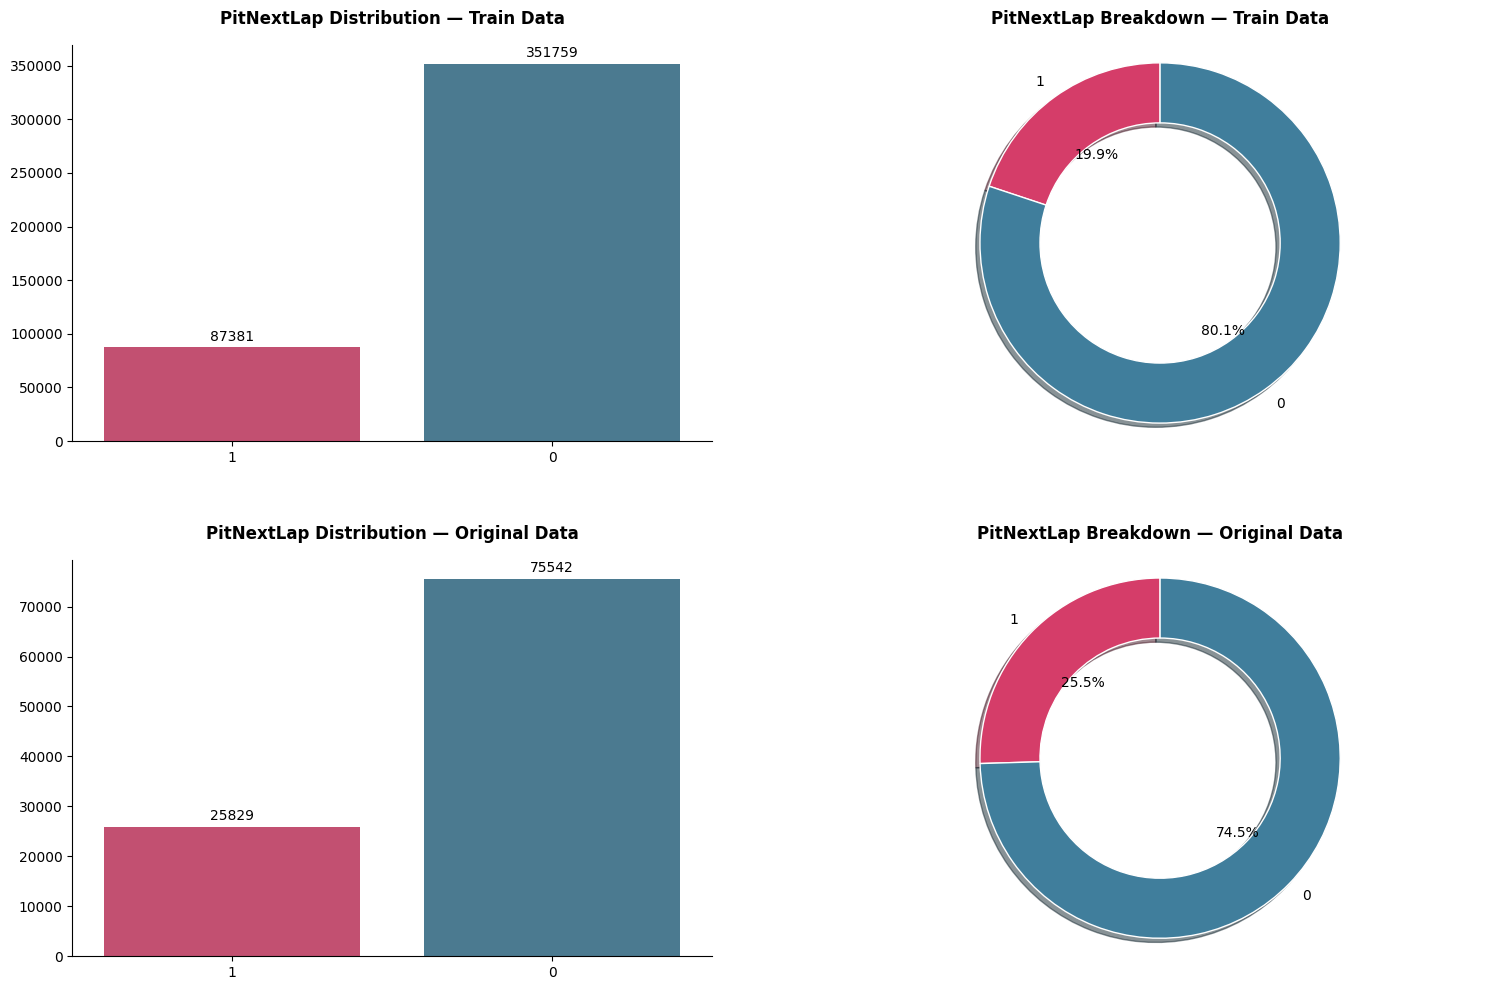

In [44]:
# Set target variable
df_train[CFG.TARGET_FEATURE] = df_train[CFG.TARGET_FEATURE].astype(int)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
datasets = [("Train Data", df_train), ("Original Data", df_original)]
n_color = df_train[CFG.TARGET_FEATURE].nunique()
order_pitnextlap = df_train[CFG.TARGET_FEATURE].unique().tolist()

for i, (title, data) in enumerate(datasets):
    ax = axes[i, 0]

    # Vertical barplot
    sns.countplot(x=CFG.TARGET_FEATURE, data=data, ax=ax,
                  palette=color(n_colors=n_color), order=order_pitnextlap)
    ax.set_title(f"PitNextLap Distribution — {title}", pad=15, weight="bold", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)

    # Add count labels on top of bars
    for p in ax.patches:
        height = p.get_height()
        x = p.get_x() + p.get_width() / 2
        ax.text(x, height + max(data[CFG.TARGET_FEATURE].value_counts()) * 0.01,
                f"{int(height)}",
                ha="center", va="bottom", fontsize=10, color="black")

    # Pie chart
    y_counts = data[CFG.TARGET_FEATURE].value_counts().reindex(order_pitnextlap)
    wedges, texts, autotexts = axes[i, 1].pie(
        y_counts, autopct="%1.1f%%", startangle=90, colors=color(n_colors=n_color), wedgeprops=dict(width=0.4, edgecolor="w"),
        radius=1.2,  shadow=True, labels=order_pitnextlap)
    for text in texts + autotexts:
        text.set_fontsize(10)

    centre_circle = plt.Circle((0, 0), 0.70, fc="white")
    axes[i, 1].add_artist(centre_circle)
    axes[i, 1].set_title(f"PitNextLap Breakdown — {title}", pad=15, weight="bold", fontsize=12)
    axes[i, 1].axis("equal")

plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.2)
plt.show()

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Target Distribution
</div>

<table style="
    width:100%;
    border-collapse: collapse;
    margin-bottom: 20px;
    font-size: 15px;
">
<thead>
<tr style="background-color: rgba(249,231,159,0.15);">
<th style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:left;">Dataset</th>
<th style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">No Pit (0)</th>
<th style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">Pit (1)</th>
<th style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">Pit Rate</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>Train</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">351,759</td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">87,381</td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;"><b>19.9%</b></td>
</tr>
<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>Original</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">75,542</td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">25,829</td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;"><b>25.5%</b></td>
</tr>
</tbody>
</table>

<ul style="line-height:1.8; padding-left:20px;">

<li><b>Majority class:</b> <code>No Pit (0)</code> dominates in both datasets (~75–80%).</li>

<li><b>Minority class:</b> <code>Pit (1)</code> accounts for ~20% in Train and ~25% in Original → moderately imbalanced binary classification.</li>

<li><b>Distribution difference:</b> Original dataset shows a higher pit rate (+~5%) → may indicate slight variation in race scenarios or sampling.</li>

<li><b>Consistency:</b> Despite the difference, both datasets maintain similar class patterns → no severe distribution shift.</li>

</ul>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">
<b>Key Insight:</b> The dataset shows a <b>moderate class imbalance</b>, where pit events are less frequent but still significant (~20–25%). Models may lean toward predicting <code>No Pit</code>, so techniques like <b>class weighting or threshold tuning</b> can help improve recall for pit stop prediction.
</div>

</div>

## Numerical Feature Distributions

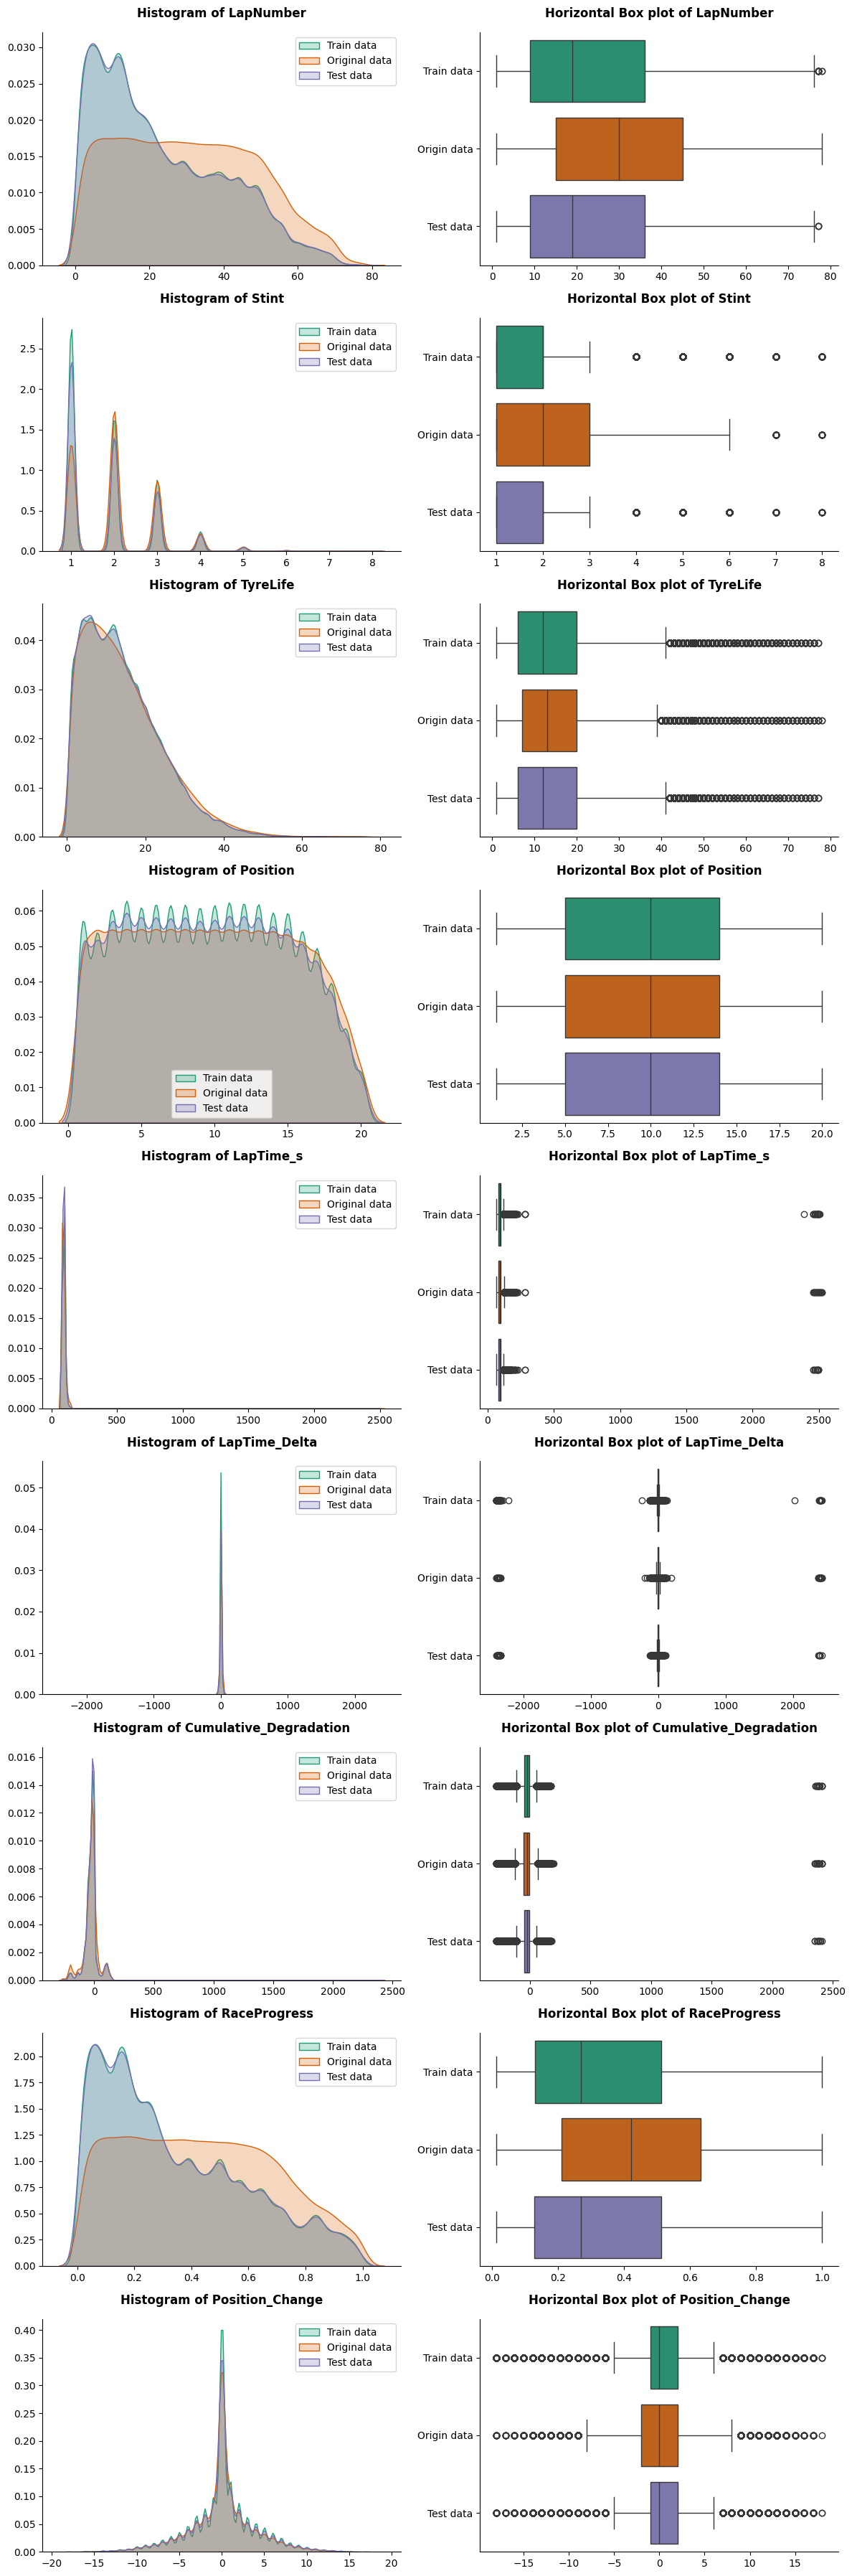

In [45]:
def plot_numerical_features(df_train: pd.DataFrame, df_test: pd.DataFrame, 
                            df_origin: pd.DataFrame, num_features: List[str]) -> None:
    """
    Plot histogram and boxplot for each numerical feature.

    - Histogram shows distribution and skewness.
    - Boxplot highlights median and potential outliers.
    """

    # Generate color palette for 3 datasets
    colors = color(n_colors=3, tone = "Dark2")
    n = len(num_features)

    # Create subplot grid: each feature has 1 row, 2 columns (hist + boxplot)
    fig, ax = plt.subplots(n, 2, figsize=(12, n * 4))
    ax = np.array(ax).reshape(n, 2)

    for i, feature in enumerate(num_features):
        # Histogram + KDE Plot
        sns.kdeplot(data=df_train[feature], color=colors[0], ax=ax[i, 0], label="Train data", fill=True)
        sns.kdeplot(data=df_origin[feature], color=colors[1], ax=ax[i, 0], label="Original data", fill=True)
        sns.kdeplot(data=df_test[feature], color=colors[2], ax=ax[i, 0], label="Test data", fill=True)

        # Format histogram
        ax[i, 0].set_title(f"Histogram of {feature}", pad=15, weight="bold", fontsize=12)
        ax[i, 0].legend()
        ax[i, 0].set_xlabel("")
        ax[i, 0].set_ylabel("")
        sns.despine(left=False, bottom=False, ax=ax[i, 0])

        df_plot = pd.concat([
            pd.DataFrame({"Dataset": "Train data", feature: df_train[feature]}),
            pd.DataFrame({"Dataset": "Origin data", feature: df_origin[feature]}),
            pd.DataFrame({"Dataset": "Test data", feature: df_test[feature]})
        ]).reset_index(drop=True)

        # Prepare Data for Boxplot
        sns.boxplot(data=df_plot, x=feature, y="Dataset", palette=colors, orient="h", ax=ax[i, 1])
        ax[i, 1].set_title(f"Horizontal Box plot of {feature}", pad=15, weight="bold", fontsize=12)
        ax[i, 1].set_xlabel("")
        ax[i, 1].set_ylabel("")
        sns.despine(left=False, bottom=False, ax=ax[i, 1])

    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()

plot_numerical_features(df_train = df_train, df_test = df_test, df_origin = df_original, num_features=num_features)

In [46]:
def check_skewness(data: pd.DataFrame, dataset_name: str, numerical_features: List[str] =num_features, 
                   sort=True, logger: logging.Logger=logger):
    """
    Analyze skewness of numerical features in a dataset and log summary insights.

    This function computes the skewness for each numerical feature, optionally
    sorts them by absolute skewness, and categorizes features based on the
    degree of skewness. Detailed results are logged at DEBUG level, while
    high-level insights and recommendations are logged at INFO level.

    Parameters
    ----------
    data : pandas.DataFrame
        The input dataset containing numerical features to be analyzed.

    dataset_name : str
        A descriptive name of the dataset, used for logging and reporting.

    numerical_features : list of str, optional
        List of numerical feature names to evaluate.
        Default is `num_features`.

    sort : bool, optional (default=True)
        If True, sort features by absolute skewness in descending order.

    logger : logging.Logger
        Logger object used to output analysis results and insights.

    Returns
    -------
    list of str
        A list of feature names that are considered highly skewed
        (|skewness| > 1).

    Notes
    -----
    - Skewness interpretation:
        * |skew| ≤ 0.5  : Approximately symmetric
        * 0.5 < |skew| ≤ 1 : Moderately skewed
        * |skew| > 1   : Highly skewed
    - Highly skewed features may benefit from transformations such as:
        log, Box-Cox, or Yeo-Johnson.
    - This function is intended for exploratory data analysis (EDA)
      and feature preprocessing stages.
    """

    skewness_dict = {}
    skew_features = []
    for feature in numerical_features:
        skew = data[feature].skew(skipna=True)
        skewness_dict[feature] = skew

    skew_df = pd.DataFrame.from_dict(skewness_dict, orient="index", columns=["Skewness"])
    if sort:
        skew_df = skew_df.reindex(skew_df["Skewness"].abs().sort_values(ascending=False).index)

    # ===== Summary header =====
    logger.info(f"Skewness analysis for {dataset_name}")
    logger.info(f"Total numerical features checked: {len(skew_df)}")

    # ===== Detailed table (DEBUG) =====
    logger.debug("-"*70)
    logger.debug(f"{'Feature':<30} | {'Skewness':<9} | {'Remark'}")
    logger.debug("-"*70)
    for feature, row in skew_df.iterrows():
        skew = row["Skewness"]
        abs_skew = abs(skew)
        if abs_skew > 1:
            remark = "Highly skewed"
            skew_features.append(feature)
        elif abs_skew > 0.5:
            remark = "Moderately skewed"
        else:
            remark = "Approximately symmetric"
        logger.debug(f"{feature:<30} | {skew:>+9.4f} | {remark}")
    logger.debug("-" * 70)

    # ===== Summary insight =====
    if skew_features:
        logger.info(f"{len(skew_features)} features are highly skewed (|skew| > 1).")
        logger.info(f"Recommendation: Consider log / Box-Cox / Yeo-Johnson transformation.")
    else:
        logger.info("No highly skewed features detected.")

    return skew_features

skew_feature = check_skewness(df_train, "Irrigation Need")
logger.info("-" * 80)
logger.info("Checking skewness successfully completed the dataset.")

2026-05-02 09:16:24 | INFO     | Skewness analysis for Irrigation Need
2026-05-02 09:16:24 | INFO     | Total numerical features checked: 9
2026-05-02 09:16:24 | DEBUG    | ----------------------------------------------------------------------
2026-05-02 09:16:24 | DEBUG    | Feature                        | Skewness  | Remark
2026-05-02 09:16:24 | DEBUG    | ----------------------------------------------------------------------
2026-05-02 09:16:24 | DEBUG    | LapTime_s                      |  +80.3343 | Highly skewed
2026-05-02 09:16:24 | DEBUG    | LapTime_Delta                  |  -40.8551 | Highly skewed
2026-05-02 09:16:24 | DEBUG    | Cumulative_Degradation         |   +3.1915 | Highly skewed
2026-05-02 09:16:24 | DEBUG    | Stint                          |   +1.1855 | Highly skewed
2026-05-02 09:16:24 | DEBUG    | TyreLife                       |   +1.0324 | Highly skewed
2026-05-02 09:16:24 | DEBUG    | RaceProgress                   |   +0.7000 | Moderately skewed
2026-05-02 

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Numerical Feature Insights
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li>Most numerical features exhibit <b>right-skewed distributions</b>, indicating a concentration of values in lower ranges with <b>long tails and extreme values</b>.</li>

<li><b>5 out of 9 features</b> are highly skewed (<code>|skew| &gt; 1</code>), confirming strong non-normality in the dataset.</li>

<li>Performance-related features such as <code>LapTime_s</code> (+80.33) and <code>LapTime_Delta</code> (-40.86) show <b>extreme skewness and heavy-tailed behavior</b>, driven by rare but significant race events.</li>

<li><code>Cumulative_Degradation</code>, <code>Stint</code>, and <code>TyreLife</code> are also <b>highly skewed</b>, reflecting uneven accumulation and usage patterns across laps.</li>

<li>Features like <code>TyreLife</code> and <code>Stint</code> appear <b>discrete and clustered</b>, indicating structured racing patterns rather than continuous variation.</li>

<li><code>Position</code> and <code>Position_Change</code> are <b>approximately symmetric</b>, while <code>RaceProgress</code> and <code>LapNumber</code> show only <b>moderate skewness</b>, suggesting more stable distributions.</li>

<li>Train and Test datasets display <b>highly consistent distributions</b> across all features → no significant distribution shift.</li>

<li>Boxplots confirm the presence of <b>numerous outliers</b>, especially in dynamic features, which are likely <b>event-driven (pit stops, incidents)</b> rather than random noise.</li>

</ul>

</div>

## Correlation Analysis of Numerical Features

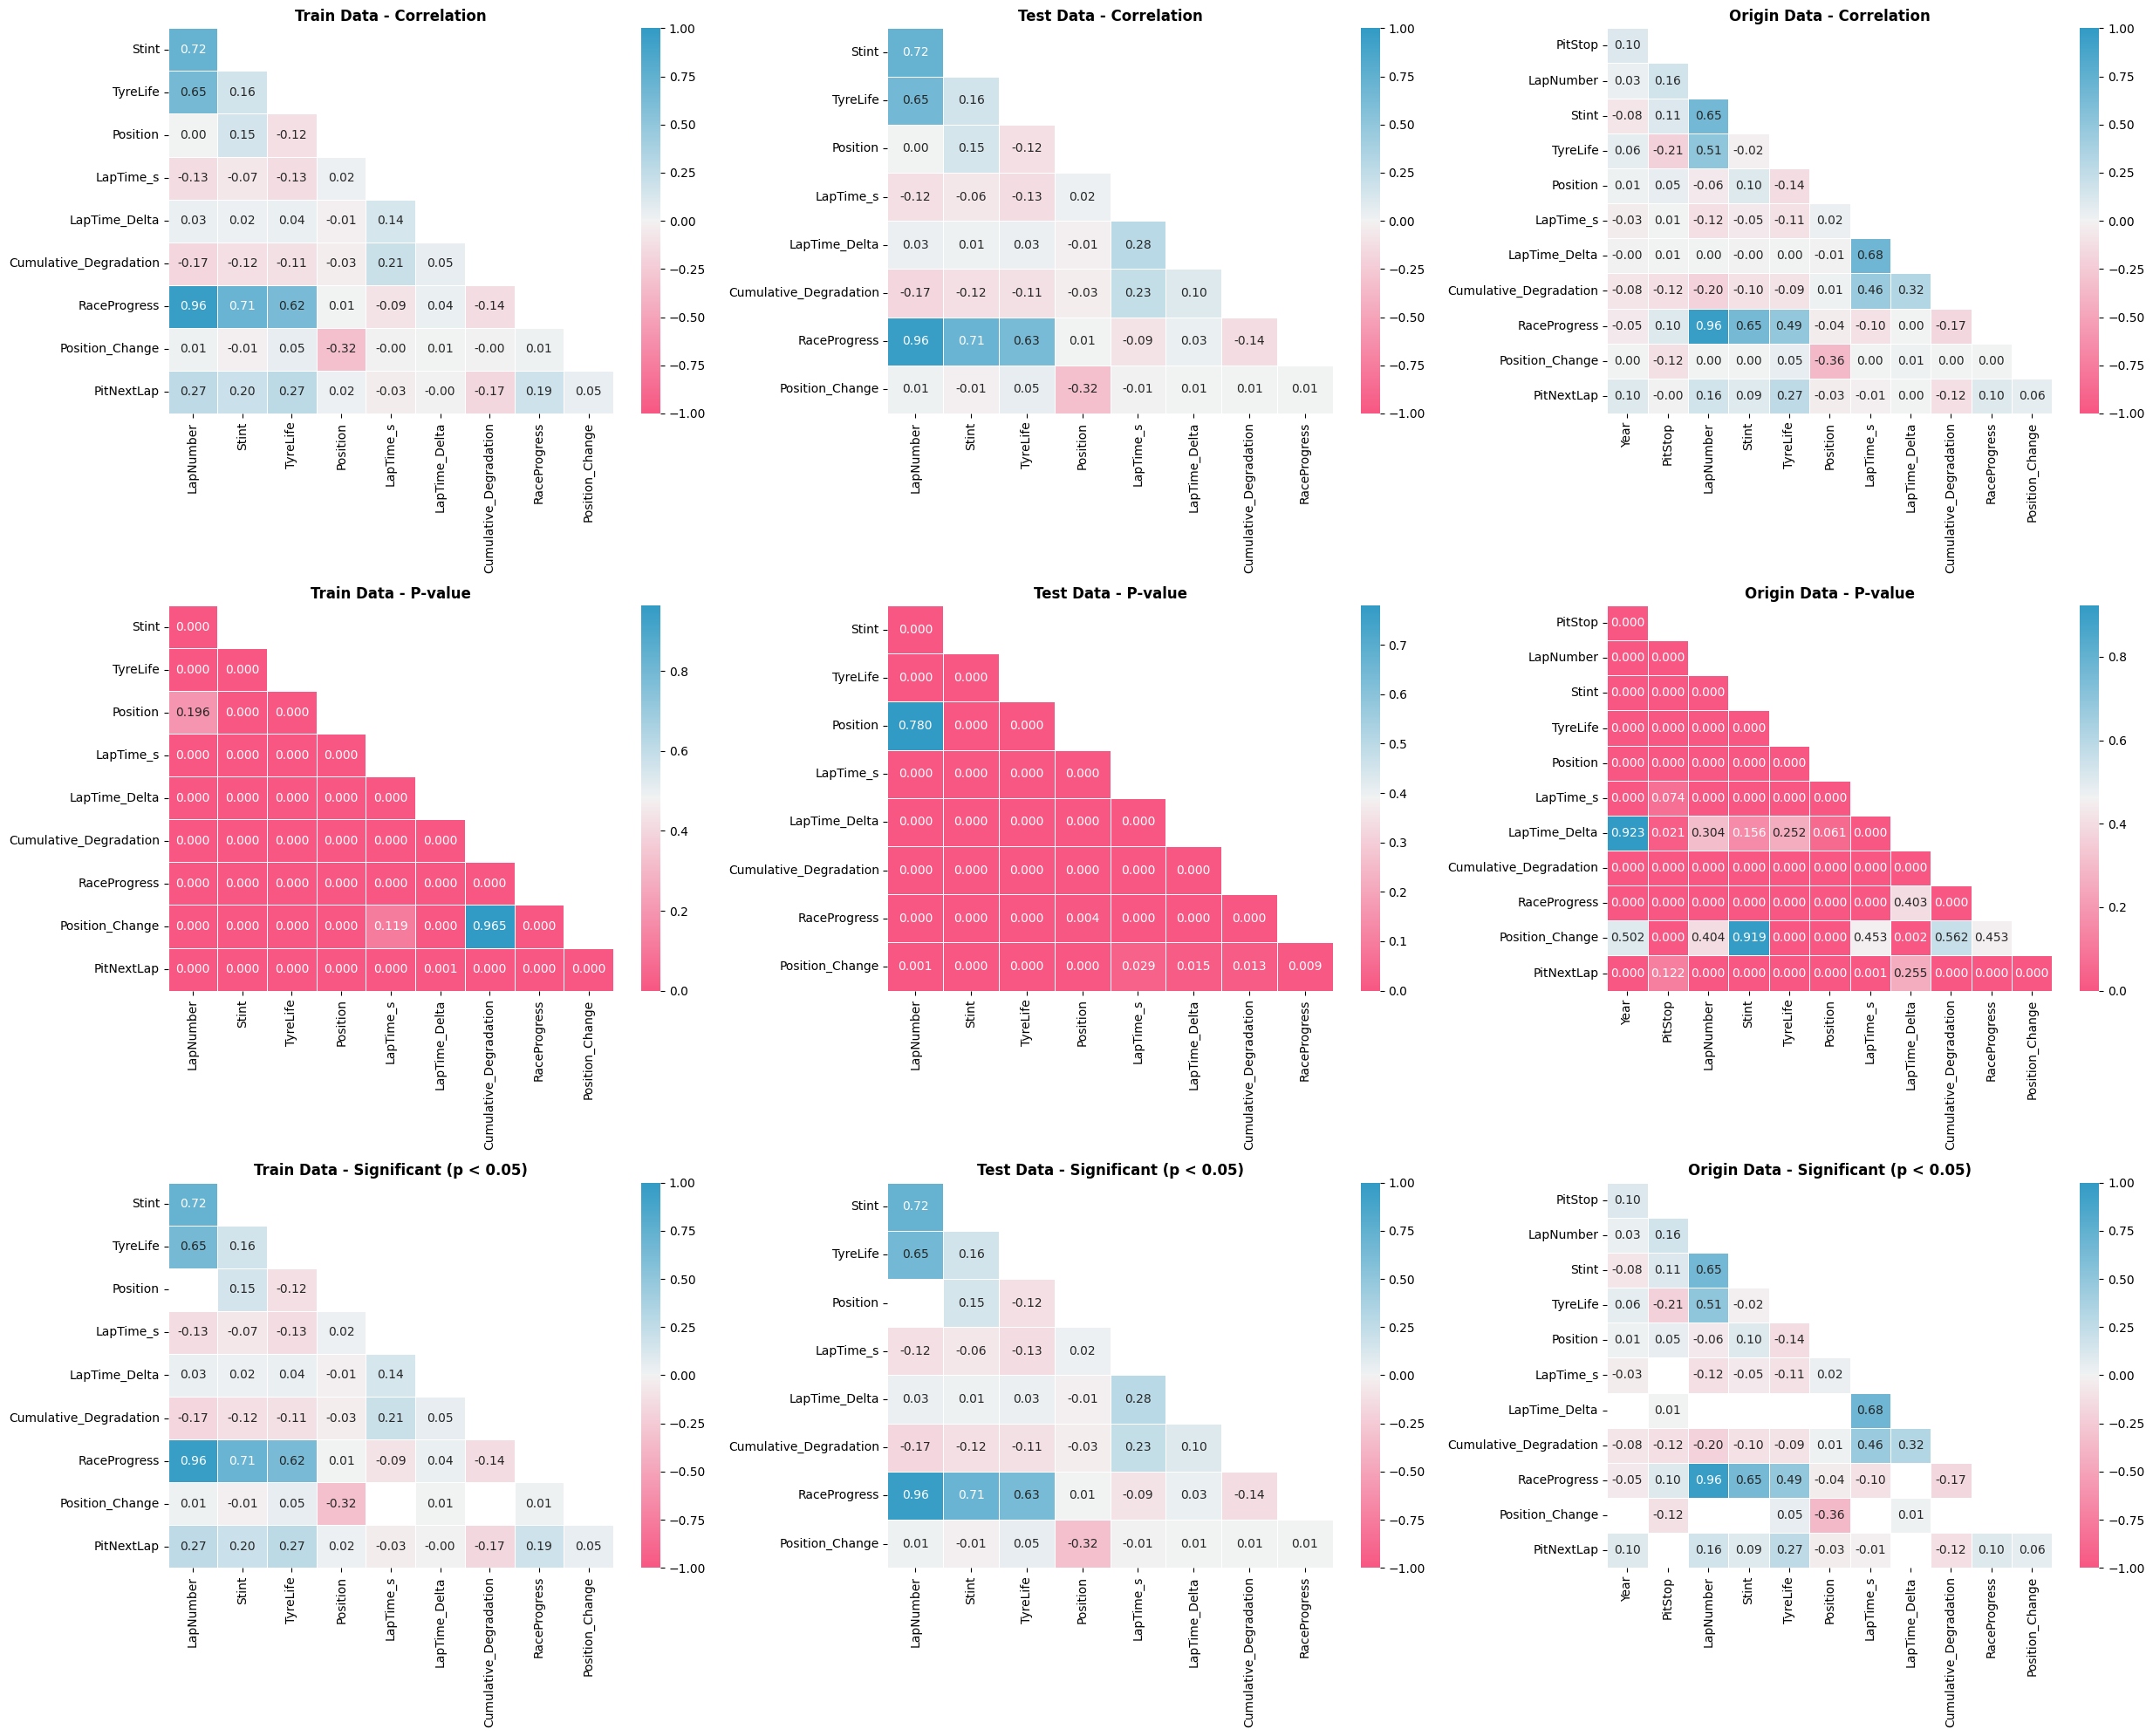

In [47]:
def _compute_corr_pval(df):
    """
    Compute correlation and p-value matrices for numeric features.

    This function calculates pairwise relationships between numeric columns:
    - Uses Pearson correlation for continuous-continuous pairs
    - Uses point-biserial correlation when one variable is binary (0/1)

    It also computes corresponding p-values to assess statistical significance.
    """

    # Select only numeric columns
    cols = df.select_dtypes(include=np.number).columns

    # Initialize empty matrices
    corr_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)
    pval_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)

    # Iterate over all feature pairs
    for i in cols:
        for j in cols:
            x = df[i]
            y = df[j]

            # Remove NaN values pairwise to ensure valid computation
            valid = x.notna() & y.notna()
            x = x[valid]
            y = y[valid]

            # Check if variables are binary (0/1)
            is_i_binary = set(x.unique()).issubset({0, 1})
            is_j_binary = set(y.unique()).issubset({0, 1})

            try:
                if i == j:
                    # Diagonal: perfect correlation
                    corr_matrix.loc[i, j] = 1.0
                    pval_matrix.loc[i, j] = 0.0

                elif is_i_binary and not is_j_binary:
                    # Binary vs continuous → point-biserial
                    r, p = pointbiserialr(x, y)

                elif is_j_binary and not is_i_binary:
                    # Continuous vs binary → point-biserial (swap order)
                    r, p = pointbiserialr(y, x)

                else:
                    # Continuous vs continuous → Pearson
                    r, p = pearsonr(x, y)

                # Store results
                corr_matrix.loc[i, j] = r
                pval_matrix.loc[i, j] = p

            except:
                # Handle edge cases (constant columns, etc.)
                corr_matrix.loc[i, j] = np.nan
                pval_matrix.loc[i, j] = np.nan

    return corr_matrix, pval_matrix


def _prepare_heatmap(matrix):
    """
    Prepare a matrix and mask for triangular heatmap visualization.

    This function:
    - Creates an upper triangular mask to avoid duplicate values
    - Removes redundant first row/last column for cleaner plotting
    """

    # Create upper triangle mask
    mask = np.triu(np.ones_like(matrix, dtype=bool))

    # Trim matrix to avoid redundant mirrored values
    return matrix.iloc[1:, :-1], mask[1:, :-1]


def plot_correlation_with_pvalue(df_train, df_origin, df_test,
                                origin_name="Origin Data",
                                train_name="Train Data",
                                test_name="Test Data"):
    """
    Visualize correlation and statistical significance across datasets.

    This function:
    - Computes correlation (r) and p-value matrices for each dataset
    - Plots three types of heatmaps for each dataset:
        1. Correlation heatmap (strength of relationship)
        2. P-value heatmap (statistical significance)
        3. Significant correlations only (p < 0.05)

    It supports mixed numeric and binary features using Pearson and
    point-biserial correlation appropriately.
    """

    # =========================
    # Compute correlation & p-value
    # =========================
    corr_train, p_train = _compute_corr_pval(df_train)
    corr_origin, p_origin = _compute_corr_pval(df_origin)
    corr_test, p_test = _compute_corr_pval(df_test)

    # =========================
    # Prepare matrices for plotting
    # =========================
    corr_train, mask_train = _prepare_heatmap(corr_train)
    p_train, _ = _prepare_heatmap(p_train)

    corr_origin, mask_origin = _prepare_heatmap(corr_origin)
    p_origin, _ = _prepare_heatmap(p_origin)

    corr_test, mask_test = _prepare_heatmap(corr_test)
    p_test, _ = _prepare_heatmap(p_test)

    # Color map for correlation
    cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

    # Create subplot grid (3 rows × 3 datasets)
    fig, ax = plt.subplots(3, 3, figsize=(25, 20))

    datasets = [
        (corr_train, p_train, mask_train, train_name),
        (corr_test, p_test, mask_test, test_name),
        (corr_origin, p_origin, mask_origin, origin_name),
    ]

    for col, (corr, pval, mask, title) in enumerate(datasets):

        # =========================
        # 1. Correlation heatmap
        # =========================
        sns.heatmap(
            corr,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap=cmap,
            vmin=-1, vmax=1,
            linewidths=0.5,
            linecolor="white",
            ax=ax[0, col]
        )
        ax[0, col].set_title(f"{title} - Correlation", weight="bold")

        # =========================
        # 2. P-value heatmap
        # =========================
        sns.heatmap(
            pval,
            mask=mask,
            annot=True,
            fmt=".3f",
            cmap=cmap,
            linewidths=0.5,
            linecolor="white",
            ax=ax[1, col]
        )
        ax[1, col].set_title(f"{title} - P-value", weight="bold")

        # =========================
        # 3. Significant correlations only
        # =========================
        sig = pval < 0.05  # significance threshold

        sns.heatmap(
            corr.where(sig),  # mask non-significant values
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap=cmap,
            vmin=-1, vmax=1,
            linewidths=0.5,
            linecolor="white",
            ax=ax[2, col]
        )
        ax[2, col].set_title(f"{title} - Significant (p < 0.05)", weight="bold")

    plt.tight_layout()
    plt.show()

plot_correlation_with_pvalue(df_train=df_train, df_origin=df_original, df_test=df_test)

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
">
📊 Correlation & Statistical Significance Analysis
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li>Pairwise relationships were evaluated using <b>Pearson correlation</b> (including point-biserial for binary features) along with <b>p-values</b> to assess statistical significance.</li>

<li>Most feature pairs exhibit <b>low to moderate linear correlation</b> (|r| &lt; 0.3), suggesting limited linear dependency and generally low multicollinearity.</li>

<li>Importantly, many low-correlation pairs remain <b>statistically significant (p &lt; 0.05)</b>, indicating the presence of subtle or potentially non-linear relationships.</li>

</ul>

<h3>Key Relationships & Structural Patterns</h3>

<ul style="line-height: 1.8; padding-left: 20px;">

<li><code>RaceProgress</code> shows an <b>extremely strong correlation</b> with <code>LapNumber</code> (~0.96), and strong correlations with <code>Stint</code> and <code>TyreLife</code> (~0.6–0.7).  
→ These variables capture the same underlying race progression signal, indicating <b>high redundancy</b>.</li>

<li><code>Stint</code> and <code>TyreLife</code> are strongly correlated (~0.65–0.72), reflecting shared information about tyre lifecycle.</li>

<li><code>LapTime_Delta</code> has a <b>moderate positive relationship</b> with <code>Cumulative_Degradation</code>, suggesting degradation contributes to performance variability over time.</li>

<li><code>Position_Change</code> shows a <b>negative relationship</b> with <code>Position</code> (~ -0.3), which is consistent with race dynamics (improvement vs ranking).</li>

<li>Several features exhibit <b>low correlation but significant p-values</b>, indicating weak but reliable signals that may become important in non-linear models.</li>

</ul>

<h3>Dataset Consistency & Stability</h3>

<ul style="line-height: 1.8; padding-left: 20px;">

<li>The correlation structures between <b>Train and Test datasets are highly consistent</b>, indicating no major distribution shift.</li>

<li>The <b>Original dataset</b> follows similar patterns with minor variations in correlation strength, suggesting stable feature relationships across data sources.</li>

<li>No evidence of significant <b>correlation drift</b> is observed, supporting model generalization.</li>

</ul>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
">

<b>Modeling Implications:</b>

<ul style="margin-top:8px; padding-left:18px; line-height:1.7;">

<li>The strong relationships among <code>LapNumber</code>, <code>RaceProgress</code>, and <code>Stint</code> indicate <b>high redundancy</b>.  
→ Consider dropping or regularizing these features in linear models.</li>

<li>Weak but statistically significant features may encode <b>non-linear effects</b>, making them valuable for tree-based models.</li>

<li>The stable correlation structure across datasets suggests <b>low risk of data leakage or distribution mismatch</b>.</li>

<li>Tree-based models (e.g., Random Forest, XGBoost) can naturally exploit these relationships, while linear models may require <b>feature selection or interaction engineering</b>.</li>

</ul>

</div>

</div>

## Categorical Feature Distributions

In [48]:
def plot_categorical_distribution_across_datasets(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    df_original: pd.DataFrame,
    feature: str = "gender",
    logger: logging.Logger = logger
) -> None:

    logger.info(f"Analyzing categorical feature: {feature}")

    # TRAIN
    train_summary = (
        df_train[feature]
        .value_counts()
        .rename_axis("Category")
        .reset_index(name="Train_Count")
    )
    train_summary["Train_%"] = round(
        train_summary["Train_Count"] / train_summary["Train_Count"].sum() * 100, 2
    )

    # TEST
    test_summary = (
        df_test[feature]
        .value_counts()
        .rename_axis("Category")
        .reset_index(name="Test_Count")
    )
    test_summary["Test_%"] = round(
        test_summary["Test_Count"] / test_summary["Test_Count"].sum() * 100, 2
    )

    # ORIGINAL
    original_summary = (
        df_original[feature]
        .value_counts()
        .rename_axis("Category")
        .reset_index(name="Original_Count")
    )
    original_summary["Original_%"] = round(
        original_summary["Original_Count"] / original_summary["Original_Count"].sum() * 100, 2
    )

    # Merge ALL
    summary = train_summary.merge(test_summary, on="Category", how="outer")
    summary = summary.merge(original_summary, on="Category", how="outer")

    logger.debug(f"{feature}: {len(summary)} categories detected")
    summary["Category"] = summary["Category"].astype(str)

    num_cols = [
        "Train_Count", "Train_%",
        "Test_Count", "Test_%",
        "Original_Count", "Original_%"
    ]

    summary[num_cols] = summary[num_cols].fillna(0)
    summary = summary.sort_values(by="Train_Count", ascending=False)

    logger.info(
        f"Categorical Feature Distribution: {feature}:\n"
        f"{summary.to_string()}"
    )

    logger.info(f"Completed analysis for: {feature}")
    logger.info("*" * 80)
    logger.info("\n")

# Apply function to all categorical features
df_original = df_original.dropna(subset=["Compound"])
# Categorical features
cat_features2 = ["Compound", "Year", "PitStop"]
for feature in cat_features2:
    plot_categorical_distribution_across_datasets(df_train, df_test, df_original, feature)

2026-05-02 09:16:35 | INFO     | Analyzing categorical feature: Compound
2026-05-02 09:16:35 | DEBUG    | Compound: 5 categories detected
2026-05-02 09:16:35 | INFO     | Categorical Feature Distribution: Compound:
       Category  Train_Count  Train_%  Test_Count  Test_%  Original_Count  Original_%
2        MEDIUM       211141    48.08       90897   48.31           37639       37.15
0          HARD       170518    38.83       72677   38.62           44967       44.39
3          SOFT        38744     8.82       16615    8.83           12744       12.58
1  INTERMEDIATE        17382     3.96        7408    3.94            5556        5.48
4           WET         1355     0.31         568    0.30             399        0.39
2026-05-02 09:16:35 | INFO     | Completed analysis for: Compound
2026-05-02 09:16:35 | INFO     | ********************************************************************************
2026-05-02 09:16:35 | INFO     | 

2026-05-02 09:16:35 | INFO     | Analyzing categorical

In [49]:
def top_ratio(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    df_original: pd.DataFrame,
    cat_features: List[str],
    logger: logging.Logger
) -> None:
    """
    Identify categorical features dominated by a single category (>99%)
    across Train, Test, and Original datasets.

    A feature is considered low-variance if one category accounts for
    more than 99% of its values.
    """

    # Define dataset names and corresponding DataFrames
    dataset_names = ["Train", "Test", "Original"]
    datasets = [df_train, df_test, df_original]

    # Iterate through each dataset
    for data, name in zip(datasets, dataset_names):

        # Log dataset name
        logger.info(f"{name} Data")

        # Flag to check if any feature is dominated
        flagged = False

        # Iterate through each categorical feature
        for feature in cat_features:

            # Compute normalized frequency (percentage) of each category
            # Drop NA to avoid misleading ratios
            freq = data[feature].dropna().value_counts(normalize=True)

            # Skip if feature is empty after dropping NA
            if freq.empty:
                continue

            # Get top category ratio and category name
            top_ratio_value = freq.iloc[0]
            top_category = freq.index[0]

            # Check if one category dominates (>99%)
            if top_ratio_value > 0.99:
                flagged = True

                # Log feature name, dominant ratio, and category
                logger.info(
                    f"{feature}: {top_ratio_value:.1%} is '{top_category}'"
                )

        # If no feature meets the condition
        if not flagged:
            logger.info("No feature has a category that makes up more than 99% of its values.")

        # Separator for readability
        logger.info("-" * 80)

top_ratio(df_train=df_train, df_test=df_test, df_original=df_original, cat_features=cat_features, logger=logger)

2026-05-02 09:16:35 | INFO     | Train Data
2026-05-02 09:16:35 | INFO     | No feature has a category that makes up more than 99% of its values.
2026-05-02 09:16:35 | INFO     | --------------------------------------------------------------------------------
2026-05-02 09:16:35 | INFO     | Test Data
2026-05-02 09:16:35 | INFO     | No feature has a category that makes up more than 99% of its values.
2026-05-02 09:16:35 | INFO     | --------------------------------------------------------------------------------
2026-05-02 09:16:35 | INFO     | Original Data
2026-05-02 09:16:35 | INFO     | No feature has a category that makes up more than 99% of its values.
2026-05-02 09:16:35 | INFO     | --------------------------------------------------------------------------------


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Categorical Feature Consistency
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li>All categorical features across <b>Train</b>, <b>Test</b>, and <b>Original</b> datasets show <b>no dominant category exceeding 99%</b>.</li>

<li>This indicates the absence of <b>low-variance or near-constant features</b>, ensuring that all categorical variables retain meaningful variability.</li>

<li>Category distributions remain <b>consistent across datasets</b>, suggesting stable data generation and no noticeable distribution drift.</li>

<li>Such consistency supports <b>robust model training</b> and improves the likelihood of <b>good generalization performance</b>.</li>

</ul>

</div>

## Bivariate Analysis

,PitNextLap,Count,Mean,Median,Std
0,1,113172,32.915465,33.000000,15.866541
1,0,427273,22.244474,18.000000,17.129738


2026-05-02 09:16:36 | INFO     | Checking normality of feature 'LapNumber' by groups of 'PitNextLap'...
2026-05-02 09:16:36 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-05-02 09:16:36 | DEBUG    | Number of groups detected: 2
2026-05-02 09:16:36 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-05-02 09:16:36 | DEBUG    | [PitNextLap=0] skew=0.8732, kurtosis=-0.1416 → Moderately skewed, Normal tails
2026-05-02 09:16:36 | DEBUG    | [PitNextLap=1] skew=0.0153, kurtosis=-0.7485 → Approximately symmetric, Normal tails
2026-05-02 09:16:36 | INFO     | Generating Q–Q plots for visual assessment...


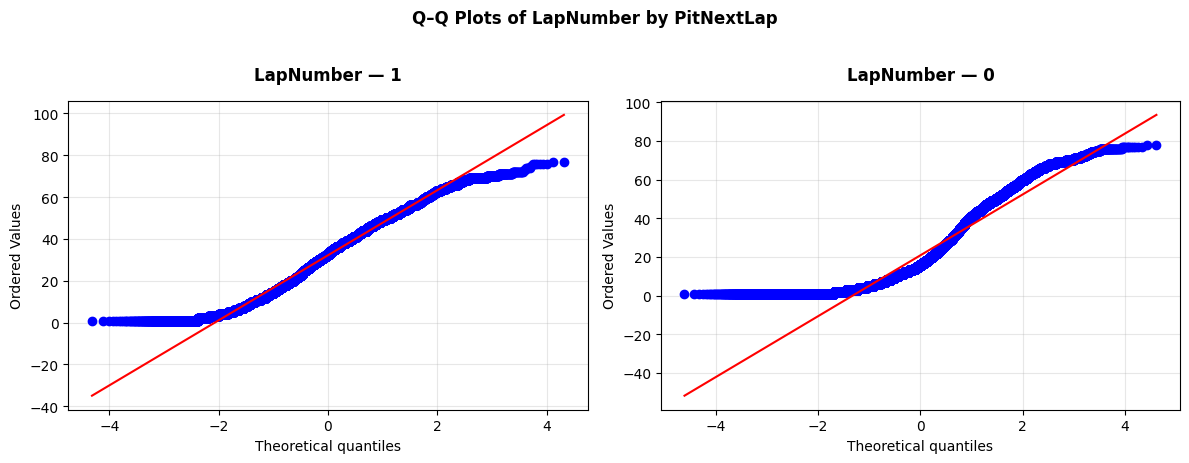

,Feature,Group,Skewness,Kurtosis,Remark
0,LapNumber,0,0.8732,-0.1416,"Moderately skewed, Normal tails"
1,LapNumber,1,0.0153,-0.7485,"Approximately symmetric, Normal tails"


2026-05-02 09:16:37 | WARNING  | Normality assumption violated in at least one group.
2026-05-02 09:16:37 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-05-02 09:16:37 | INFO     | Running Mann–Whitney U Test: 'LapNumber' by 'PitNextLap'...
2026-05-02 09:16:37 | DEBUG    | Number of groups detected: 2
2026-05-02 09:16:37 | INFO     | U statistic: 21588703909.0
2026-05-02 09:16:37 | INFO     | p-value    : 0.000000
2026-05-02 09:16:38 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-05-02 09:16:38 | INFO     | Conclusion: Significant difference between the two groups.
2026-05-02 09:16:38 | INFO     | Effect size (r): 0.2799
2026-05-02 09:16:38 | INFO     | Effect size interpretation: Small
2026-05-02 09:16:38 | INFO     | Cliff's Delta: -0.4047
2026-05-02 09:16:38 | INFO     | Effect size (Cliff's Delta) interpretation: Medium


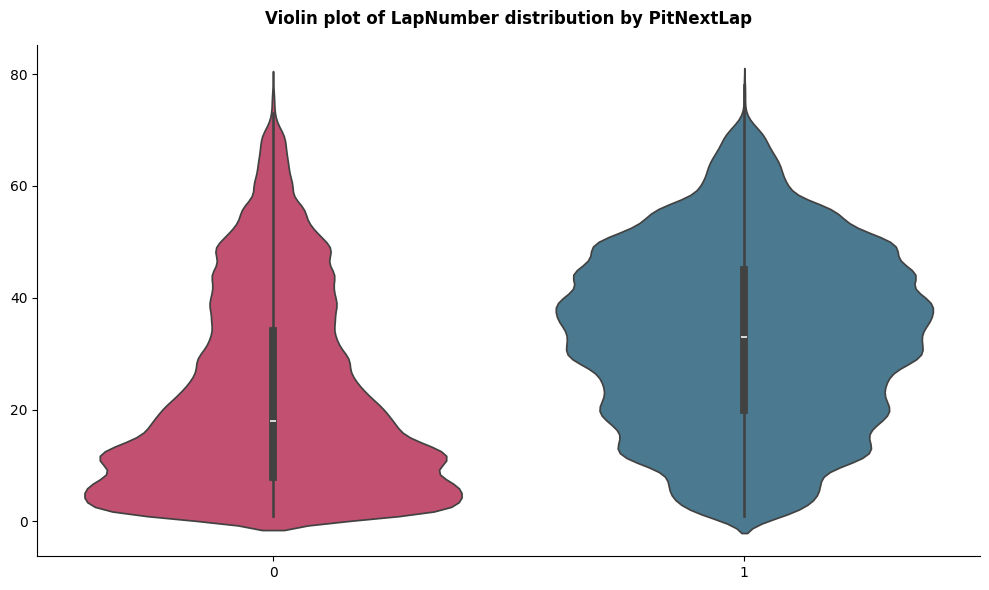

,PitNextLap,Count,Mean,Median,Std
0,1,113172,2.171253,2.000000,0.724417
1,0,427273,1.748585,1.000000,0.988410


2026-05-02 09:16:40 | INFO     | Checking normality of feature 'Stint' by groups of 'PitNextLap'...
2026-05-02 09:16:40 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-05-02 09:16:40 | DEBUG    | Number of groups detected: 2
2026-05-02 09:16:40 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-05-02 09:16:40 | DEBUG    | [PitNextLap=0] skew=1.4301, kurtosis=1.8000 → Highly skewed, Heavy/light tails
2026-05-02 09:16:40 | DEBUG    | [PitNextLap=1] skew=0.5101, kurtosis=0.6727 → Moderately skewed, Normal tails
2026-05-02 09:16:40 | INFO     | Generating Q–Q plots for visual assessment...


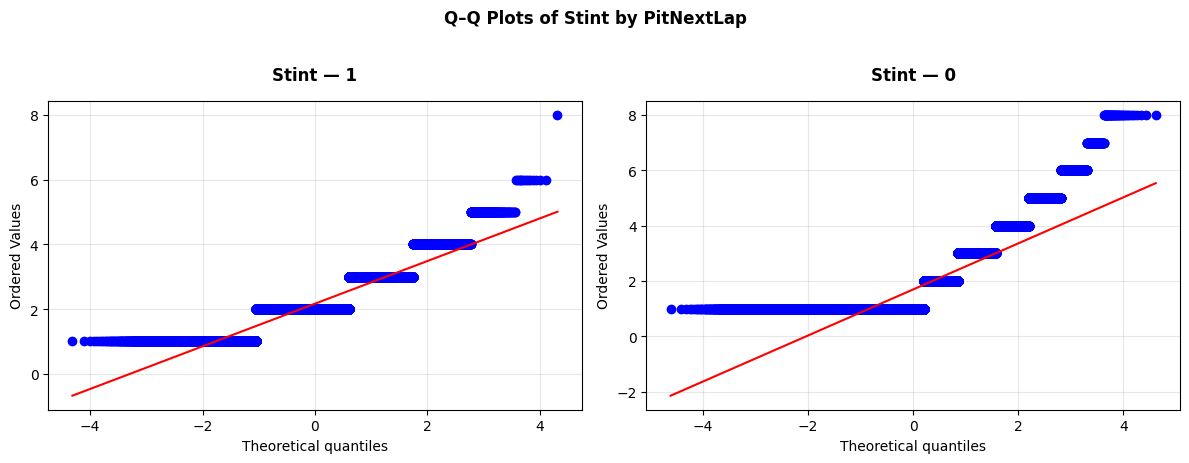

,Feature,Group,Skewness,Kurtosis,Remark
0,Stint,0,1.4301,1.8000,"Highly skewed, Heavy/light tails"
1,Stint,1,0.5101,0.6727,"Moderately skewed, Normal tails"


2026-05-02 09:16:41 | WARNING  | Normality assumption violated in at least one group.
2026-05-02 09:16:41 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-05-02 09:16:41 | INFO     | Running Mann–Whitney U Test: 'Stint' by 'PitNextLap'...
2026-05-02 09:16:41 | DEBUG    | Number of groups detected: 2
2026-05-02 09:16:41 | INFO     | U statistic: 21024138716.5
2026-05-02 09:16:41 | INFO     | p-value    : 0.000000
2026-05-02 09:16:41 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-05-02 09:16:41 | INFO     | Conclusion: Significant difference between the two groups.
2026-05-02 09:16:41 | INFO     | Effect size (r): 0.2545
2026-05-02 09:16:41 | INFO     | Effect size interpretation: Small
2026-05-02 09:16:41 | INFO     | Cliff's Delta: -0.3680
2026-05-02 09:16:41 | INFO     | Effect size (Cliff's Delta) interpretation: Medium


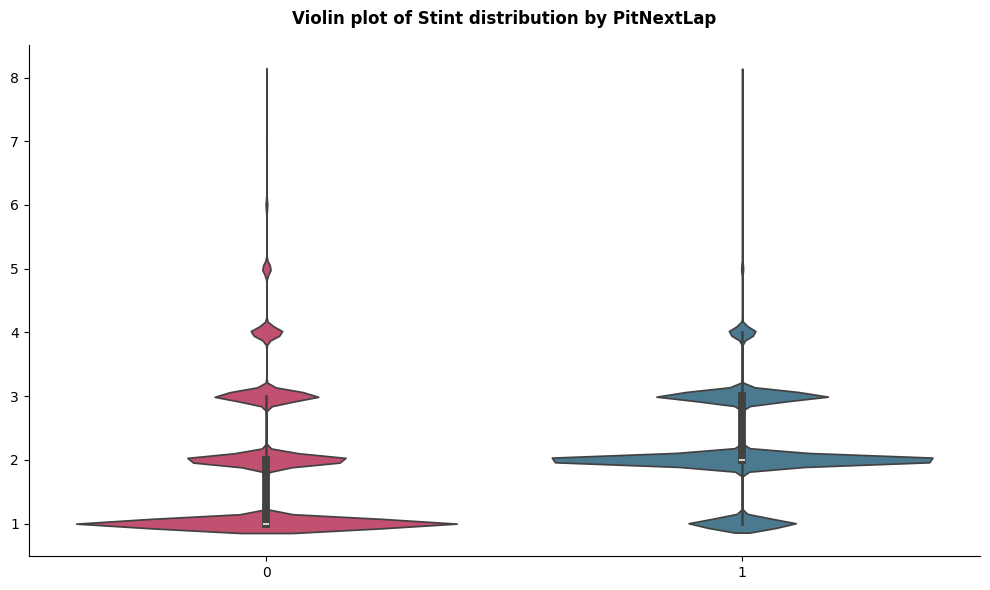

,PitNextLap,Count,Mean,Median,Std
0,1,113172,19.469140,18.000000,10.475223
1,0,427273,12.843161,11.000000,9.258384


2026-05-02 09:16:43 | INFO     | Checking normality of feature 'TyreLife' by groups of 'PitNextLap'...
2026-05-02 09:16:43 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-05-02 09:16:43 | DEBUG    | Number of groups detected: 2
2026-05-02 09:16:43 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-05-02 09:16:43 | DEBUG    | [PitNextLap=0] skew=1.0563, kurtosis=1.3340 → Highly skewed, Normal tails
2026-05-02 09:16:43 | DEBUG    | [PitNextLap=1] skew=0.9635, kurtosis=1.6014 → Moderately skewed, Heavy/light tails
2026-05-02 09:16:43 | INFO     | Generating Q–Q plots for visual assessment...


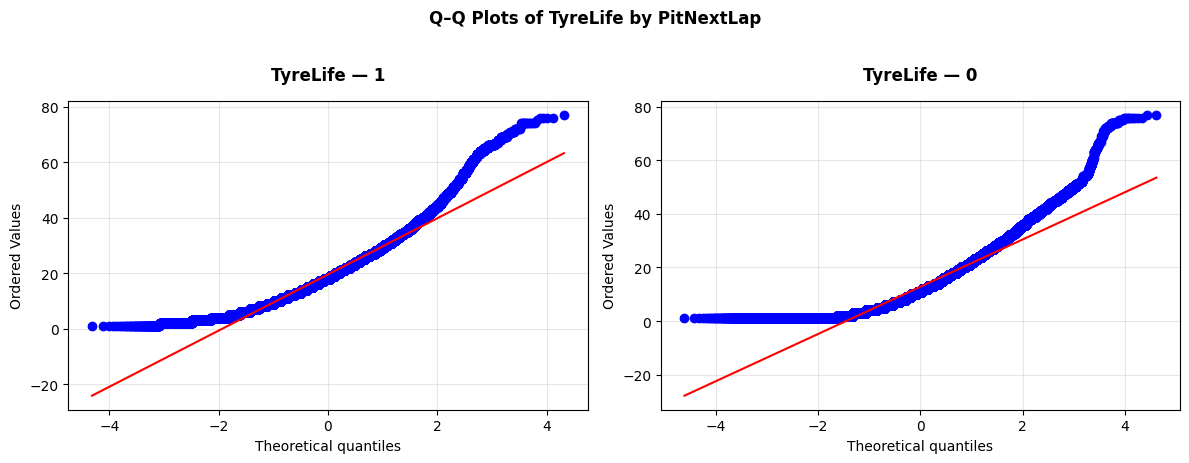

,Feature,Group,Skewness,Kurtosis,Remark
0,TyreLife,0,1.0563,1.3340,"Highly skewed, Normal tails"
1,TyreLife,1,0.9635,1.6014,"Moderately skewed, Heavy/light tails"


2026-05-02 09:16:45 | WARNING  | Normality assumption violated in at least one group.
2026-05-02 09:16:45 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-05-02 09:16:45 | INFO     | Running Mann–Whitney U Test: 'TyreLife' by 'PitNextLap'...
2026-05-02 09:16:45 | DEBUG    | Number of groups detected: 2
2026-05-02 09:16:45 | INFO     | U statistic: 21483601465.0
2026-05-02 09:16:45 | INFO     | p-value    : 0.000000
2026-05-02 09:16:45 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-05-02 09:16:45 | INFO     | Conclusion: Significant difference between the two groups.
2026-05-02 09:16:45 | INFO     | Effect size (r): 0.2751
2026-05-02 09:16:45 | INFO     | Effect size interpretation: Small
2026-05-02 09:16:45 | INFO     | Cliff's Delta: -0.3979
2026-05-02 09:16:45 | INFO     | Effect size (Cliff's Delta) interpretation: Medium


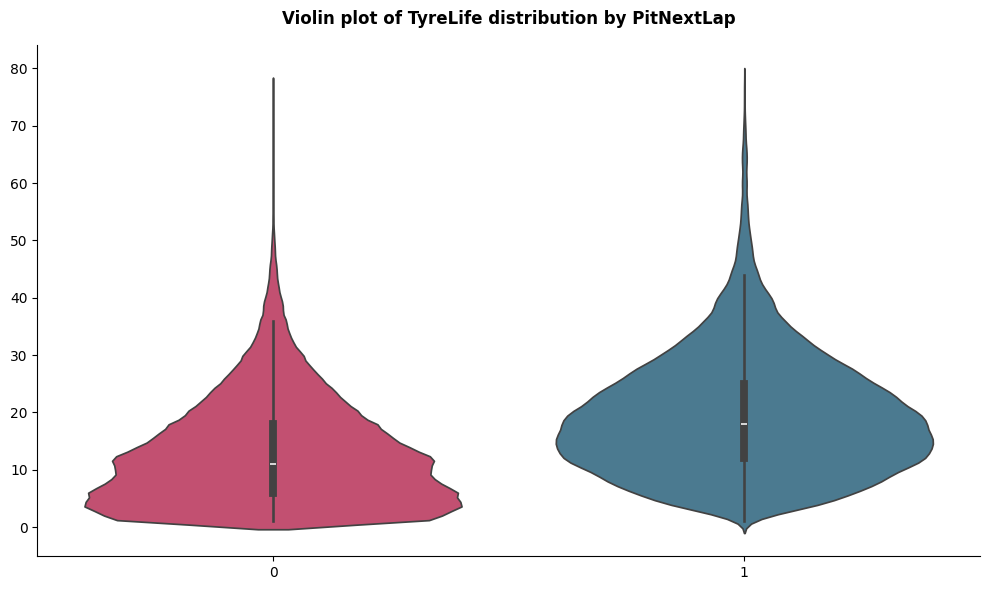

,PitNextLap,Count,Mean,Median,Std
0,1,113172,9.767151,10.000000,5.185717
1,0,427273,9.624556,10.000000,5.333610


2026-05-02 09:16:47 | INFO     | Checking normality of feature 'Position' by groups of 'PitNextLap'...
2026-05-02 09:16:47 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-05-02 09:16:47 | DEBUG    | Number of groups detected: 2
2026-05-02 09:16:47 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-05-02 09:16:47 | DEBUG    | [PitNextLap=0] skew=0.0909, kurtosis=-1.1008 → Approximately symmetric, Normal tails
2026-05-02 09:16:47 | DEBUG    | [PitNextLap=1] skew=-0.0134, kurtosis=-1.0848 → Approximately symmetric, Normal tails
2026-05-02 09:16:47 | INFO     | Generating Q–Q plots for visual assessment...


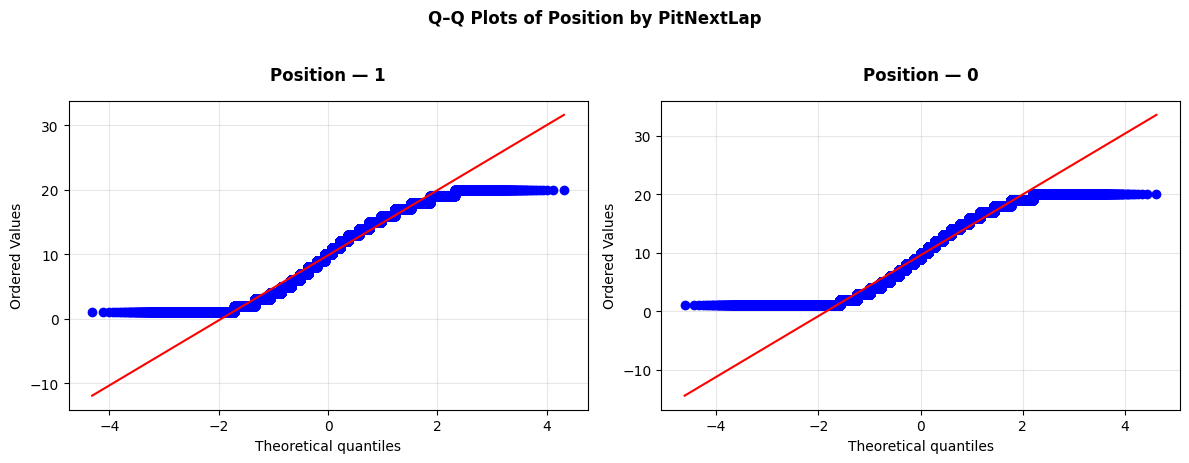

,Feature,Group,Skewness,Kurtosis,Remark
0,Position,0,0.0909,-1.1008,"Approximately symmetric, Normal tails"
1,Position,1,-0.0134,-1.0848,"Approximately symmetric, Normal tails"


2026-05-02 09:16:48 | INFO     | All groups approximately follow a normal distribution.
2026-05-02 09:16:48 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-05-02 09:16:48 | DEBUG    | Number of groups detected: 2


,Metric,Value
0,Levene’s Statistic,233.3371
1,p-value,0.000000
2,Max/Min Variance Ratio,1.07


2026-05-02 09:16:48 | INFO     | Interpretation:
2026-05-02 09:16:48 | INFO     | - Status: Statistically different variances, but practical difference is small.
2026-05-02 09:16:48 | INFO     | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-05-02 09:16:48 | INFO     | Running Independent Two-Sample T-Test: 'Position' ~ 'PitNextLap'
2026-05-02 09:16:48 | DEBUG    | Number of groups detected: 2
2026-05-02 09:16:48 | DEBUG    | Test Type: Welch’s T-Test (unequal variances)
2026-05-02 09:16:48 | INFO     | Comparing groups: '1' vs '0'
2026-05-02 09:16:48 | INFO     | p-value: 0.000000
2026-05-02 09:16:48 | INFO     | Cohen's d: 0.054
2026-05-02 09:16:48 | DEBUG    | t-statistic: 14.429
2026-05-02 09:16:48 | DEBUG    | Group means → 1: 9.856, 0: 9.574
2026-05-02 09:16:48 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-05-02 09:16:48 | INFO     | Conclusion: Significant difference between the two groups.
2026-05-02 09:16:48 | 

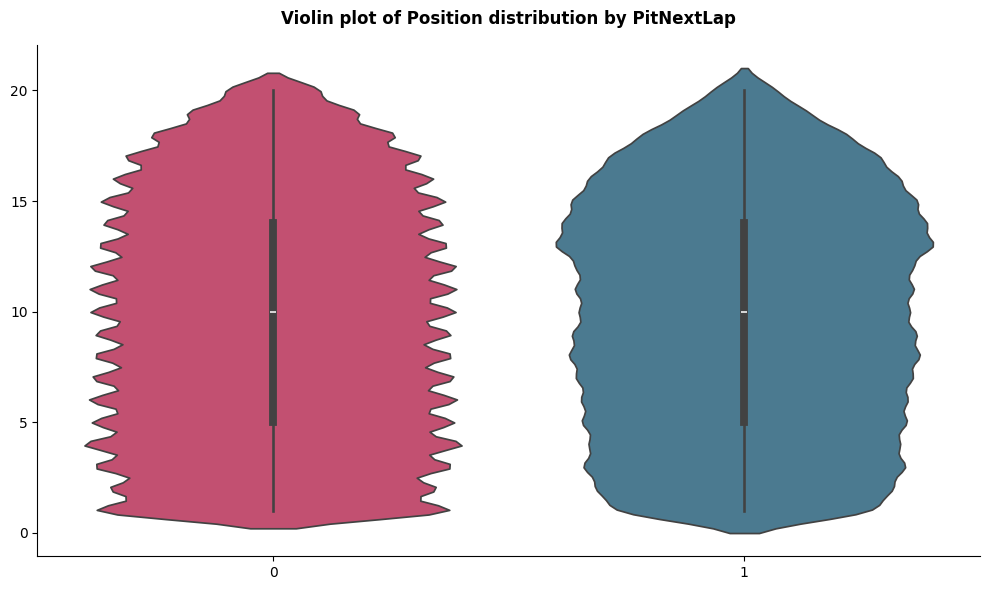

,PitNextLap,Count,Mean,Median,Std
0,0,427273,91.550337,90.945999,24.009881
1,1,113172,90.153374,88.723000,18.166817


2026-05-02 09:16:50 | INFO     | Checking normality of feature 'LapTime_s' by groups of 'PitNextLap'...
2026-05-02 09:16:50 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-05-02 09:16:50 | DEBUG    | Number of groups detected: 2
2026-05-02 09:16:50 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-05-02 09:16:50 | DEBUG    | [PitNextLap=0] skew=78.7924, kurtosis=8762.6356 → Highly skewed, Heavy/light tails
2026-05-02 09:16:50 | DEBUG    | [PitNextLap=1] skew=0.5955, kurtosis=0.6650 → Moderately skewed, Normal tails
2026-05-02 09:16:50 | INFO     | Generating Q–Q plots for visual assessment...


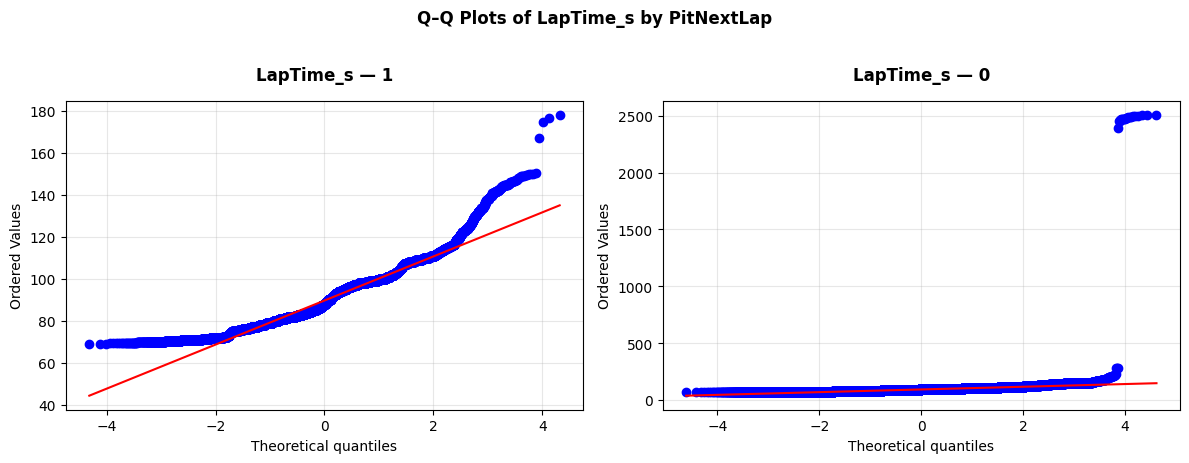

,Feature,Group,Skewness,Kurtosis,Remark
0,LapTime_s,0,78.7924,8762.6356,"Highly skewed, Heavy/light tails"
1,LapTime_s,1,0.5955,0.6650,"Moderately skewed, Normal tails"


2026-05-02 09:16:52 | WARNING  | Normality assumption violated in at least one group.
2026-05-02 09:16:52 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-05-02 09:16:52 | INFO     | Running Mann–Whitney U Test: 'LapTime_s' by 'PitNextLap'...
2026-05-02 09:16:52 | DEBUG    | Number of groups detected: 2
2026-05-02 09:16:52 | INFO     | U statistic: 14151401017.0
2026-05-02 09:16:52 | INFO     | p-value    : 0.000000
2026-05-02 09:16:52 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-05-02 09:16:52 | INFO     | Conclusion: Significant difference between the two groups.
2026-05-02 09:16:52 | INFO     | Effect size (r): 0.0548
2026-05-02 09:16:52 | INFO     | Effect size interpretation: Negligible
2026-05-02 09:16:52 | INFO     | Cliff's Delta: 0.0792
2026-05-02 09:16:52 | INFO     | Effect size (Cliff's Delta) interpretation: Negligible


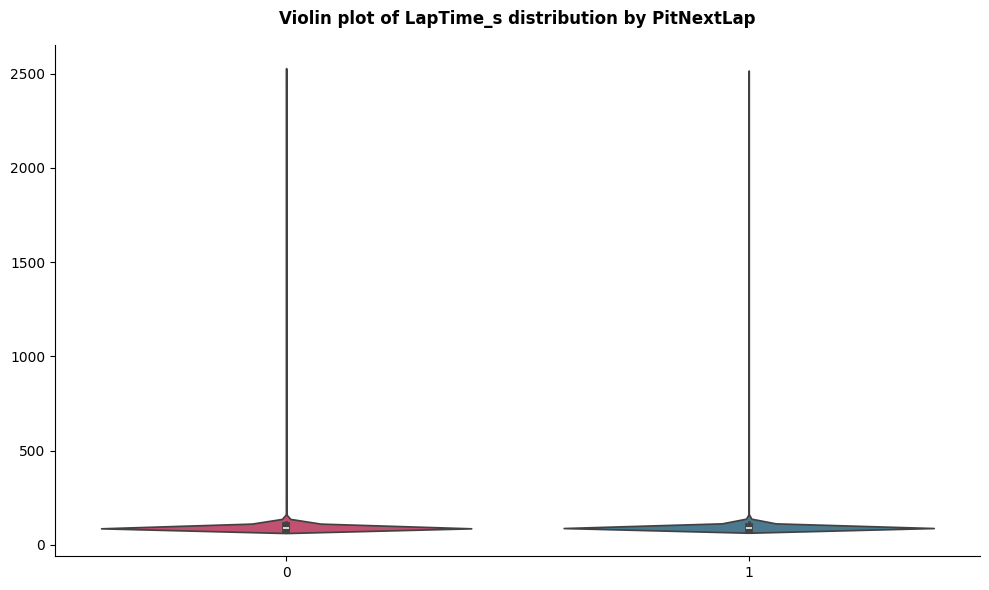

,PitNextLap,Count,Mean,Median,Std
0,0,427273,-3.067288,-0.129000,47.942930
1,1,113172,-3.224977,-3.564000,25.818361


2026-05-02 09:16:54 | INFO     | Checking normality of feature 'LapTime_Delta' by groups of 'PitNextLap'...
2026-05-02 09:16:54 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-05-02 09:16:54 | DEBUG    | Number of groups detected: 2
2026-05-02 09:16:54 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-05-02 09:16:54 | DEBUG    | [PitNextLap=0] skew=-38.6693, kurtosis=2302.6198 → Highly skewed, Heavy/light tails
2026-05-02 09:16:54 | DEBUG    | [PitNextLap=1] skew=-37.8575, kurtosis=6814.0997 → Highly skewed, Heavy/light tails
2026-05-02 09:16:54 | INFO     | Generating Q–Q plots for visual assessment...


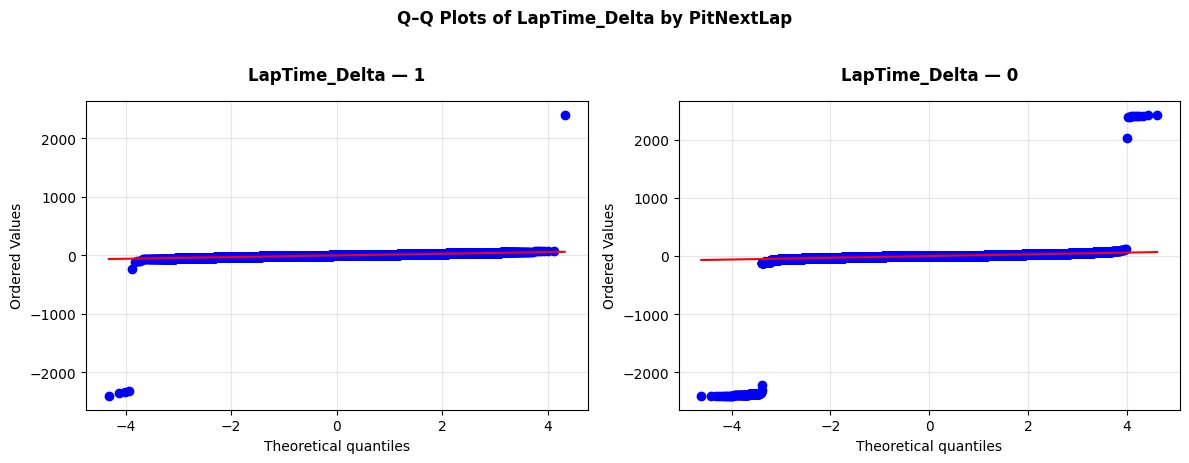

,Feature,Group,Skewness,Kurtosis,Remark
0,LapTime_Delta,0,-38.6693,2302.6198,"Highly skewed, Heavy/light tails"
1,LapTime_Delta,1,-37.8575,6814.0997,"Highly skewed, Heavy/light tails"


2026-05-02 09:16:55 | WARNING  | Normality assumption violated in at least one group.
2026-05-02 09:16:55 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-05-02 09:16:55 | INFO     | Running Mann–Whitney U Test: 'LapTime_Delta' by 'PitNextLap'...
2026-05-02 09:16:55 | DEBUG    | Number of groups detected: 2
2026-05-02 09:16:55 | INFO     | U statistic: 13334848057.0
2026-05-02 09:16:55 | INFO     | p-value    : 0.000000
2026-05-02 09:16:56 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-05-02 09:16:56 | INFO     | Conclusion: Significant difference between the two groups.
2026-05-02 09:16:56 | INFO     | Effect size (r): 0.0915
2026-05-02 09:16:56 | INFO     | Effect size interpretation: Negligible
2026-05-02 09:16:56 | INFO     | Cliff's Delta: 0.1323
2026-05-02 09:16:56 | INFO     | Effect size (Cliff's Delta) interpretation: Negligible


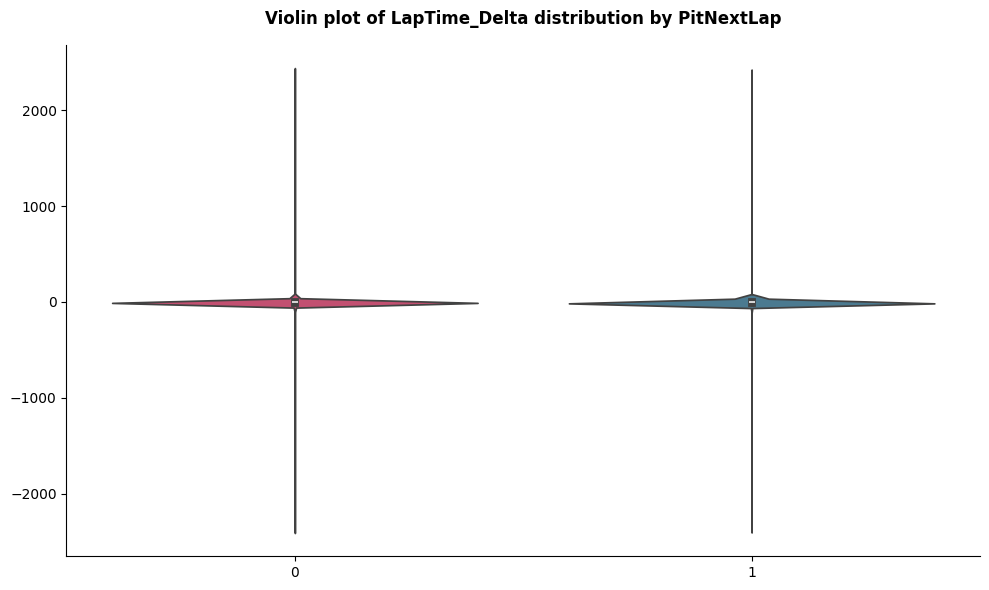

,PitNextLap,Count,Mean,Median,Std
0,0,427273,-21.749264,-19.955999,55.184187
1,1,113172,-44.127049,-32.981499,64.596586


2026-05-02 09:16:57 | INFO     | Checking normality of feature 'Cumulative_Degradation' by groups of 'PitNextLap'...
2026-05-02 09:16:57 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-05-02 09:16:57 | DEBUG    | Number of groups detected: 2
2026-05-02 09:16:57 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-05-02 09:16:57 | DEBUG    | [PitNextLap=0] skew=4.8335, kurtosis=220.4890 → Highly skewed, Heavy/light tails
2026-05-02 09:16:57 | DEBUG    | [PitNextLap=1] skew=-0.3126, kurtosis=31.5813 → Approximately symmetric, Heavy/light tails
2026-05-02 09:16:57 | INFO     | Generating Q–Q plots for visual assessment...


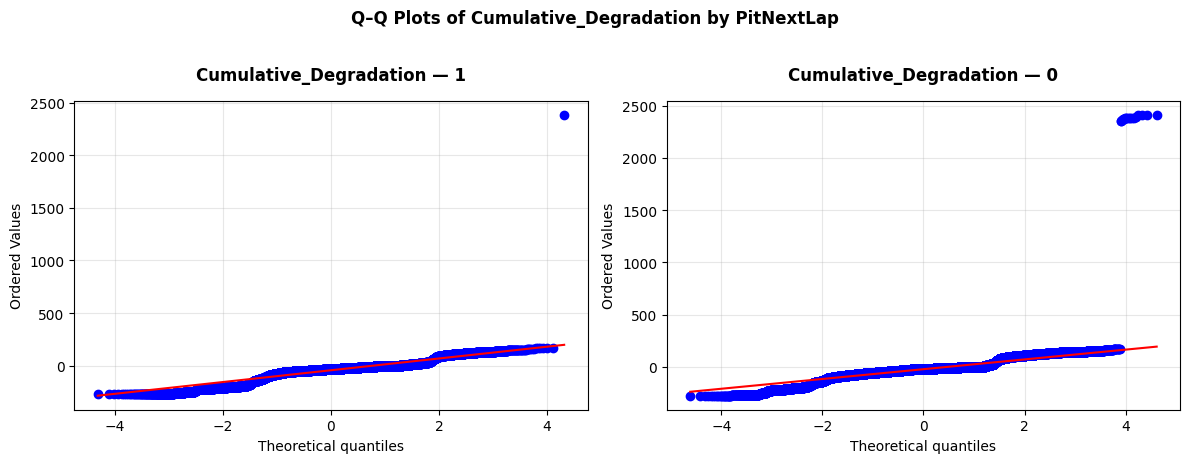

,Feature,Group,Skewness,Kurtosis,Remark
0,Cumulative_Degradation,0,4.8335,220.4890,"Highly skewed, Heavy/light tails"
1,Cumulative_Degradation,1,-0.3126,31.5813,"Approximately symmetric, Heavy/light tails"


2026-05-02 09:16:58 | WARNING  | Normality assumption violated in at least one group.
2026-05-02 09:16:58 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-05-02 09:16:58 | INFO     | Running Mann–Whitney U Test: 'Cumulative_Degradation' by 'PitNextLap'...
2026-05-02 09:16:58 | DEBUG    | Number of groups detected: 2
2026-05-02 09:16:58 | INFO     | U statistic: 11952727609.0
2026-05-02 09:16:58 | INFO     | p-value    : 0.000000
2026-05-02 09:16:59 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-05-02 09:16:59 | INFO     | Conclusion: Significant difference between the two groups.
2026-05-02 09:16:59 | INFO     | Effect size (r): 0.1537
2026-05-02 09:16:59 | INFO     | Effect size interpretation: Small
2026-05-02 09:16:59 | INFO     | Cliff's Delta: 0.2223
2026-05-02 09:16:59 | INFO     | Effect size (Cliff's Delta) interpretation: Small


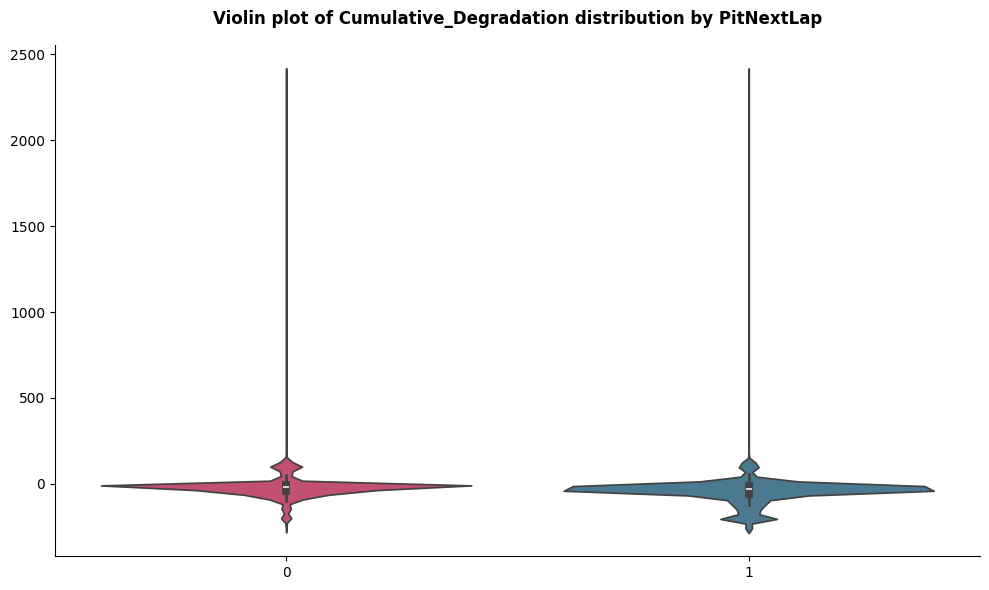

,PitNextLap,Count,Mean,Median,Std
0,1,113172,0.441945,0.448718,0.212317
1,0,427273,0.332510,0.250000,0.262691


2026-05-02 09:17:00 | INFO     | Checking normality of feature 'RaceProgress' by groups of 'PitNextLap'...
2026-05-02 09:17:00 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-05-02 09:17:00 | DEBUG    | Number of groups detected: 2
2026-05-02 09:17:00 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-05-02 09:17:00 | DEBUG    | [PitNextLap=0] skew=0.9081, kurtosis=-0.2104 → Moderately skewed, Normal tails
2026-05-02 09:17:00 | DEBUG    | [PitNextLap=1] skew=0.0165, kurtosis=-0.7387 → Approximately symmetric, Normal tails
2026-05-02 09:17:00 | INFO     | Generating Q–Q plots for visual assessment...


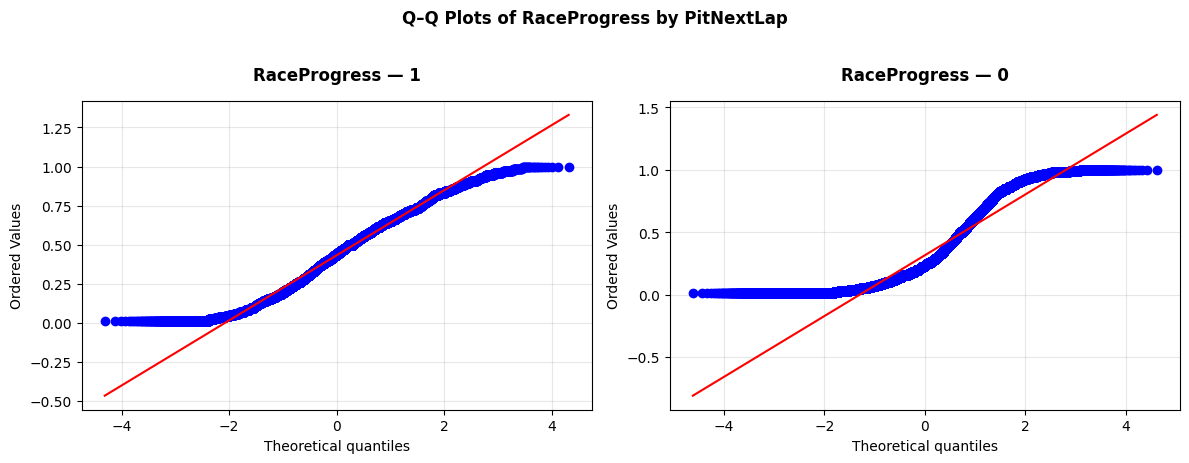

,Feature,Group,Skewness,Kurtosis,Remark
0,RaceProgress,0,0.9081,-0.2104,"Moderately skewed, Normal tails"
1,RaceProgress,1,0.0165,-0.7387,"Approximately symmetric, Normal tails"


2026-05-02 09:17:02 | WARNING  | Normality assumption violated in at least one group.
2026-05-02 09:17:02 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-05-02 09:17:02 | INFO     | Running Mann–Whitney U Test: 'RaceProgress' by 'PitNextLap'...
2026-05-02 09:17:02 | DEBUG    | Number of groups detected: 2
2026-05-02 09:17:02 | INFO     | U statistic: 20420767289.0
2026-05-02 09:17:02 | INFO     | p-value    : 0.000000
2026-05-02 09:17:02 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-05-02 09:17:02 | INFO     | Conclusion: Significant difference between the two groups.
2026-05-02 09:17:02 | INFO     | Effect size (r): 0.2273
2026-05-02 09:17:02 | INFO     | Effect size interpretation: Small
2026-05-02 09:17:02 | INFO     | Cliff's Delta: -0.3287
2026-05-02 09:17:02 | INFO     | Effect size (Cliff's Delta) interpretation: Small


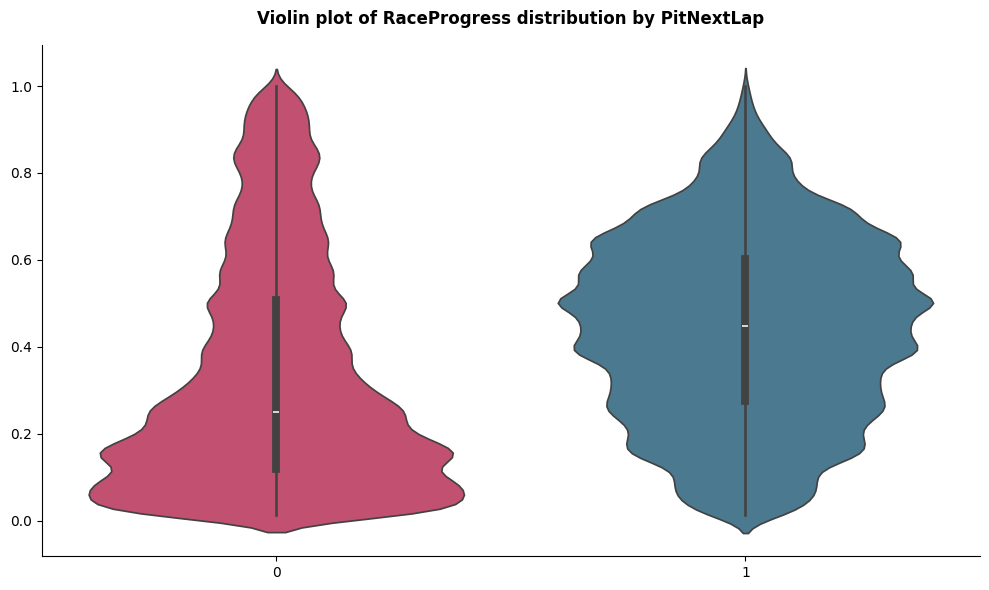

,PitNextLap,Count,Mean,Median,Std
0,1,113172,0.452948,0.000000,4.588433
1,0,427273,-0.016493,0.000000,3.809279


2026-05-02 09:17:04 | INFO     | Checking normality of feature 'Position_Change' by groups of 'PitNextLap'...
2026-05-02 09:17:04 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-05-02 09:17:04 | DEBUG    | Number of groups detected: 2
2026-05-02 09:17:04 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-05-02 09:17:04 | DEBUG    | [PitNextLap=0] skew=-0.1676, kurtosis=2.3459 → Approximately symmetric, Heavy/light tails
2026-05-02 09:17:04 | DEBUG    | [PitNextLap=1] skew=-0.0008, kurtosis=0.3896 → Approximately symmetric, Normal tails
2026-05-02 09:17:04 | INFO     | Generating Q–Q plots for visual assessment...


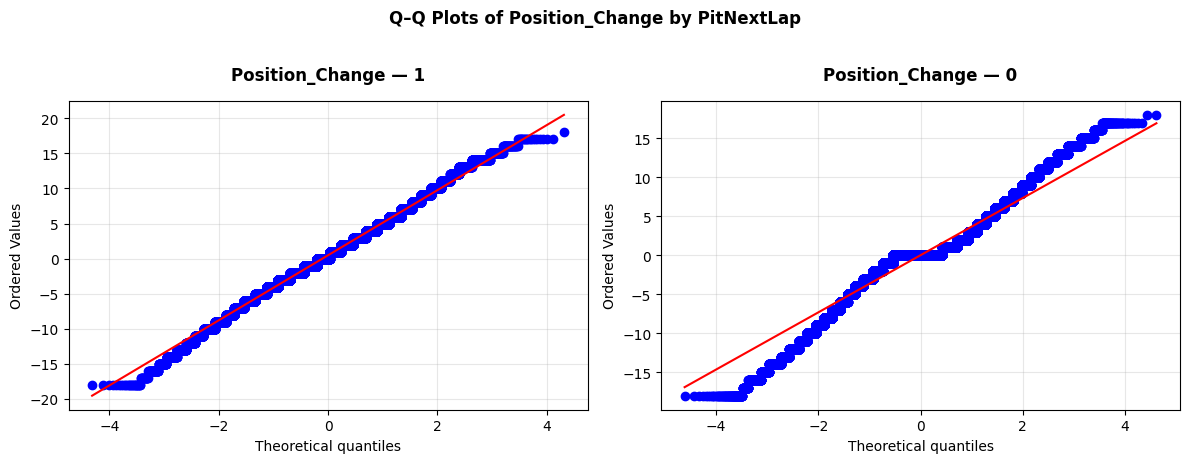

,Feature,Group,Skewness,Kurtosis,Remark
0,Position_Change,0,-0.1676,2.3459,"Approximately symmetric, Heavy/light tails"
1,Position_Change,1,-0.0008,0.3896,"Approximately symmetric, Normal tails"


2026-05-02 09:17:06 | WARNING  | Normality assumption violated in at least one group.
2026-05-02 09:17:06 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-05-02 09:17:06 | INFO     | Running Mann–Whitney U Test: 'Position_Change' by 'PitNextLap'...
2026-05-02 09:17:06 | DEBUG    | Number of groups detected: 2
2026-05-02 09:17:06 | INFO     | U statistic: 16216061497.0
2026-05-02 09:17:06 | INFO     | p-value    : 0.000000
2026-05-02 09:17:06 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-05-02 09:17:06 | INFO     | Conclusion: Significant difference between the two groups.
2026-05-02 09:17:06 | INFO     | Effect size (r): 0.0381
2026-05-02 09:17:06 | INFO     | Effect size interpretation: Negligible
2026-05-02 09:17:06 | INFO     | Cliff's Delta: -0.0551
2026-05-02 09:17:06 | INFO     | Effect size (Cliff's Delta) interpretation: Negligible


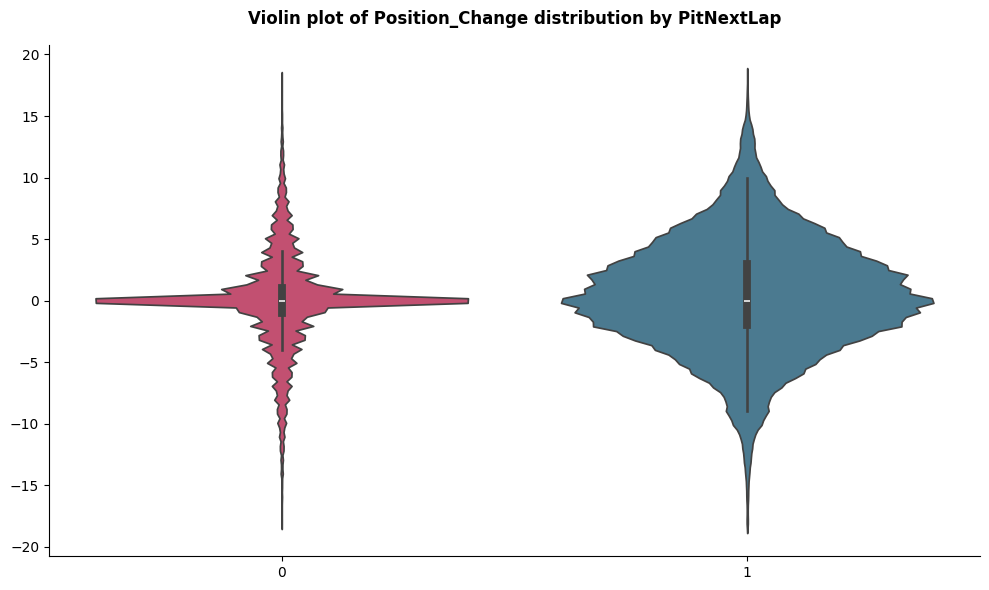

In [50]:
def perform_statical_testing(feature: str, df: pd.DataFrame = df_train, 
                             target_feature: str = CFG.TARGET_FEATURE) -> None:
    """
    Automatically select and perform appropriate statistical tests
    for comparing a numerical feature across categorical groups.

    This function implements a decision-based statistical testing pipeline
    that selects parametric or non-parametric tests based on:

    - Distribution normality (via skewness, kurtosis, and Q–Q plots)
    - Homogeneity of variances
    - Number of categorical groups

    The procedure follows standard statistical analysis guidelines:

    1. Check normality of the numerical feature within each group.
    2. Determine the number of comparison groups.
    3. Evaluate homogeneity of variance when parametric tests are applicable.
    4. Select and execute the most appropriate hypothesis test.

    Decision Logic
    --------------
    For more than two groups:

    - Non-normal distribution → Kruskal–Wallis test
    - Normal + equal variances → One-way ANOVA + Tukey HSD
    - Normal + unequal variances → Welch’s ANOVA
    - Otherwise → Kruskal–Wallis test

    For two groups:

    - Non-normal distribution → Mann–Whitney U test
    - Normal + equal variances → Independent t-test (with Cohen’s d)
    - Normal + unequal variances → Welch’s t-test (with Cohen’s d)
    - Otherwise → Mann–Whitney U test

    The function also reports effect sizes and post-hoc comparisons
    where applicable.

    Parameters
    ----------
    feature : str
        Name of the numerical feature to be analyzed.

    df : pandas.DataFrame, default=df_train
        Dataset containing the numerical feature and categorical target.

    target_feature : str, default=config.target_feature
        Categorical variable defining comparison groups.

    Returns
    -------
    None
        Executes statistical tests and logs/prints results.
        No value is returned.

    Notes
    -----
    - This function is designed for exploratory and confirmatory
      statistical analysis in machine learning and research workflows.
    - Assumption checks (normality and homoscedasticity) are performed
      automatically prior to testing.
    - For small sample sizes, non-parametric tests are generally preferred.

    Examples
    --------
    >>> perform_statical_testing(
    ...     feature="cholesterol",
    ...     df=df_train,
    ...     target_feature="heart_disease"
    ... )
    """

    # Step 1: Check normality of the feature in each group
    non_normal_detected = check_normality_with_plots(df=df, feature=feature, target_feature=target_feature)
    # Count number of categories in target feature
    total_categories = df[target_feature].nunique()
    # Case 1: More than two groups (Multi-class comparison)
    if total_categories > 2:
        # If data is not normally distributed → use Kruskal–Wallis
        if non_normal_detected:
            perform_kruskal_test(df=df, categorical_feature=target_feature,
                                numeric_feature=feature)
        # If data is approximately normal → check variance homogeneity
        else:
            anove_use, is_homogeneous_variances = check_homogeneity_of_variance(df=df, feature=feature,
                                                                                target_feature=target_feature)
            # Normal + equal variance → One-way ANOVA + Tukey test
            if anove_use and is_homogeneous_variances:
                perform_anova_with_tukey(df=df, numeric_feature=feature,
                                        categorical_feature=target_feature)
            # Normal + unequal variance → Welch ANOVA
            elif anove_use and is_homogeneous_variances == False:
                perform_welch_anova(df=df, numeric_feature=feature, categorical_feature=target_feature)
            # Otherwise → fallback to Kruskal–Wallis
            else:
                perform_kruskal_test(df=df, categorical_feature=target_feature,
                        numeric_feature=feature)
    # Case 2: Two groups (Binary comparison)
    else:
        # If data is not normal → use Mann–Whitney U test
        if non_normal_detected:
            cal_mannwhitneyu(dataframe=df, categorical_feature=target_feature, num_feature=feature)
        # If data is approximately normal → check variance homogeneity
        else:
            anove_use, is_homogeneous_variances = check_homogeneity_of_variance(df=df, feature=feature,
                                                                                target_feature=target_feature)
            # Normal + equal variance → Independent t-test + Cohen's d
            if anove_use and is_homogeneous_variances:
                t_test_with_cohens_d(data=df, categorical_feature=target_feature, num_feature=feature, equal_var=True)
            # Normal + unequal variance → Welch t-test + Cohen's d
            elif anove_use and is_homogeneous_variances == False:
                t_test_with_cohens_d(data=df, categorical_feature=target_feature, num_feature=feature, equal_var=False)
            # Otherwise → fallback to Mann–Whitney U
            else:
                cal_mannwhitneyu(dataframe=df, categorical_feature=target_feature, num_feature=feature)

def plot_numerical_distribution(feature: str, df: pd.DataFrame = df_train,
                                target_feature: str = CFG.TARGET_FEATURE, order: list = None) -> None:
    """
    Analyze and visualize the distribution of a numerical feature
    across categories of a target variable.

    This function performs:
    - Descriptive statistics (mean, median, std) by group
    - Overall summary statistics
    - Automated statistical hypothesis testing
    - Violin plot visualization

    Parameters
    ----------
    feature : str
        Numerical feature to be analyzed.

    df : pandas.DataFrame
        Input dataset containing the feature and target variable.

    target_feature : str
        Categorical variable used for grouping.

    order : list, optional
        Custom order of categories for plotting.

    Returns
    -------
    None
        Displays summary tables, test results, and plots.
    """

    # Compute summary statistics for each Fertilizer category
    df_summary_feature = (
        df.groupby(by=target_feature, as_index=False)
        .agg(
            Count=(feature, "count"),
            Mean=(feature, "mean"),
            Median=(feature, "median"),
            Std=(feature, "std")
        )
        .sort_values(by="Mean", ascending=False).reset_index(drop=True)
    )

    # Compute global statistics for the entire feature
    summary_data = [
        ("Overall Mean", f"{df[feature].mean():.2f}"),
        ("Overall Median", f"{df[feature].median()}"),
        ("Overall Std", f"{df[feature].std():.2f}")
    ]

    # Display overall statistics in HTML format for better notebook visualization
    summary_html = "<ul>" + "".join([
        f"<li><b>{k}:</b> {v}</li>" for k, v in summary_data
    ]) + "</ul>"
    display(HTML(summary_html))

    # Display detailed summary per category as styled dataframe
    display(
        df_summary_feature.style.background_gradient(cmap=cm)
        .set_table_attributes('style="width:75%; margin:auto;"')
    )

    # Run statistical significance testing
    perform_statical_testing(feature=feature, target_feature=target_feature)

    # Visualize distribution via violin plot
    plt.figure(figsize=(10, 6))
    sns.violinplot(x=target_feature, y=feature, data=df, hue=target_feature, order=order,
                   palette=color(n_colors=df[target_feature].nunique()))

    plt.title(f"Violin plot of {feature} distribution by {target_feature}", pad=15, weight="bold", fontsize=12)
    plt.xlabel("")
    plt.ylabel("")
    plt.legend().remove()
    sns.despine(left=False, bottom=False)
    plt.tight_layout()
    plt.show()

# Merge datasets and drop duplicates
df_train = pd.concat([df_train, df_original], axis=0).reset_index(drop=True)
df_train = df_train.drop_duplicates()

for feature in num_features:
    display(HTML(f"<h2 style='text-align:center; font-size:22px; color:green;'><b>Distribution of {feature} by PitNextLap</b></h2>"))
    plot_numerical_distribution(feature=feature, df = df_train)

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Statistical Insights (PitNextLap vs Numerical Features)
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li><b>LapNumber:</b> Statistically significant difference (<code>p &lt; 0.05</code>), with cars tending to pit at <b>later laps</b>, although distributions still overlap substantially.</li>

<li><b>Stint:</b> Statistically significant (<code>p &lt; 0.05</code>), with pit stops more likely in <b>later stints</b>; effect size is <b>moderate</b> due to overlapping distributions.</li>

<li><b>TyreLife:</b> Statistically significant (<code>p &lt; 0.05</code>), with pit stops occurring when <b>tyres are more worn</b>; effect size remains <b>moderate</b>.</li>

<li><b>Position:</b> Statistically significant (<code>p &lt; 0.05</code>) but with <b>negligible effect size</b>, indicating almost no practical difference.</li>

<li><b>LapTime_s:</b> Statistically significant (<code>p &lt; 0.05</code>) but <b>practically negligible</b>, suggesting minimal real-world impact.</li>

<li><b>LapTime_Delta:</b> Statistically significant (<code>p &lt; 0.05</code>) but with <b>no meaningful practical difference</b> between groups.</li>

<li><b>Cumulative_Degradation:</b> Statistically significant (<code>p &lt; 0.05</code>), with slightly <b>higher degradation linked to pit stops</b>; effect size is <b>small</b>.</li>

<li><b>RaceProgress:</b> Statistically significant (<code>p &lt; 0.05</code>), with pit stops more likely <b>later in the race</b>; effect size is <b>small</b>.</li>

<li><b>Position_Change:</b> Statistically significant (<code>p &lt; 0.05</code>) but with <b>negligible effect size</b>, indicating nearly identical distributions.</li>

</ul>

</div>


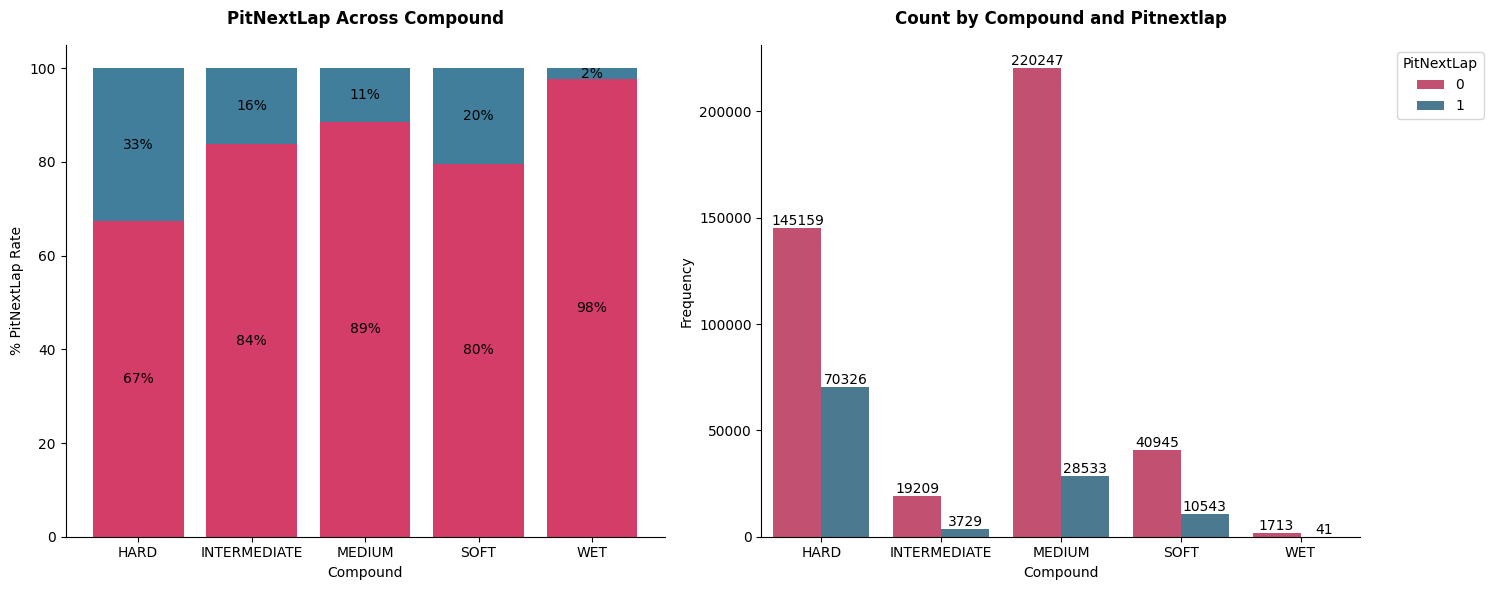

2026-05-02 09:17:09 | INFO     | Chi-Square Test of Independence: 'Compound' vs. 'PitNextLap'...
2026-05-02 09:17:09 | INFO     | Chi-squared statistic: 31961.734
2026-05-02 09:17:09 | INFO     | Degrees of freedom: 4
2026-05-02 09:17:09 | INFO     | p-value: 0.000000
2026-05-02 09:17:09 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-05-02 09:17:09 | INFO     | Variables 'Compound' and 'PitNextLap' are statistically associated.
2026-05-02 09:17:09 | DEBUG    | Displaying standardized residuals heatmap.


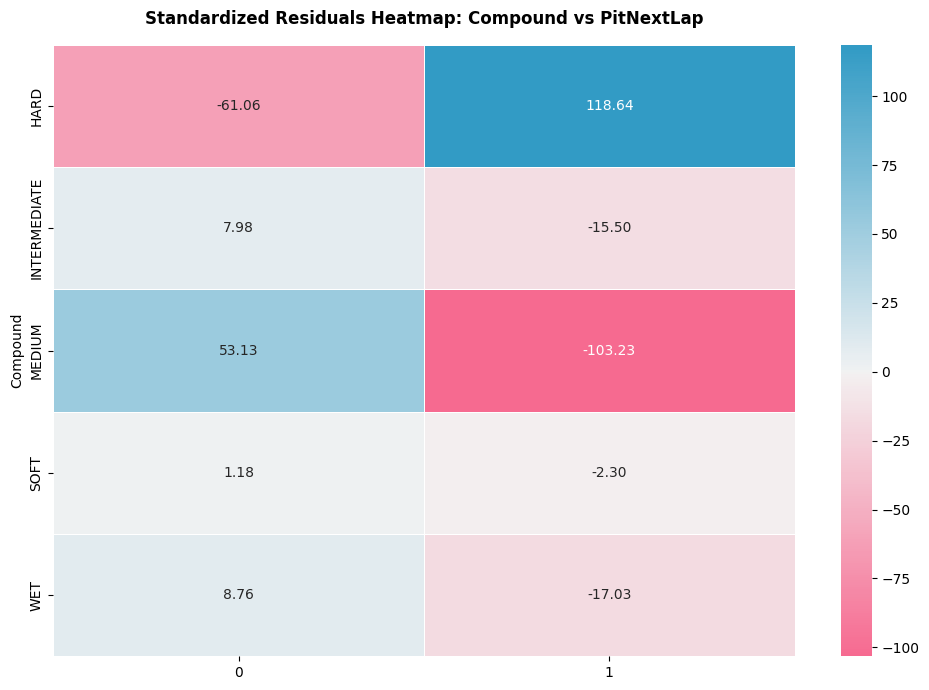

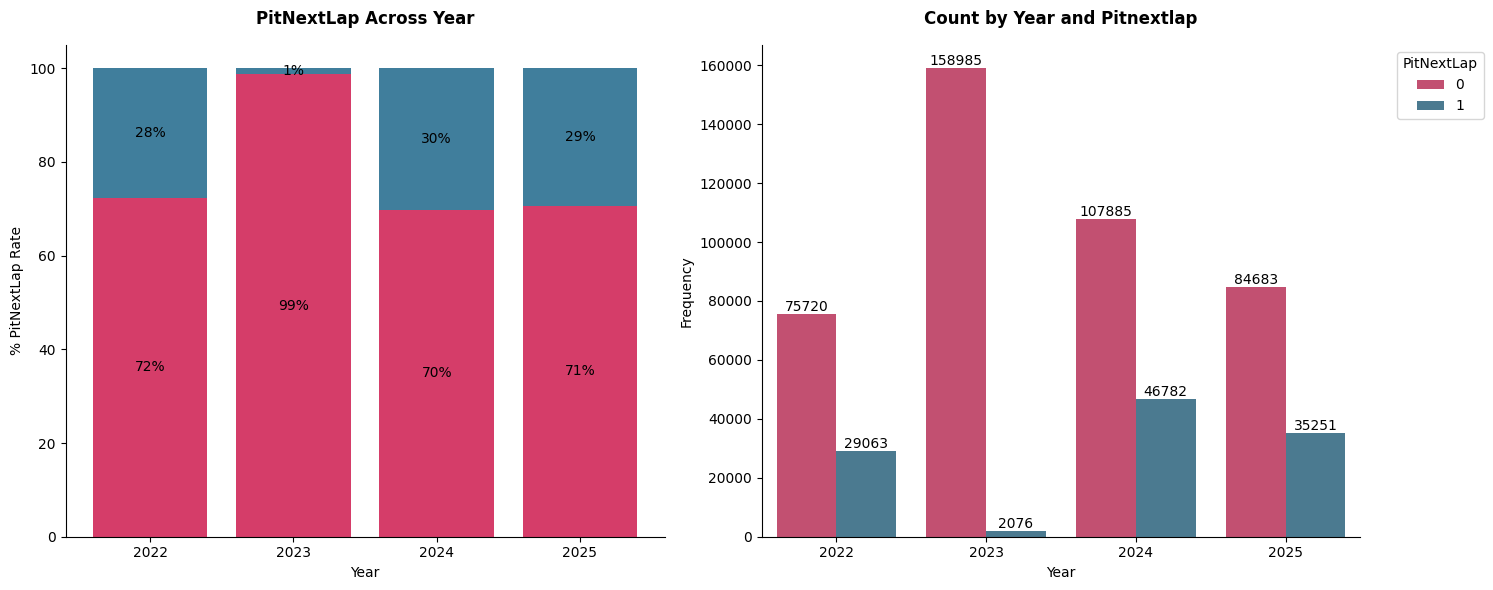

2026-05-02 09:17:10 | INFO     | Chi-Square Test of Independence: 'Year' vs. 'PitNextLap'...
2026-05-02 09:17:10 | INFO     | Chi-squared statistic: 53759.037
2026-05-02 09:17:10 | INFO     | Degrees of freedom: 3
2026-05-02 09:17:10 | INFO     | p-value: 0.000000
2026-05-02 09:17:10 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-05-02 09:17:10 | INFO     | Variables 'Year' and 'PitNextLap' are statistically associated.
2026-05-02 09:17:10 | DEBUG    | Displaying standardized residuals heatmap.


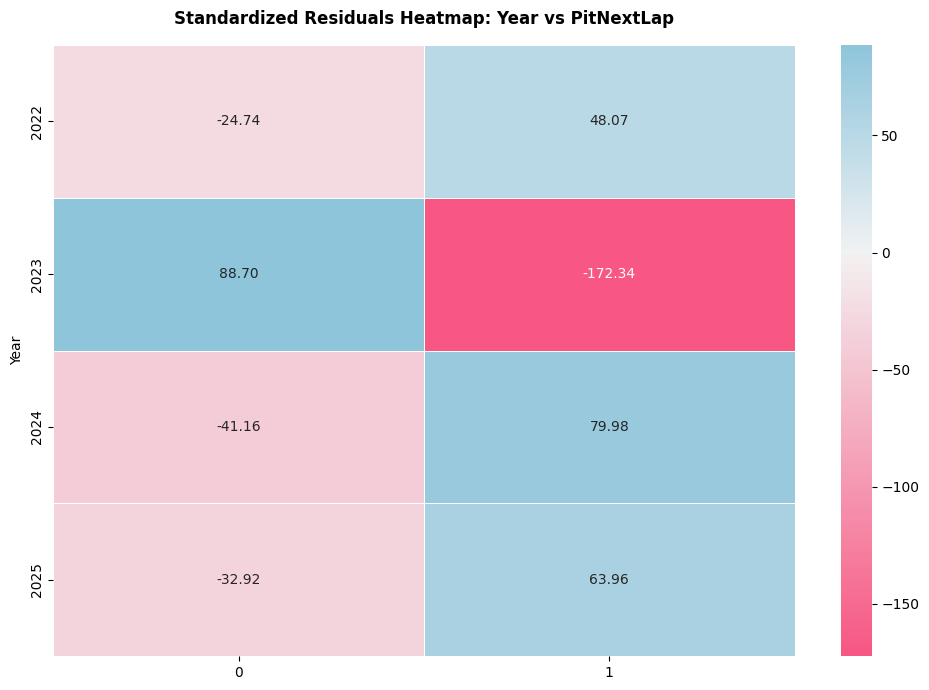

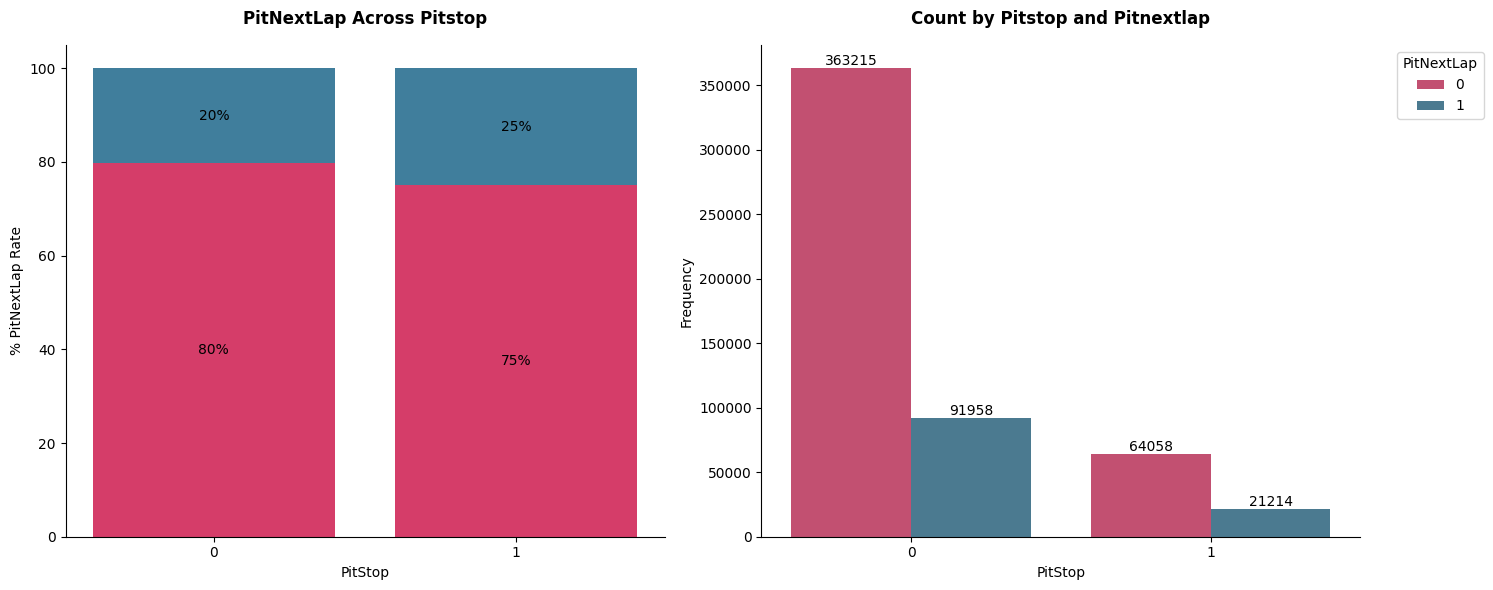

2026-05-02 09:17:11 | INFO     | Chi-Square Test of Independence: 'PitStop' vs. 'PitNextLap'...
2026-05-02 09:17:11 | INFO     | Chi-squared statistic: 947.884
2026-05-02 09:17:11 | INFO     | Degrees of freedom: 1
2026-05-02 09:17:11 | INFO     | p-value: 0.000000
2026-05-02 09:17:11 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-05-02 09:17:11 | INFO     | Variables 'PitStop' and 'PitNextLap' are statistically associated.
2026-05-02 09:17:11 | DEBUG    | Displaying standardized residuals heatmap.


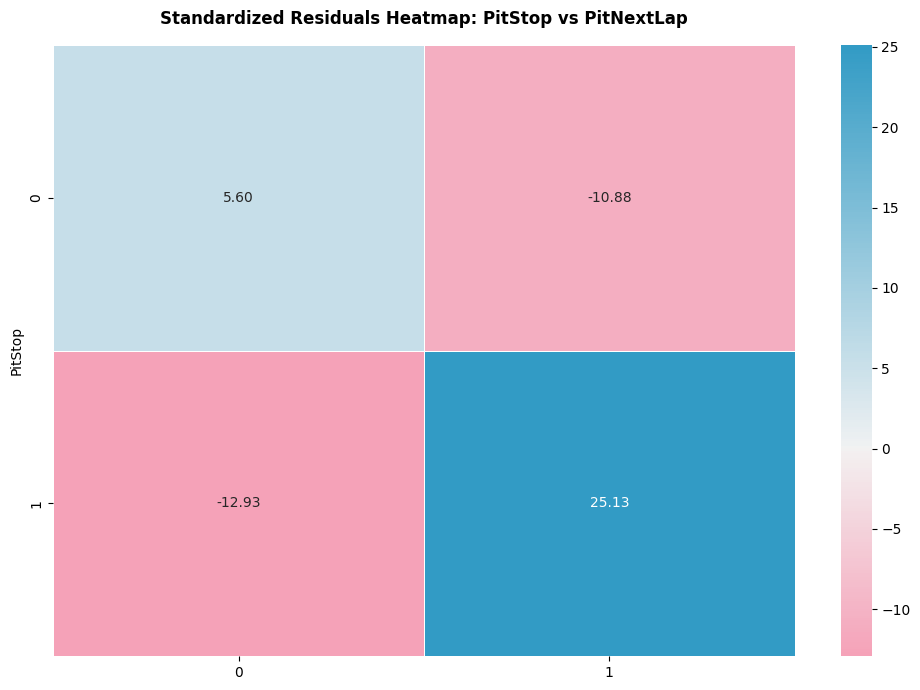

In [51]:
def bivariate_percent_plot(cat: str, target_feature: str,
                           df: pd.DataFrame, figsize=(15, 6), order=None) -> None:
    """
    Plot the relationship between a categorical feature and the target variable.

    This function displays:
    - A stacked bar chart showing percentage distribution of target classes.
    - A count plot showing absolute frequencies.
    - A Chi-Square test for feature–target dependence.

    Parameters
    ----------
    cat : str
        Categorical feature name.

    target_feature : str
        Target variable name.

    df : pd.DataFrame
        Input dataset.

    figsize : tuple, optional
        Figure size (width, height). Default is (15, 6).

    order : list, optional
        Custom order of categories on x-axis.

    Returns
    -------
    None
    """

    display(HTML(f"<h2 style='text-align:center; font-size:22px; color:green;'><b>Distribution of {cat.title()} by {target_feature.title()}</b></h2>"))
    fig, ax = plt.subplots(nrows=1, ncols=2, sharey=False, figsize=figsize)

    # Data processing
    grouped = df.groupby([cat, target_feature]).size().unstack(fill_value=0)

    # Define a fixed hue order (adjust if needed)
    target_order = [c for c in ["Yes", "No"] if c in grouped.columns]

    # Fallback if the labels are 0/1 or have different names
    if not target_order:
        target_order = list(grouped.columns)

    # Calculate percentages row-wise and reorder columns by target_order
    percentages = grouped.div(grouped.sum(axis=1), axis=0)[target_order] * 100

    # Define X-axis category order
    if order is not None:
        percentages = percentages.loc[order]
        labels = order
    else:
        labels = percentages.index.tolist()

    # Consistent color palette for both charts
    base_colors = color(n_colors=len(target_order))
    color_map = dict(zip(target_order, base_colors))

    # Plot 1: Stacked bar chart (percentage)
    bottom = np.zeros(len(percentages))
    for cls in target_order:
        ax[0].bar(percentages.index.astype(str), percentages[cls].values, bottom=bottom,
                  label=cls, color=color_map[cls])
        bottom += percentages[cls].values

    # Add percentage labels
    for container in ax[0].containers:
        ax[0].bar_label(container, fmt="%1.0f%%", label_type="center",
                        fontsize=10, color="black")

    ax[0].set_title(f"PitNextLap Across {cat.replace('_', ' ').title()}", fontsize=12, weight="bold", pad=15)
    ax[0].set_xlabel(f"{cat}", fontsize=10)
    ax[0].set_ylabel(f"% {target_feature} Rate", fontsize=10)
    sns.despine(left=False, bottom=False, ax=ax[0])
    ax[0].legend().remove()

    # Plot 2: Count plot (using same color_map + hue_order)
    sns.countplot(data=df, hue=target_feature, x=cat,
                  order=labels, hue_order=target_order,
                  palette=color_map, ax=ax[1])

    for container in ax[1].containers:
        ax[1].bar_label(container, fmt="%d", label_type="edge",
                        fontsize=10, color="black")

    ax[1].set_title(f"Count by {cat.replace('_', ' ').title()} and {target_feature.replace('_', ' ').title()}", fontsize=12, weight="bold", pad=15)
    ax[1].set_xlabel(f"{cat}", fontsize=10)
    ax[1].set_ylabel("Frequency", fontsize=10)
    ax[1].legend(title=target_feature, bbox_to_anchor=(1.05, 1), loc="upper left")
    sns.despine(left=False, bottom=False, ax=ax[1])
    plt.tight_layout()
    plt.show()

    # Chi-Square Test
    cal_ChiSquare(cat_feature=cat, target_feature=target_feature, df=df, show_residuals=True)

# Run for all categorical features
# Categorical features
cat_features3 = ["Compound", "Year", "PitStop"]
for feature in cat_features3:
    bivariate_percent_plot(cat=feature, target_feature=CFG.TARGET_FEATURE, df=df_train)

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 20px;
    border-radius: 12px;
    margin: 20px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 15px 0; 
    font-size: 20px; 
    font-weight: 600;
">
📊 Categorical Feature Insights
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li><b>Compound:</b> Strongly associated with <code>PitNextLap</code> (<code>p &lt; 0.05</code>), with <b>HARD tyres increasing pit likelihood</b> while <code>MEDIUM</code> tyres show the opposite pattern.</li>

<li><b>Year:</b> Statistically associated (<code>p &lt; 0.05</code>), with <b>2023 showing significantly fewer pit events</b> while other years have higher-than-expected pit rates.</li>

<li><b>PitStop:</b> Strongly associated (<code>p &lt; 0.05</code>), with cars that have just pitted being <b>more likely to pit again in the next lap</b>, indicating sequential pit behavior.</li>

</ul>

</div>


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Overall Picture</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Overall Picture
    </h1>
</div>

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Consolidated Feature Impact Summary – Pit Strategy (PitNextLap)
</div>

<table style="
    width:100%;
    border-collapse: collapse;
    font-size: 14px;
">

<thead>
<tr style="background-color: rgba(249,231,159,0.15);">
<th style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:left;">Feature</th>
<th style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:left;">Summary</th>
</tr>
</thead>

<tbody>

<tr>
<td><b>Stint</b></td>
<td><b>Primary driver</b> — strong and consistent signal, with pit stops more likely in later stints.</td>
</tr>

<tr>
<td><b>TyreLife</b></td>
<td><b>Core degradation signal</b> — higher tyre wear significantly increases pit probability.</td>
</tr>

<tr>
<td><b>RaceProgress</b></td>
<td><b>Temporal driver</b> — pit stops tend to occur later in the race, reflecting strategic timing.</td>
</tr>

<tr>
<td><b>LapNumber</b></td>
<td><b>Supporting temporal signal</b> — later laps are associated with higher pit likelihood, though distributions overlap.</td>
</tr>

<tr>
<td><b>Cumulative_Degradation</b></td>
<td><b>Accumulated wear factor</b> — higher degradation slightly increases pit probability but with limited separation.</td>
</tr>

<tr>
<td><b>Compound</b></td>
<td><b>Strategic categorical driver</b> — HARD tyres strongly increase pit likelihood, while MEDIUM tyres reduce it.</td>
</tr>

<tr>
<td><b>PitStop</b></td>
<td><b>Sequential behavior signal</b> — strong dependency indicating consecutive pit decisions.</td>
</tr>

<tr>
<td><b>Year</b></td>
<td><b>Contextual factor</b> — strategy varies by season, with notable deviation in 2023.</td>
</tr>

<tr>
<td><b>Position</b></td>
<td><b>Weak signal</b> — statistically significant but negligible practical impact.</td>
</tr>

<tr>
<td><b>LapTime_s</b></td>
<td><b>Weak performance indicator</b> — minimal practical difference despite statistical significance.</td>
</tr>

<tr>
<td><b>LapTime_Delta</b></td>
<td><b>No meaningful impact</b> — differences are statistically detectable but practically negligible.</td>
</tr>

<tr>
<td><b>Position_Change</b></td>
<td><b>Irrelevant signal</b> — distributions are nearly identical across groups.</td>
</tr>

</tbody>
</table>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">
<b>Key Insight:</b> Pit decisions are primarily driven by <b>race progression and tyre degradation dynamics</b> (Stint, TyreLife, RaceProgress), while most performance-based metrics contribute <b>limited practical value</b>, emphasizing strategy over raw speed indicators.
</div>

</div>


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Feature Engineering & Preprocessing</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Feature Engineering & Preprocessing
    </h1>
</div>

We will separate features from the target, handle categorical variables using an **OrdinalEncoder**, and add some basic Frequency Encoding to help the tree-based model understand the distribution of categories (like Drivers or Circuits).

In [52]:
# DATA PREPARATION
features = [feat for feat in df_test.columns if feat != "id"]
cat_cols = df_test.select_dtypes(include=["object", "category"]).columns.tolist()

X = df_train[features].copy()
y = df_train[CFG.TARGET_FEATURE].copy()
X_test = df_test[features].copy()

# Add Frequency Encoding for categorical features
for col in cat_cols:
    freq_map = X[col].value_counts(normalize=True).to_dict()
    X[f"{col}_freq"] = X[col].map(freq_map).astype(float)
    X_test[f"{col}_freq"] = X_test[col].map(freq_map).astype(float).fillna(0)

# Update features list with new frequency features
features = X.columns.tolist()

# ENCODER CAT_COLUMNS
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

if cat_cols:
    X[cat_cols] = encoder.fit_transform(X[cat_cols].astype(str))
    X_test[cat_cols] = encoder.transform(X_test[cat_cols].astype(str))
    
    X[cat_cols] = X[cat_cols].astype(int)
    X_test[cat_cols] = X_test[cat_cols].astype(int)

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Hyperparameter Tuning with Optuna</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Hyperparameter Tuning with Optuna
    </h1>
</div>

In [ ]:
def plot_oof_metrics(y_true, oof_preds, fold_preds, threshold=0.5):
    """
    Plot ROC, Precision-Recall curves (by fold) and Confusion Matrix (OOF)

    Parameters
    ----------
    y_true : array-like
        Ground truth labels

    oof_preds : array-like
        Out-of-fold predicted probabilities

    fold_preds : list of tuples
        Each element: (y_val, val_pred) for each fold

    threshold : float, default=0.5
        Threshold for confusion matrix
    """

    roc_curves = []
    pr_curves = []
    auc_values = []
    ap_values = []

    # ================= Collect metrics per fold =================
    for i, (y_val, val_pred) in enumerate(fold_preds):
        # ROC
        fpr, tpr, _ = roc_curve(y_val, val_pred)
        roc_curves.append((fpr, tpr))

        auc = roc_auc_score(y_val, val_pred)
        auc_values.append(auc)

        # PR
        precision, recall, _ = precision_recall_curve(y_val, val_pred)
        pr_curves.append((recall, precision))

        ap = average_precision_score(y_val, val_pred)
        ap_values.append(ap)

    # ================= Plot =================
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))

    # ---------------- ROC ----------------
    ax = axes[0, 0]

    for i, (fpr, tpr) in enumerate(roc_curves):
        ax.plot(fpr, tpr, label=f"Fold {i+1} AUC = {auc_values[i]:.4f}")

    ax.plot([0, 1], [0, 1], "--", color="gray")
    ax.set_title("ROC Curve (Each Fold)", weight="bold")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()
    ax.grid(True)

    # ---------------- PR ----------------
    ax = axes[0, 1]

    for i, (recall, precision) in enumerate(pr_curves):
        ax.plot(recall, precision, label=f"Fold {i+1} AP = {ap_values[i]:.4f}")

    ax.set_title("Precision–Recall Curve (Each Fold)", weight="bold", pad=15, fontsize=12)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()
    ax.grid(True)

    # ---------------- Confusion Matrix ----------------
    ax = axes[1, 0]

    y_pred_label = (oof_preds >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred_label)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"Confusion Matrix (Threshold = {threshold})", weight="bold", pad=15, fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    # Empty plot
    axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()

## XGBClassifier

In [ ]:
# OPTUNA HYPERPARAMETER SEARCH
logger.info("Starting Optuna optimization...")

def objective(trial):
    pos = y.sum()
    neg = len(y) - pos
    base_ratio = neg / pos if pos > 0 else 1
    # Parameter search space
    param = {
        "n_estimators": 3000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05, log=True),
        "max_depth": trial.suggest_int("max_depth", 4, 9),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),        
        # GPU and Engine configuration
        "tree_method": "hist",
        "device": "cuda",
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "random_state": CFG.RANDOM_STATE,
        "n_jobs": -1,
        "verbose": 0,
        "use_label_encoder": False,
        "booster": "gbtree",
        "scale_pos_weight": trial.suggest_float(
            "scale_pos_weight",
            base_ratio * 0.5,
            base_ratio * 2
        )
    }
    
    # Fast 3-Fold CV for evaluating Optuna trials
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=CFG.RANDOM_STATE)
    cv_scores = np.zeros(3)
    
    for idx, (train_idx, valid_idx) in enumerate(cv.split(X, y)):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X.iloc[valid_idx], y.iloc[valid_idx]
        
        # Pruning callback to stop bad trials early
        pruning_callback = optuna.integration.XGBoostPruningCallback(trial, "validation_0-auc")
        
        model = xgb.XGBClassifier(**param, early_stopping_rounds=100, callbacks=[pruning_callback])
        
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            verbose=False            
        )
        
        preds = model.predict_proba(X_va)[:, 1]
        cv_scores[idx] = roc_auc_score(y_va, preds)
        
    return np.mean(cv_scores)

# Create study and run optimization
study = optuna.create_study(direction="maximize", study_name="XGB_F1_PitStops")
study.optimize(objective, n_trials=60, show_progress_bar=True)

In [ ]:
# Merge Optuna"s best params with our heavy-duty final training params
final_params_xgb = study.best_params.copy()
final_params_xgb.update({
    "n_estimators": 15000,
    "early_stopping_rounds": 300,
    "tree_method": "hist",
    "device": "cuda",
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "random_state": CFG.RANDOM_STATE,
    "n_jobs": -1,
    "verbose": 0,
    "use_label_encoder": False,
    "booster": "gbtree",
})

# MAIN 10-FOLD TRAINING
skf = StratifiedKFold(n_splits=CFG.N_SPLIT_KFOLD, shuffle=True, random_state=CFG.RANDOM_STATE)

oof_preds_xgb = np.zeros(len(X))
test_preds_xgb = np.zeros(len(X_test))
# Store predictions of each fold for later visualization/analysis
# Each element: (true_labels, predicted_probs)
fold_preds_xgb = []

feature_importances_xgb = np.zeros(len(X.columns))

logger.info("*"*80)
logger.info(f"Starting Final Stratified {CFG.N_SPLIT_KFOLD}-Fold Training on GPU...")
logger.info("*"*80)

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
    X_valid_fold, y_valid_fold = X.iloc[valid_idx], y.iloc[valid_idx]
    
    model_xgb = xgb.XGBClassifier(**final_params_xgb)
    
    model_xgb.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_valid_fold, y_valid_fold)],
        verbose=False
    )
    
    # Predict Probabilities
    valid_fold_preds = model_xgb.predict_proba(X_valid_fold)[:, 1]
    oof_preds_xgb[valid_idx] = valid_fold_preds

    # Store fold predictions for plotting
    fold_preds_xgb.append((y_valid_fold.values, valid_fold_preds))
    
    # Accumulate test predictions
    test_preds_xgb += model_xgb.predict_proba(X_test)[:, 1] / CFG.N_SPLIT_KFOLD

    # Average importance
    feature_importances_xgb += model_xgb.feature_importances_ / CFG.N_SPLIT_KFOLD
    
    fold_auc = roc_auc_score(y_valid_fold, valid_fold_preds)
    logger.debug(f"Fold {fold + 1:02d} | Best Iteration: {model_xgb.best_iteration} | AUC: {fold_auc:.5f}")

# Calculate overall Out-Of-Fold AUC
oof_auc = roc_auc_score(y, oof_preds_xgb)
logger.info("*"*80)
logger.info(f"Final {CFG.N_SPLIT_KFOLD}-Fold Out-Of-Fold (OOF) AUC: {oof_auc:.5f}")
logger.info("*"*80)

# Plot OOF + Fold Metrics
plot_oof_metrics(y_true=y.values, oof_preds=oof_preds_xgb, fold_preds=fold_preds_xgb, threshold=0.5)

## CatBoostClassifier

In [ ]:
# CATBOOST OPTUNA SEARCH
logger.info("Starting CatBoost Optuna optimization...")

def cb_objective(trial):
    bootstrap_type = trial.suggest_categorical(
        "bootstrap_type",
        ["Bayesian", "Bernoulli"]
    )

    param = {
        "iterations": 1500, # Lower cap for search speed
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "random_strength": trial.suggest_float("random_strength", 0.1, 10.0, log=True),
        # Core configuration
        "eval_metric": "Logloss",
        "loss_function": "Logloss",
        "grow_policy": "Lossguide",
        "task_type": "GPU",
        "random_seed": CFG.RANDOM_STATE,
        "verbose": False,
        "thread_count": -1,
        "bootstrap_type": bootstrap_type,
        "auto_class_weights": trial.suggest_categorical("auto_class_weights", ["Balanced", "SqrtBalanced", None])
    }

    if bootstrap_type == "Bayesian":
        param["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0, 5)

    elif bootstrap_type == "Bernoulli":
        param["subsample"] = trial.suggest_float("subsample", 0.5, 1.0)
    
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=CFG.RANDOM_STATE)
    cv_scores = np.zeros(3)
    
    for idx, (train_idx, valid_idx) in enumerate(cv.split(X, y)):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X.iloc[valid_idx], y.iloc[valid_idx]
        
        # Note: CatBoost handles early stopping automatically during fit
        model = CatBoostClassifier(**param)
        
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            early_stopping_rounds=300,
            verbose=False
        )
        
        preds = model.predict_proba(X_va)[:, 1]
        cv_scores[idx] = roc_auc_score(y_va, preds)
        
    return np.mean(cv_scores)

cb_study = optuna.create_study(direction="maximize", study_name="CB_F1_PitStops")
cb_study.optimize(cb_objective, n_trials=60, show_progress_bar=True)

In [ ]:
# Merge Optuna"s best params with our heavy-duty final training params
final_params_cb = cb_study.best_params.copy()
final_params_cb.update({
    "iterations": 15000,
    "eval_metric": "Logloss",
    "loss_function": "Logloss",
    "task_type": "GPU",
    "random_seed": CFG.RANDOM_STATE,
    "verbose": False,
    "thread_count": -1
})

# MAIN 10-FOLD TRAINING
skf = StratifiedKFold(n_splits=CFG.N_SPLIT_KFOLD, shuffle=True, random_state=CFG.RANDOM_STATE)

oof_preds_cb = np.zeros(len(X))
test_preds_cb = np.zeros(len(X_test))
# Store predictions of each fold for later visualization/analysis
# Each element: (true_labels, predicted_probs)
fold_preds_cb = []

feature_importances_cb = np.zeros(len(X.columns))

logger.info("*"*80)
logger.info(f"Starting Final Stratified {CFG.N_SPLIT_KFOLD}-Fold Training on GPU...")
logger.info("*"*80)

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
    X_valid_fold, y_valid_fold = X.iloc[valid_idx], y.iloc[valid_idx]
    
    model_cb = CatBoostClassifier(**final_params_cb)
    
    model_cb.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_valid_fold, y_valid_fold)],
        verbose=False
    )
    
    # Predict Probabilities
    valid_fold_preds = model_cb.predict_proba(X_valid_fold)[:, 1]
    oof_preds_cb[valid_idx] = valid_fold_preds

    # Store fold predictions for plotting
    fold_preds_cb.append((y_valid_fold.values, valid_fold_preds))
    
    # Accumulate test predictions
    test_preds_cb += model_cb.predict_proba(X_test)[:, 1] / CFG.N_SPLIT_KFOLD

    # Average importance
    feature_importances_cb += model_cb.feature_importances_ / CFG.N_SPLIT_KFOLD
    
    fold_auc = roc_auc_score(y_valid_fold, valid_fold_preds)
    logger.debug(f"Fold {fold + 1:02d} | Best Iteration: {model_cb.get_best_iteration()} | AUC: {fold_auc:.5f}")

# Calculate overall Out-Of-Fold AUC
oof_auc = roc_auc_score(y, oof_preds_cb)
logger.info("*"*80)
logger.info(f"Final {CFG.N_SPLIT_KFOLD}-Fold Out-Of-Fold (OOF) AUC: {oof_auc:.5f}")
logger.info("*"*80)

# Plot OOF + Fold Metrics
plot_oof_metrics(y_true=y.values, oof_preds=oof_preds_cb, fold_preds=fold_preds_cb, threshold=0.5)

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Prepare Final Submission File</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Prepare Final Submission File
    </h1>
</div>

In [ ]:
# Create importance dataframe
imp_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importances_cb
}).sort_values(by="Importance", ascending=False)

# Select top 20 features
top_features = imp_df.head(20)

# Create figure
plt.figure(figsize=(12, 10))

# Horizontal barplot with seaborn
sns.barplot(data=top_features, x="Importance", y="Feature", orient="h", palette="viridis")

# Customize plot
plt.xlabel("Importance (Gain)")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances - CatBoost", fontsize=12, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

# Log top 10 features
logger.info("Top 10 Features:")
for _, row in imp_df.head(10).iterrows():
    logger.info(f"  {row['Feature']}: {row['Importance']:.4f}")

In [ ]:
xgb_auc = roc_auc_score(y, oof_preds_xgb)
cat_auc = roc_auc_score(y, oof_preds_cb)

# AUC-weighted blend
total_auc = xgb_auc + cat_auc
w_xgb = xgb_auc / total_auc
w_cat = cat_auc / total_auc

blended_oof = w_xgb * oof_preds_xgb + w_cat * oof_preds_cb
blended_test = w_xgb * test_preds_xgb + w_cat * test_preds_cb

logger.info("*"*80)
logger.info("ENSEMBLE BLENDING")
logger.info("*"*80)
logger.info(f"XGB OOF AUC: {xgb_auc:.5f} (Weight: {w_xgb:.6f})")
logger.info(f"CATBOOST OOF AUC: {cat_auc:.5f} (Weight: {w_cat:.6f})")
logger.info(f"Blended OOF AUC: {roc_auc_score(y, blended_oof):.6f}")
logger.info("*"*80)

# Prepare submission file
submission_xgb = pd.DataFrame({
    "id": list_test_id,
    "PitNextLap": test_preds_xgb
})
submission_xgb.to_csv("submission_xgb.csv", index=False)

submission_cb = pd.DataFrame({
    "id": list_test_id,
    "PitNextLap": test_preds_cb
})
submission_cb.to_csv("submission_cb.csv", index=False)

submission = pd.DataFrame({
    "id": list_test_id,
    "PitNextLap": blended_test
})
submission.to_csv("submission.csv", index=False)
logger.info(
    f"\nSubmission file saved!:\n"
    f"{submission.head(10).to_string()}"
)

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].hist(oof_preds_xgb, bins=50, color=CFG.COLORS["primary"], alpha=0.7, edgecolor="white")
ax[0].set_title("XGBoost OOF Predictions", fontsize=12, fontweight="bold", pad=15, color=CFG.COLORS["dark"])
ax[0].set_xlabel("Predicted Probability", fontsize=10)
ax[0].grid(axis="y", alpha=0.3)

ax[1].hist(oof_preds_cb, bins=50, color=CFG.COLORS["accent"], alpha=0.7, edgecolor="white")
ax[1].set_title("Catboost OOF Predictions", fontsize=12, fontweight="bold", pad=15, color=CFG.COLORS["dark"])
ax[1].set_xlabel("Predicted Probability", fontsize=10)
ax[1].grid(axis="y", alpha=0.3)

ax[2].hist(blended_oof, bins=50, color=CFG.COLORS["highlight"], alpha=0.7, edgecolor="white")
ax[2].set_title("Blended Predictions", fontsize=12, fontweight="bold", pad=15, color=CFG.COLORS["dark"])
ax[2].set_xlabel("Predicted Probability", fontsize=10)
ax[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Recommendation</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Recommendation
    </h1>
</div>

**Modeling & Strategy Recommendations**

* Focus on **race progression and tyre degradation features (Stint, TyreLife, RaceProgress, Cumulative_Degradation)** as primary drivers, as they capture the true mechanics of pit decision-making and provide the most reliable predictive signal.

* Reduce reliance on **contextual or frequency-based features (Year_freq, Race_freq, Race)**, as they may introduce dataset-specific bias and limit generalization to unseen races or seasons.

* Apply **robust transformations to noisy performance features (LapTime_Delta, LapTime_s)** to mitigate the impact of extreme values and prevent the model from overfitting to outliers rather than meaningful patterns.

* Introduce **strategic temporal features such as “laps since last pit” or degradation rate**, which directly reflect race strategy dynamics and can significantly enhance predictive performance.

* Maintain a **balanced modeling approach by combining domain-driven features with statistical validation**, ensuring the model prioritizes interpretable, strategy-aligned signals over purely data-driven artifacts.

**Key Insight:** Pit stop decisions are fundamentally governed by tyre wear and race progression dynamics, while contextual metadata and raw performance metrics should play a secondary, carefully controlled role to ensure robust and generalizable predictions.


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🙏 Thanks for Reading! 🚀
    </h1>
    <p style="color: #ffffff; font-size: 18px; text-align: center;">
        Happy Coding! 🙌😊
    </p>
</div>
